# Deep Learning · Proyecto 2
- Juan Diego Solís Martínez - 23720
- Victor Manuel Pérez Chávez - 23731
- Diego Oswaldo Flores Rivas - 23714

---
## Componente 1: Ingeniería de datos y representación de secuencias
## Objetivo

Este notebook transforma las **transacciones individuales** en **secuencias agrupadas por remitente** y prepara los tensores que serán utilizados por la **Etapa A** y la **Etapa B** del Componente 2.

Cada decisión de diseño está precedida por la **evidencia numérica** que la sustenta, con el objetivo de mantener un proceso reproducible y justificable.

## Estructura del notebook

El desarrollo se organiza en el siguiente orden:

| Sección | Contenido                                                                           |
| :-----: | ----------------------------------------------------------------------------------- |
|  **1**  | Configuración y carga de datos                                                      |
|  **2**  | Evidencia para la selección del subconjunto                                         |
|  **3**  | Evidencia para la longitud de secuencia                                             |
|  **4**  | Ingeniería de *features*                                                            |
|  **5**  | Construcción de secuencias mediante ventanas                                        |
|  **6**  | Separación *train / validation / test* sin fuga de información                      |
|  **7**  | Normalización ajustada únicamente con entrenamiento                                 |
|  **8**  | **Verificación obligatoria:** longitudes, balance de clases y ejemplos visualizados |
|  **9**  | Exportación de artefactos                                                           |

---

**Flujo general:**
Transacciones → Selección del subconjunto → Ingeniería de *features* → Secuencias por remitente → Separación de datos → Normalización → Verificación → Exportación


## 1. Configuración y carga

Todos los **hiperparámetros del pipeline** se definen en un único bloque para que las decisiones sean explícitas.

Los datos se resuelven de forma automática: si existe una carpeta local con los archivos se usa esa, y si no se descargan de Kaggle **archivo por archivo**, evitando bajar los 18 que componen el dataset IBM AML.


In [1]:
import os, gc, json, time, math, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "figure.facecolor": "white",
})

SEED = 42
rng = np.random.default_rng(SEED)

# Decisiones
CFG = dict(
    MIN_LEN = 3, # min. transacciones para que un remitente entre al dataset
    MAX_LEN = 64, # longitud de ventana (padding / truncamiento)
    CAP_WINDOWS = 20, # tope de ventanas por remitente
    INST_TX_THR = 500, # umbral para marcar cuenta institucional
    CLIP_SIGMA = 5.0, # recorte de las features estandarizadas
    SPLITS = (0.70, 0.15, 0.15),
    NEG_POS_RATIO= 10, # submuestreo de negativos para la Etapa B
    SEED = SEED,
)
print(json.dumps(CFG, indent=2))

{
  "MIN_LEN": 3,
  "MAX_LEN": 64,
  "CAP_WINDOWS": 20,
  "INST_TX_THR": 500,
  "CLIP_SIGMA": 5.0,
  "SPLITS": [
    0.7,
    0.15,
    0.15
  ],
  "NEG_POS_RATIO": 10,
  "SEED": 42
}


In [2]:
# Handles de Kaggle
IBM_AML = "ealtman2019/ibm-transactions-for-anti-money-laundering-aml"
PAYSIM_DS = "ealaxi/paysim1"

CANDIDATES = [Path("/data"), Path("data"), Path("./data"), Path("../data"), Path("/content/data")]

# Ruta local del archivo. Si no está, entonces descarga solo ese archivo desde Kaggle.
def resolve(fname, handle, required=True):
    for base in CANDIDATES:
        p = base / fname
        if p.exists():
            print(f"  local       {fname:<42} {p.stat().st_size/1e6:>8,.1f} MB")
            return p
    try:
        try:
            import kagglehub
        except ImportError:
            import subprocess, sys
            subprocess.run([sys.executable, "-m", "pip", "-q", "install", "kagglehub"], check=False)
            import kagglehub
        t = time.time()
        p = Path(kagglehub.dataset_download(handle, path=fname))   # descarga selectiva
        print(f"  descargado  {fname:<42} {p.stat().st_size/1e6:>8,.1f} MB  ({time.time()-t:.0f} s)")
        return p

    except Exception as e:
        if required:
            raise
        print(f"  omitido     {fname:<42} ({type(e).__name__})")
        return Path(fname)   # ruta inexistente: el notebook lo maneja mas adelante

print("ORIGEN DE LOS DATOS")
HI_TRANS = resolve("HI-Small_Trans.csv", IBM_AML)
HI_PATT  = resolve("HI-Small_Patterns.txt", IBM_AML)
PAYSIM   = resolve("PS_20174392719_1491204439457_log.csv", PAYSIM_DS, required=False)

OUT_DIR = Path("artifacts"); OUT_DIR.mkdir(exist_ok=True)
print(f"\nartefactos -> {OUT_DIR.resolve()}")
T0 = time.time()

ORIGEN DE LOS DATOS
  local       HI-Small_Trans.csv                            475.7 MB
  local       HI-Small_Patterns.txt                           0.3 MB
  local       PS_20174392719_1491204439457_log.csv          493.5 MB

artefactos -> /home/vic/Code/dl-project2/artifacts


In [3]:
COLS = ["timestamp", "from_bank", "from_acct", "to_bank", "to_acct", "amt_recv", "cur_recv", "amt_paid", "cur_paid", "fmt", "is_laundering"]

df = pd.read_csv(
    HI_TRANS, skiprows=1, names=COLS,
    dtype={"from_bank": "category", "from_acct": "category", "to_bank": "category", "to_acct": "category",
           "cur_recv": "category", "cur_paid": "category", "fmt": "category", "amt_recv": "float64",
           "amt_paid": "float64", "is_laundering": "int8"
        }
)

df["ts"] = pd.to_datetime(df["timestamp"], format="%Y/%m/%d %H:%M")
df = df.drop(columns=["timestamp"])

print(f"transacciones: {len(df):,}")
print(f"memoria: {df.memory_usage(deep=True).sum()/1e9:.2f} GB")
print(f"periodo: {df['ts'].min()}  ->  {df['ts'].max()}")
print(f"valores nulos: {int(df.isna().sum().sum())}")
print()
print(df.head(3).to_string())

transacciones: 5,078,345
memoria: 0.29 GB
periodo: 2022-09-01 00:00:00  ->  2022-09-18 16:18:00


valores nulos: 0

  from_bank  from_acct to_bank    to_acct  amt_recv   cur_recv  amt_paid   cur_paid           fmt  is_laundering                  ts
0       010  8000EBD30     010  8000EBD30   3697.34  US Dollar   3697.34  US Dollar  Reinvestment              0 2022-09-01 00:20:00
1     03208  8000F4580     001  8000F5340      0.01  US Dollar      0.01  US Dollar        Cheque              0 2022-09-01 00:20:00
2     03209  8000F4670   03209  8000F4670  14675.57  US Dollar  14675.57  US Dollar  Reinvestment              0 2022-09-01 00:00:00


## 2. Evidencia para la selección del subconjunto

### 2.1 Por qué se descarta PaySim

El enunciado propone **PaySim** como dataset principal. La siguiente verificación muestra que su estructura es incompatible con el requisito de construir **secuencias por remitente**.


In [4]:
if PAYSIM.exists():
    ps = pd.read_csv(PAYSIM, usecols=["nameOrig", "isFraud", "type"],
                     dtype={"nameOrig": "object", "isFraud": "int8", "type": "category"})
    oc = ps["nameOrig"].value_counts()
    print("PAYSIM")
    print(f"- transacciones: {len(ps):,}")
    print(f"- remitentes unicos (nameOrig): {len(oc):,}")
    print(f"- transacciones por remitente: {len(ps)/len(oc):.3f}")
    print(f"- remitentes con 1 sola tx: {int((oc == 1).sum()):,}"
          f"  ({100*(oc == 1).mean():.2f} %)")
    print(f"- maximo de tx de un remitente: {int(oc.max())}")
    fo = ps.loc[ps['isFraud'] == 1, 'nameOrig']
    print(f"- remitentes con fraude: {fo.nunique():,}"
          f"  |  de ellos con 1 sola tx: {int((oc.loc[fo.unique()] == 1).sum()):,}")
    del ps, oc, fo; _ = gc.collect()
else:
    print("PaySim no disponible en esta ejecucion.")

PAYSIM
- transacciones: 6,362,620
- remitentes unicos (nameOrig): 6,353,307
- transacciones por remitente: 1.001
- remitentes con 1 sola tx: 6,344,009  (99.85 %)
- maximo de tx de un remitente: 3


- remitentes con fraude: 8,213  |  de ellos con 1 sola tx: 8,185


**Decisión 1.** PaySim queda excluido del modelado. Con **1.00 transacciones por remitente**, no existe historial que secuenciar: cada secuencia tendría longitud 1 y el sistema degeneraría en un clasificador de transacciones aisladas, enfoque que el proyecto busca superar. Además, su etiqueta `isFraud` corresponde a fraude por toma de cuenta, no a lavado.

Se utiliza **IBM AML HI-Small**, que promedia **10.2 transacciones por remitente**, incluye etiquetas de lavado y 370 patrones tipificados para el análisis de interpretabilidad del Componente 3.

Se elige **Small** (5.1 M transacciones) sobre *Medium* (32 M) y *Large* (180 M) por el límite de **30 minutos de reproducción en una T4**, y **HI** sobre *LI* porque esta última contiene la mitad de casos positivos, dejando pocas secuencias etiquetadas para la Etapa B.


### 2.2 Estructura de la etiqueta y artefactos del dataset

Antes de diseñar **features**, se evalúa qué tan separables son las clases con variables crudas, ya que esto condiciona la interpretación del experimento de ablación.


In [5]:
n = len(df)
n_pos = int(df["is_laundering"].sum())
sender_tx = df.groupby("from_acct", observed=True).size()
pos_senders = set(df.loc[df["is_laundering"] == 1, "from_acct"].unique())

print(f"transacciones marcadas como lavado: {n_pos:,}  ({100*n_pos/n:.4f} %)")
print(f"remitentes: {len(sender_tx):,}")
print(f"remitentes con >=1 tx marcada: {len(pos_senders):,}"
      f"  ({100*len(pos_senders)/len(sender_tx):.4f} %)")
print(f"tx ilicitas por remitente positivo: {n_pos/len(pos_senders):.2f}")

transacciones marcadas como lavado: 5,177  (0.1019 %)
remitentes: 496,995
remitentes con >=1 tx marcada: 3,376  (0.6793 %)
tx ilicitas por remitente positivo: 1.53


**Observación crítica.** Un remitente positivo tiene en promedio **1.5 transacciones ilícitas**. En una ventana de decenas de operaciones, esto descarta usar el error de reconstrucción **promediado** como score de anomalía en la Etapa A, ya que las transacciones anómalas se diluirían entre las normales.

Dado lo anterior, el Componente 2 usará el **máximo** o la media de los *top-k* errores por transacción.


In [6]:
fmt_ct = pd.crosstab(df["fmt"], df["is_laundering"], normalize="columns") * 100
fmt_ct.columns = ["% en normales", "% en ilicitas"]
print("FORMATO DE PAGO POR CLASE:")
print(fmt_ct.round(2).sort_values("% en ilicitas", ascending=False).to_string())
print()
g = df.groupby("is_laundering")["amt_paid"]

print("MONTO PAGADO POR CLASE:")
print(pd.DataFrame({"n": g.size(), "mediana": g.median().round(2), "p99": g.quantile(.99).round(0)}).to_string())
print()
ordenes = np.log10(df["amt_paid"].max() / df["amt_paid"].min())
print(f"rango de montos: {df['amt_paid'].min():.2e}  a  {df['amt_paid'].max():.2e}"
      f"  ({ordenes:.0f} ordenes de magnitud)")
print("Se transforma con log1p antes de estandarizar; sin log, la escala del monto domina cualquier distancia en el espacio de features.")

FORMATO DE PAGO POR CLASE:
              % en normales  % en ilicitas
fmt                                       
ACH                   11.75          86.59
Cheque                36.74           6.26
Credit Card           26.08           3.98
Cash                   9.67           2.09
Bitcoin                2.88           1.08
Reinvestment           9.48           0.00
Wire                   3.39           0.00

MONTO PAGADO POR CLASE:


                     n  mediana         p99
is_laundering                              
0              5073168  1410.99  13515035.0
1                 5177  8667.21  23420047.0

rango de montos: 1.00e-06  a  1.05e+12  (18 ordenes de magnitud)
Se transforma con log1p antes de estandarizar; sin log, la escala del monto domina cualquier distancia en el espacio de features.


**Artefacto documentado.** El formato **ACH** concentra el **86.6 %** de las transacciones ilícitas frente al **11.8 %** de las normales. Además, *Reinvestment* y *Wire* no aparecen en casos ilícitos, y todas las operaciones del archivo de patrones son ACH.

Un clasificador podría obtener métricas altas usando solo esta variable, sin aprender estructura temporal. Por ello, aunque el formato se conserva como **feature**, el Componente 2 incluirá una ablación **sin el bloque de formato de pago** para comprobar que el modelo no depende de este atajo.


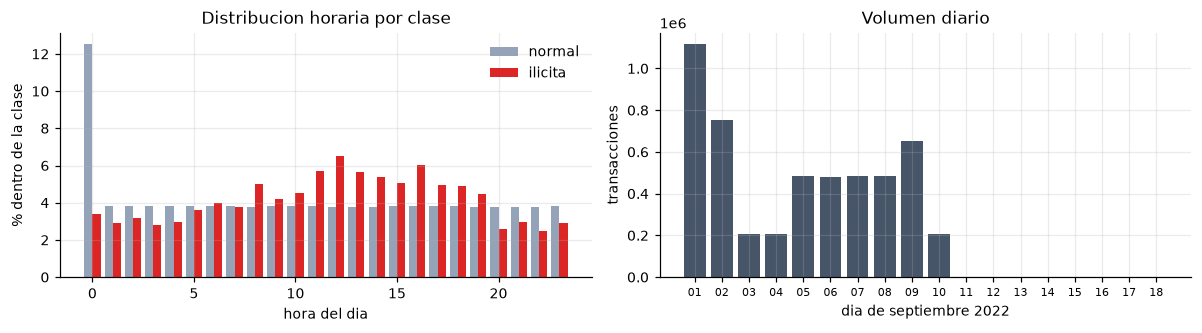

tx en la hora 0 (normales): 12.51 %   (ilicitas): 3.40 %
tx del 1 al 10 de septiembre: 99.98 % del total


In [7]:
hr = pd.crosstab(df["ts"].dt.hour, df["is_laundering"], normalize="columns") * 100
day = df["ts"].dt.date.value_counts().sort_index()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.1))
ax[0].bar(hr.index - 0.2, hr[0], width=0.4, label="normal", color="#94a3b8")
ax[0].bar(hr.index + 0.2, hr[1], width=0.4, label="ilicita", color="#dc2626")
ax[0].set_xlabel("hora del dia"); ax[0].set_ylabel("% dentro de la clase")
ax[0].set_title("Distribucion horaria por clase"); ax[0].legend(frameon=False)

ax[1].bar(range(len(day)), day.values, color="#475569")
ax[1].set_xticks(range(len(day)))
ax[1].set_xticklabels([d.strftime("%d") for d in day.index], fontsize=7)
ax[1].set_xlabel("dia de septiembre 2022"); ax[1].set_ylabel("transacciones")
ax[1].set_title("Volumen diario")
plt.tight_layout(); plt.show()

print(f"tx en la hora 0 (normales): {hr.loc[0,0]:.2f} %   (ilicitas): {hr.loc[0,1]:.2f} %")
print(f"tx del 1 al 10 de septiembre: {100*day.iloc[:10].sum()/day.sum():.2f} % del total")

**Artefactos adicionales.** El **12.5 %** de las transacciones normales ocurre a la hora 0, frente al **3.8 %** en cualquier otra hora, debido al lote de inicialización del simulador concentrado el 1 de septiembre.

Además, el **99.98 %** del volumen ocurre en los primeros diez días, con una cola residual hasta el día 18. Esto descarta una partición temporal, ya que los patrones de lavado abarcan varios días y un corte cronológico podría dividirlos.


## 3. Evidencia para la longitud de secuencia

La distribución de longitudes determina dos decisiones: el **mínimo de transacciones por remitente** para entrar al dataset y la **longitud de ventana** a utilizar.


In [8]:
q = [.5, .75, .9, .95, .99, .999, 1.]
print("TRANSACCIONES POR REMITENTE")
print(f"  media {sender_tx.mean():.2f} | mediana {sender_tx.median():.0f} | "
      f"max {sender_tx.max():,}")
print("  percentiles:", {f"p{int(p*1000)/10}": int(sender_tx.quantile(p)) for p in q})

print()
print("EFECTO DEL MINIMO DE LONGITUD")
print(f"{'min_len':>7} | {'remitentes':>11} | {'positivos':>9} | {'% pos':>7} | {'% tx':>6}")
print("-" * 56)
for k in [1, 2, 3, 4, 5, 8, 10, 20]:
    keep = sender_tx[sender_tx >= k]
    npos = len(set(keep.index) & pos_senders)
    print(f"{k:>7} | {len(keep):>11,} | {npos:>9,} | "
          f"{100*npos/len(keep):>6.3f}% | {100*keep.sum()/n:>5.1f}%")

TRANSACCIONES POR REMITENTE
  media 10.22 | mediana 2 | max 168,672
  percentiles: {'p50.0': 2, 'p75.0': 5, 'p90.0': 29, 'p95.0': 46, 'p99.0': 92, 'p99.9': 159, 'p100.0': 168672}

EFECTO DEL MINIMO DE LONGITUD
min_len |  remitentes | positivos |   % pos |   % tx
--------------------------------------------------------
      1 |     496,995 |     3,376 |  0.679% | 100.0%
      2 |     344,245 |     3,254 |  0.945% |  97.0%
      3 |     185,993 |     2,758 |  1.483% |  90.8%


      4 |     142,306 |     2,085 |  1.465% |  88.2%
      5 |     128,779 |     1,626 |  1.263% |  87.1%
      8 |     115,279 |     1,255 |  1.089% |  85.6%
     10 |     110,008 |     1,185 |  1.077% |  84.7%
     20 |      76,833 |       887 |  1.154% |  75.6%


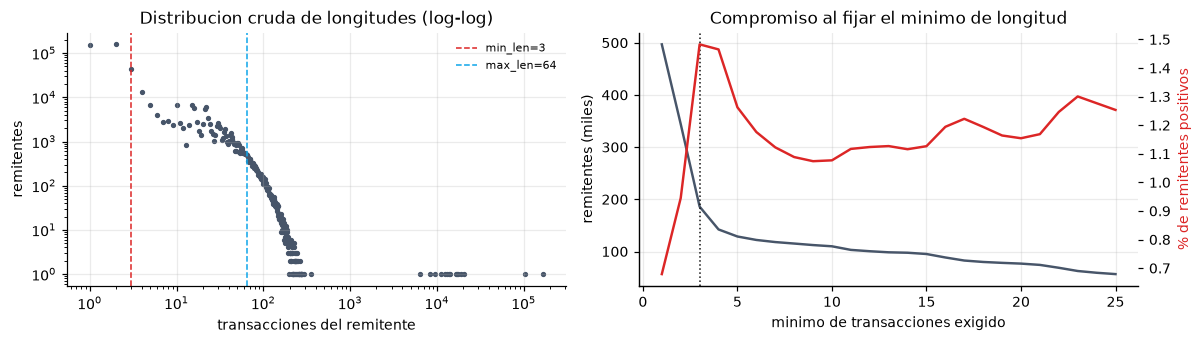

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
vc = sender_tx.value_counts().sort_index()
ax[0].scatter(vc.index, vc.values, s=6, color="#475569")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("transacciones del remitente"); ax[0].set_ylabel("remitentes")
ax[0].set_title("Distribucion cruda de longitudes (log-log)")
ax[0].axvline(CFG["MIN_LEN"], color="#dc2626", ls="--", lw=1, label=f"min_len={CFG['MIN_LEN']}")
ax[0].axvline(CFG["MAX_LEN"], color="#0ea5e9", ls="--", lw=1, label=f"max_len={CFG['MAX_LEN']}")
ax[0].legend(frameon=False, fontsize=7)

ks = np.arange(1, 26)
rem = [int((sender_tx >= k).sum()) for k in ks]
pct = [100 * len(set(sender_tx[sender_tx >= k].index) & pos_senders) / r
       for k, r in zip(ks, rem)]
a2 = ax[1]; a3 = a2.twinx()
a2.plot(ks, np.array(rem) / 1000, color="#475569", lw=1.6, label="remitentes (miles)")
a3.plot(ks, pct, color="#dc2626", lw=1.6, label="% positivos")
a2.axvline(CFG["MIN_LEN"], color="#111", ls=":", lw=1)
a2.set_xlabel("minimo de transacciones exigido"); a2.set_ylabel("remitentes (miles)")
a3.set_ylabel("% de remitentes positivos", color="#dc2626")
a3.grid(False)
a2.set_title("Compromiso al fijar el minimo de longitud")
plt.tight_layout(); plt.show()

In [10]:
inst = sender_tx[sender_tx > CFG["INST_TX_THR"]]
print(f"CUENTAS INSTITUCIONALES (> {CFG['INST_TX_THR']} tx)")
print(f" - cuentas            : {len(inst)}")
print(f" - transacciones      : {int(inst.sum()):,}  ({100*inst.sum()/n:.1f} % del total)")
print(f" - de ellas positivas : {len(set(inst.index) & pos_senders)}")
print()
print("  - top 8 por volumen:")
for a, c in inst.sort_values(ascending=False).head(8).items():
    print(f"   * {a:<12} {c:>9,} tx")
gap_lo = int(sender_tx[sender_tx <= CFG["INST_TX_THR"]].max())
gap_hi = int(inst.min()) if len(inst) else 0
print()
print(f"  hueco en la distribucion: nada entre {gap_lo:,} y {gap_hi:,} transacciones")
print("  Son dos poblaciones distintas, no una cola continua")
INST_ACCTS = set(inst.index)

CUENTAS INSTITUCIONALES (> 500 tx)
 - cuentas            : 15
 - transacciones      : 449,859  (8.9 % del total)
 - de ellas positivas : 15

  - top 8 por volumen:
   * 100428660      168,672 tx
   * 1004286A8      103,018 tx
   * 100428978       20,497 tx
   * 1004286F0       18,663 tx
   * 100428780       17,264 tx
   * 1004289C0       16,794 tx
   * 100428810       16,426 tx
   * 1004287C8       14,174 tx

  hueco en la distribucion: nada entre 351 y 6,431 transacciones
  Son dos poblaciones distintas, no una cola continua


**Decisión 2 | mínimo de 3 transacciones.** Descarta al **63 % de las cuentas**, pero conserva el **90.8 % del volumen** y eleva la proporción de remitentes positivos de **0.68 % a 1.48 %**. Un remitente con una o dos operaciones tampoco ofrece historial suficiente para un análisis de cumplimiento, por lo que el criterio es defendible operativa y estadísticamente.

**Decisión 3 | cuentas institucionales.** Quince cuentas superan las **500 transacciones** y concentran el **8.9 % del volumen**, con hasta **168 mil operaciones** cada una. No se eliminan porque son hubs relevantes, pero se marcan como cohorte separada para reportar el desempeño con y sin ellas. Su peso en el entrenamiento se controla mediante el tope de ventanas de la Decisión 5.


## 4. Ingeniería de features

Cada transacción se representa con **24 dimensiones** agrupadas en cuatro bloques. Cada *feature* corresponde a una señal de lavado relevante en remesas o a una variable necesaria para normalizar las demás.

| Bloque       | Features                                             | Señal que captura                                                 |
| ------------ | ---------------------------------------------------- | ----------------------------------------------------------------- |
| **Monto**    | `log_amt`, `amt_rel`                                 | Montos atípicos en absoluto y respecto al historial del remitente |
| **Tiempo**   | `log_dt`, `is_first_tx`, `hour_sin`, `hour_cos`      | Ráfagas de envíos y concentración horaria                         |
| **Destino**  | `dest_diversity`, `is_new_dest`, `is_self_transfer`  | Cambios de destinatario, dispersión y auto-transferencias         |
| **Contexto** | `is_cross_currency`, formato de pago (7), moneda (7) | Canal, corredor y saltos de divisa                                |

### Decisiones de codificación

`log_dt` mide el tiempo desde la transacción anterior **del mismo remitente**, no un timestamp absoluto: interesa el ritmo de las operaciones, no la fecha. `is_first_tx` permite distinguir la primera operación de un intervalo real de cero minutos.

`amt_rel` representa el monto en escala logarítmica respecto al promedio histórico del remitente hasta esa operación. Así, un mismo monto puede tener distinto significado según el comportamiento habitual de cada remitente.

La hora se codifica con **seno y coseno** para mantener adyacentes las 23:00 y las 00:00. Los montos pasan por `log1p` antes de estandarizar porque abarcan **dieciocho órdenes de magnitud**.


In [11]:
# Filtrado por longitud minima y orden temporal por remitente
keep = sender_tx[sender_tx >= CFG["MIN_LEN"]].index
work = df[df["from_acct"].isin(keep)].copy()
work["from_acct"] = work["from_acct"].cat.remove_unused_categories()
work = work.sort_values(["from_acct", "ts"], kind="mergesort").reset_index(drop=True)

print(f"remitentes: {work['from_acct'].nunique():,}")
print(f"transacciones: {len(work):,}  ({100*len(work)/n:.1f} % del total)")
del df; _ = gc.collect()

remitentes: 185,993
transacciones: 4,609,091  (90.8 % del total)


In [12]:
t = time.time()
gcol = work.groupby("from_acct", observed=True)
pos_in_seq = gcol.cumcount().to_numpy() + 1 # posicion 1-based dentro del remitente

# Bloque 1: monto
work["log_amt"] = np.log1p(work["amt_paid"].to_numpy())
la = work["log_amt"].to_numpy()
csum = work.groupby("from_acct", observed=True)["log_amt"].cumsum().to_numpy()
prev_mean = (csum - la) / np.maximum(pos_in_seq - 1, 1)
work["amt_rel"] = np.where(pos_in_seq > 1, la - prev_mean, 0.0).astype("float32") # desviacion respecto al promedio historico del propio remitente

# Bloque 2: tiempo
dt_min = gcol["ts"].diff().dt.total_seconds().to_numpy() / 60.0
work["is_first_tx"] = np.isnan(dt_min).astype("float32")
work["log_dt"] = np.log1p(np.clip(np.nan_to_num(dt_min, nan=0.0), 0, None))

hour = work["ts"].dt.hour.to_numpy() + work["ts"].dt.minute.to_numpy() / 60.0
work["hour_sin"] = np.sin(2 * np.pi * hour / 24)
work["hour_cos"] = np.cos(2 * np.pi * hour / 24)

# Bloque 3: destino
work["is_new_dest"] = (~work.duplicated(subset=["from_acct", "to_acct"], keep="first")).astype("float32") # primera aparicion de cada par (remitente, destino) = destino nuevo para ese remitente
uniq_so_far = work.groupby("from_acct", observed=True)["is_new_dest"].cumsum().to_numpy()
work["dest_diversity"] = (uniq_so_far / pos_in_seq).astype("float32")
work["is_self_transfer"] = (work["from_acct"].astype(str) == work["to_acct"].astype(str)).astype("float32")

# Bloque 4: contexto
work["is_cross_currency"] = (work["cur_recv"].astype(str) != work["cur_paid"].astype(str)).astype("float32")
print(f"features derivadas en {time.time()-t:.1f} s")
print(work[["log_amt", "amt_rel", "log_dt", "is_first_tx", "dest_diversity",
            "is_new_dest", "is_self_transfer", "is_cross_currency"]]
      .describe().round(3).to_string())

features derivadas en 3.6 s


           log_amt      amt_rel       log_dt  is_first_tx  dest_diversity  is_new_dest  is_self_transfer  is_cross_currency
count  4609091.000  4609091.000  4609091.000  4609091.000     4609091.000  4609091.000       4609091.000        4609091.000
mean         7.458       -0.082        3.426        0.040           0.311        0.146             0.067              0.016
std          3.351        2.447        2.628        0.197           0.257        0.353             0.250              0.124
min          0.000      -18.940        0.000        0.000           0.019        0.000             0.000              0.000
25%          5.283       -1.367        1.386        0.000           0.122        0.000             0.000              0.000
50%          7.300       -0.065        2.639        0.000           0.213        0.000             0.000              0.000
75%          9.430        1.045        6.064        0.000           0.429        0.000             0.000              0.000
max     

In [13]:
# Bloque 4: categoricas
FMT_LEVELS = ["ACH", "Bitcoin", "Cash", "Cheque", "Credit Card", "Reinvestment", "Wire"]
CUR_TOP = ["US Dollar", "Euro", "Swiss Franc", "Yuan", "Shekel", "Rupee"]

fmt_oh = pd.get_dummies(work["fmt"].astype(str)).reindex(columns=FMT_LEVELS, fill_value=0)
fmt_oh.columns = [f"fmt_{c.replace(' ', '_')}" for c in fmt_oh.columns]

cur = work["cur_paid"].astype(str).where(work["cur_paid"].astype(str).isin(CUR_TOP), "Other")
cur_oh = pd.get_dummies(cur).reindex(columns=CUR_TOP + ["Other"], fill_value=0)
cur_oh.columns = [f"cur_{c.replace(' ', '_')}" for c in cur_oh.columns]

NUM_FEATS = ["log_amt", "amt_rel", "log_dt", "is_first_tx", "hour_sin", "hour_cos",
             "dest_diversity", "is_new_dest", "is_self_transfer", "is_cross_currency"]
FEATURES = NUM_FEATS + list(fmt_oh.columns) + list(cur_oh.columns)
STANDARDIZE = ["log_amt", "amt_rel", "log_dt"]   # el resto ya vive en [-1, 1]

X = np.concatenate([
    work[NUM_FEATS].to_numpy(dtype="float32"),
    fmt_oh.to_numpy(dtype="float32"),
    cur_oh.to_numpy(dtype="float32"),
], axis=1)

print(f"matriz de features: {X.shape}  ({X.nbytes/1e6:.0f} MB, float32)")
print(f"dimensiones ({len(FEATURES)}):")
for i in range(0, len(FEATURES), 5):
    print("   ", ", ".join(FEATURES[i:i+5]))
del fmt_oh, cur_oh, cur; _ = gc.collect()

matriz de features: (4609091, 24)  (442 MB, float32)
dimensiones (24):
    log_amt, amt_rel, log_dt, is_first_tx, hour_sin
    hour_cos, dest_diversity, is_new_dest, is_self_transfer, is_cross_currency
    fmt_ACH, fmt_Bitcoin, fmt_Cash, fmt_Cheque, fmt_Credit_Card
    fmt_Reinvestment, fmt_Wire, cur_US_Dollar, cur_Euro, cur_Swiss_Franc
    cur_Yuan, cur_Shekel, cur_Rupee, cur_Other


## 5. Construcción de secuencias

Las transacciones ordenadas de cada remitente se dividen en **ventanas contiguas no solapadas** de `MAX_LEN`. Se prefiere ventanear a truncar, ya que conservar solo las últimas N operaciones podría excluir transacciones ilícitas y convertir un caso positivo en un negativo mal etiquetado.

### Reglas aplicadas

1. Una ventana es **positiva** si contiene al menos una transacción marcada.
2. Las ventanas **sin transacciones marcadas** de un remitente positivo se descartan por ambiguas, evitando introducir ruido de supervisión.
3. Las ventanas con menos de `MIN_LEN` transacciones se descartan.
4. Se limita a `CAP_WINDOWS` ventanas por remitente, **muestreadas al azar** a lo largo de su historial. Así se evita que las cuentas institucionales queden representadas únicamente por la actividad inicial del simulador.


In [14]:
sender_codes = work["from_acct"].cat.codes.to_numpy().astype(np.int64)
ill = work["is_laundering"].to_numpy().astype(np.int64)
pos_in_sender = work.groupby("from_acct", observed=True).cumcount().to_numpy().astype(np.int64)
CATS = np.asarray(work["from_acct"].cat.categories, dtype=object)
BIG = 20000

def build_windows(max_len, cap, min_len=CFG["MIN_LEN"], seed=SEED):
    win = pos_in_sender // max_len
    key = sender_codes * BIG + win
    uk, inv = np.unique(key, return_inverse=True)
    w_len = np.bincount(inv, minlength=len(uk))
    w_ill = np.bincount(inv, weights=ill, minlength=len(uk)).astype(np.int64)
    w_sender, w_idx = uk // BIG, uk % BIG
    is_pos_sender = np.isin(w_sender, np.unique(sender_codes[ill > 0]))

    ok = (w_len >= min_len) & ~(is_pos_sender & (w_ill == 0))
    # tope por remitente: muestreo aleatorio, priorizando ventanas con evidencia
    r = np.random.default_rng(seed)
    prio = np.where(w_ill > 0, -1.0, r.random(len(uk)))   # las positivas nunca se sacrifican
    order = np.lexsort((prio, w_sender))
    ranks = np.empty(len(uk), np.int64)
    ranks[order] = np.arange(len(uk))
    first = np.r_[0, np.cumsum(np.bincount(w_sender[order], minlength=w_sender.max() + 1))[:-1]]
    within = ranks - first[w_sender]
    ok &= within < cap
    return uk, inv, w_len, w_ill, w_sender, w_idx, ok

uk, inv, w_len, w_ill, w_sender, w_idx, ok = build_windows(CFG["MAX_LEN"], CFG["CAP_WINDOWS"])
print(f"ventanas brutas    : {len(uk):,}")
print(f"ventanas retenidas : {int(ok.sum()):,}")
print(f"positivas        : {int((ok & (w_ill > 0)).sum()):,}"
      f"  ({100*(ok & (w_ill>0)).sum()/ok.sum():.3f} %)")

ventanas brutas    : 207,432
ventanas retenidas : 199,364
positivas        : 3,003  (1.506 %)


In [15]:
# Barrido que respalda la eleccion de MAX_LEN y CAP_WINDOWS
rows = []
for ml in [32, 64, 128]:
    for cp in [5, 10, 20, 10**6]:
        _, _, l_, i_, s_, _, o_ = build_windows(ml, cp)
        npos = int((o_ & (i_ > 0)).sum()); ntot = int(o_.sum())
        top = np.bincount(s_[o_], minlength=s_.max() + 1)
        rows.append({"max_len": ml, "cap": "inf" if cp > 1e5 else cp,
                     "secuencias": ntot, "positivas": npos,
                     "% pos": round(100 * npos / ntot, 3),
                     "max win/remit": int(top.max()),
                     "len media": round(float(l_[o_].mean()), 1)})
print("BARRIDO DE CONFIGURACIONES DE VENTANA")
print(pd.DataFrame(rows).to_string(index=False))

BARRIDO DE CONFIGURACIONES DE VENTANA
 max_len cap  secuencias  positivas  % pos  max win/remit  len media
      32   5      242085       2859  1.181              5       17.0
      32  10      242770       2932  1.208             10       17.0
      32  20      242873       3034  1.249             20       17.0
      32 inf      243239       3400  1.398            238       17.1
      64   5      199193       2833  1.422              5       20.8
      64  10      199267       2906  1.458             10       20.9
      64  20      199364       3003  1.506             20       20.9
      64 inf      199725       3364  1.684            236       21.0
     128   5      187367       2823  1.507              5       22.2
     128  10      187439       2895  1.545             10       22.3
     128  20      187532       2988  1.593             20       22.3
     128 inf      187877       3333  1.774            230       22.5


**Decisión 4 | ventana de 64.** Con 128, el costo de la capa de atención se cuadruplica para ganar apenas una décima de punto en tasa de positivos. Con 32, la tasa disminuye al generarse más ventanas negativas por remitente. **64 cubre por completo a más del 95 % de los remitentes** y se ajusta al presupuesto de 30 minutos en T4.

**Decisión 5 | tope de 20 ventanas por remitente.** Sin tope, la cuenta de mayor volumen genera más de **2,600 secuencias**. Con el límite, las quince cuentas institucionales representan una fracción marginal del dataset. El muestreo prioriza ventanas con evidencia, evitando que un remitente positivo pierda su caso por efecto del tope.


## 6. Separación train / val / test
Los patrones de lavado son **redes**: la cuenta receptora de un salto puede ser la emisora del siguiente. Separar por transacción produciría fuga, pero hacerlo solo por remitente tampoco basta, ya que los **370 patrones documentados** comparten cuentas.

### Procedimiento
1. Parsear `HI-Small_Patterns.txt` y extraer las cuentas de cada patrón.
2. Unir mediante *union-find* los patrones que comparten al menos una cuenta, formando **componentes conexos indivisibles**.
3. Usar como unidad de partición el componente completo para cuentas involucradas en patrones y el remitente individual para el resto.
4. Asignar las unidades mediante un algoritmo voraz balanceado por **número de secuencias positivas**, evitando que los componentes grandes concentren los casos en un solo *split*.


In [16]:
groups, cur = [], None
with open(HI_PATT, "r", encoding="utf-8", errors="replace") as f:
    for line in f:
        line = line.rstrip("\n"); up = line.upper()
        if up.startswith("BEGIN LAUNDERING ATTEMPT"):
            label = line.split("-", 1)[1].strip() if "-" in line else "?"
            cur = {"tipo": label.split(":", 1)[0].strip(), "detalle": label, "accts": set()}
        elif up.startswith("END LAUNDERING ATTEMPT"):
            if cur: groups.append(cur); cur = None
        elif line.strip() and cur is not None:
            p = line.split(",")
            if len(p) >= 5:
                cur["accts"].update([p[2], p[4]])

print(f"patrones documentados: {len(groups)}")
tip = Counter(g["tipo"] for g in groups)
print("tipologias:", ", ".join(f"{k} ({v})" for k, v in tip.most_common()))

acct2grp = defaultdict(set)
for i, g in enumerate(groups):
    for a in g["accts"]:
        acct2grp[a].add(i)

parent = list(range(len(groups)))
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]; x = parent[x]
    return x
for gs in acct2grp.values():
    gs = sorted(gs)
    for j in gs[1:]:
        a, b = find(gs[0]), find(j)
        if a != b: parent[b] = a

comp_of_acct = {a: find(next(iter(gs))) for a, gs in acct2grp.items()}
ncomp = len(set(comp_of_acct.values()))
print(f"cuentas en patrones: {len(acct2grp):,}")
print(f"componentes conexos: {ncomp}  (unidades indivisibles para el split)")

patrones documentados: 370
tipologias: CYCLE (54), GATHER-SCATTER (51), BIPARTITE (49), FAN-OUT (48), SCATTER-GATHER (44), STACK (43), RANDOM (41), FAN-IN (40)
cuentas en patrones: 3,170
componentes conexos: 210  (unidades indivisibles para el split)


In [17]:
# Unidad de particion por remitente
sender_names = CATS # nombre por codigo de remitente
unit_of_sender = np.empty(len(sender_names), dtype=object)
for c, name in enumerate(sender_names):
    comp = comp_of_acct.get(str(name))
    unit_of_sender[c] = f"C{comp}" if comp is not None else f"S{c}"

sel = np.where(ok)[0] # ventanas retenidas
w_unit = unit_of_sender[w_sender[sel]]
w_label = (w_ill[sel] > 0).astype(np.int8)

udf = pd.DataFrame({"unit": w_unit, "y": w_label})
agg = udf.groupby("unit").agg(n=("y", "size"), pos=("y", "sum")).sort_values(["pos", "n"], ascending=False)

print(f"unidades de particion : {len(agg):,}")
print(f" - con al menos un positivo: {int((agg['pos']>0).sum()):,}")
print(f" - unidad mas grande       : {int(agg['n'].max()):,} secuencias, "
      f"{int(agg['pos'].max())} positivas")

unidades de particion : 183,716
 - con al menos un positivo: 1,072
 - unidad mas grande       : 365 secuencias, 196 positivas


In [18]:
# Cada unidad va al split con mayor deficit relativo de positivos
tr, va, te = CFG["SPLITS"]
targets = np.array([tr, va, te])
tot_pos, tot_n = int(agg["pos"].sum()), int(agg["n"].sum())
cur_pos, cur_n = np.zeros(3), np.zeros(3)
assign = {}

for unit, row in agg.iterrows():
    if row["pos"] > 0:
        deficit = targets * tot_pos - cur_pos
    else:
        deficit = targets * tot_n - cur_n
    k = int(np.argmax(deficit))
    assign[unit] = k
    cur_pos[k] += row["pos"]; cur_n[k] += row["n"]

split_of_window = np.array([assign[u] for u in w_unit], dtype=np.int8)

names = ["train", "val", "test"]
print(f"{'split':>6} | {'secuencias':>11} | {'positivas':>9} | {'% pos':>7} | {'% del total':>11}")
print("-" * 60)
for k in range(3):
    m = split_of_window == k
    npos = int(w_label[m].sum())
    print(f"{names[k]:>6} | {int(m.sum()):>11,} | {npos:>9,} | "
          f"{100*npos/max(m.sum(),1):>6.3f}% | {100*m.mean():>10.1f}%")

 split |  secuencias | positivas |   % pos | % del total
------------------------------------------------------------
 train |     139,555 |     2,102 |  1.506% |       70.0%
   val |      29,905 |       451 |  1.508% |       15.0%
  test |      29,904 |       450 |  1.505% |       15.0%


In [19]:
# Verificacion de ausencia de fuga
by_unit = pd.DataFrame({"unit": w_unit, "split": split_of_window})
bad_units = by_unit.groupby("unit")["split"].nunique()
by_send = pd.DataFrame({"s": w_sender[sel], "split": split_of_window})
bad_send = by_send.groupby("s")["split"].nunique()

print("unidades presentes en mas de un split :", int((bad_units > 1).sum()))
print("remitentes presentes en mas de un split:", int((bad_send > 1).sum()))
assert (bad_units <= 1).all() and (bad_send <= 1).all(), "FUGA DETECTADA"
print("\nSin fuga: cada remitente y cada componente de patron vive en un unico split.")

unidades presentes en mas de un split : 0
remitentes presentes en mas de un split: 0

Sin fuga: cada remitente y cada componente de patron vive en un unico split.


## 7. Normalización

Solo `log_amt`, `amt_rel` y `log_dt` requieren estandarización; el resto de las *features* ya se encuentra en `[-1, 1]` por construcción. Los estadísticos se calculan **exclusivamente con el conjunto de entrenamiento** y se aplican a los tres *splits*, evitando fuga de información desde validación o test.

Tras estandarizar, los valores se recortan a **±5 desviaciones estándar**. Sin este límite, los montos extremos (hasta **1.05e12**) podrían dominar el error de reconstrucción de la Etapa A y hacer que el score detecte magnitud en lugar de patrones de comportamiento. La fracción de valores afectada por el recorte se reporta a continuación.


In [20]:
w_start = np.r_[0, np.cumsum(w_len)[:-1]].astype(np.int64)
w_end = (w_start + w_len).astype(np.int64)
s_start, s_end = w_start[sel], w_end[sel]

train_rows = np.zeros(len(X), dtype=bool)
for a, b in zip(s_start[split_of_window == 0], s_end[split_of_window == 0]):
    train_rows[a:b] = True

idx_std = [FEATURES.index(c) for c in STANDARDIZE]
mu = X[train_rows][:, idx_std].mean(axis=0)
sd = X[train_rows][:, idx_std].std(axis=0) + 1e-8
X[:, idx_std] = (X[:, idx_std] - mu) / sd

print("estadisticos ajustados solo en train:")
for c, m, s in zip(STANDARDIZE, mu, sd):
    print(f"  {c:<10} media={m:8.4f}  desv={s:8.4f}")
print(f"\ntransacciones de entrenamiento usadas: {int(train_rows.sum()):,}")
print(f"rango antes del recorte: [{X.min():.2f}, {X.max():.2f}]")

CLIP = CFG["CLIP_SIGMA"]
sub = X[:, idx_std]
n_clip = int((np.abs(sub) > CLIP).sum())
print(f"\nrecorte a +-{CLIP:.0f} desviaciones:")
for j, c in zip(idx_std, STANDARDIZE):
    k = int((np.abs(X[:, j]) > CLIP).sum())
    print(f"  {c:<10} {k:>8,} valores  ({100*k/len(X):.4f} % de las transacciones)")
X[:, idx_std] = np.clip(sub, -CLIP, CLIP)
print(f"\ntotal recortado: {n_clip:,} de {sub.size:,} valores ({100*n_clip/sub.size:.4f} %)")
print(f"rango final de X: [{X.min():.2f}, {X.max():.2f}]")

estadisticos ajustados solo en train:
  log_amt    media=  7.3928  desv=  3.3873
  amt_rel    media= -0.0739  desv=  2.4073
  log_dt     media=  3.6693  desv=  2.4857

transacciones de entrenamiento usadas: 3,180,692
rango antes del recorte: [-7.84, 8.79]

recorte a +-5 desviaciones:
  log_amt          40 valores  (0.0009 % de las transacciones)
  amt_rel       3,817 valores  (0.0828 % de las transacciones)
  log_dt            0 valores  (0.0000 % de las transacciones)

total recortado: 3,857 de 13,827,273 valores (0.0279 %)
rango final de X: [-5.00, 5.00]


### Balanceo para cada etapa

El desbalance se aborda de forma distinta en cada etapa, ya que resuelven problemas diferentes.

**Etapa A.** Se entrena solo con remitentes sin transacciones marcadas **y** que no aparecen en ningún patrón documentado. Así se evita contaminar la definición de normalidad con cuentas pertenecientes a redes de lavado.

**Etapa B.** Conserva todos los positivos y submuestrea negativos a **1:10**. No se balancea a 1:1 para preservar mejor la calibración de probabilidades y el umbral de decisión. El desbalance residual se compensa en la función de pérdida del Componente 2.


In [21]:
patt_accounts = set(acct2grp.keys())
sender_is_patt = np.array([str(nm) in patt_accounts for nm in sender_names])
clean_sender = ~sender_is_patt[w_sender[sel]]

stage_a = (split_of_window == 0) & (w_label == 0) & clean_sender
print(f"ETAPA A (solo normalidad)")
print(f"  secuencias de entrenamiento : {int(stage_a.sum()):,}")
print(f"  excluidas por pertenecer a un patron: "
      f"{int(((split_of_window==0) & (w_label==0) & ~clean_sender).sum()):,}")
r = np.random.default_rng(SEED)
tr_pos = np.where((split_of_window == 0) & (w_label == 1))[0]
tr_neg = np.where((split_of_window == 0) & (w_label == 0))[0]
n_neg = min(len(tr_neg), CFG["NEG_POS_RATIO"] * len(tr_pos))
stage_b_idx = np.sort(np.concatenate([tr_pos, r.choice(tr_neg, n_neg, replace=False)]))


print(f"\nETAPA B (supervisada, submuestreo 1:{CFG['NEG_POS_RATIO']})")
print(f"  positivas : {len(tr_pos):,}")
print(f"  negativas : {n_neg:,}")
print(f"  total     : {len(stage_b_idx):,}")
print(f"\nVal y test conservan la proporcion natural para que las metricas sean realistas.")

ETAPA A (solo normalidad)
  secuencias de entrenamiento : 136,875
  excluidas por pertenecer a un patron: 578

ETAPA B (supervisada, submuestreo 1:10)
  positivas : 2,102
  negativas : 21,020
  total     : 23,122

Val y test conservan la proporcion natural para que las metricas sean realistas.


## 8. Verificación obligatoria

Se realizan las **tres comprobaciones exigidas** antes de iniciar cualquier modelado.


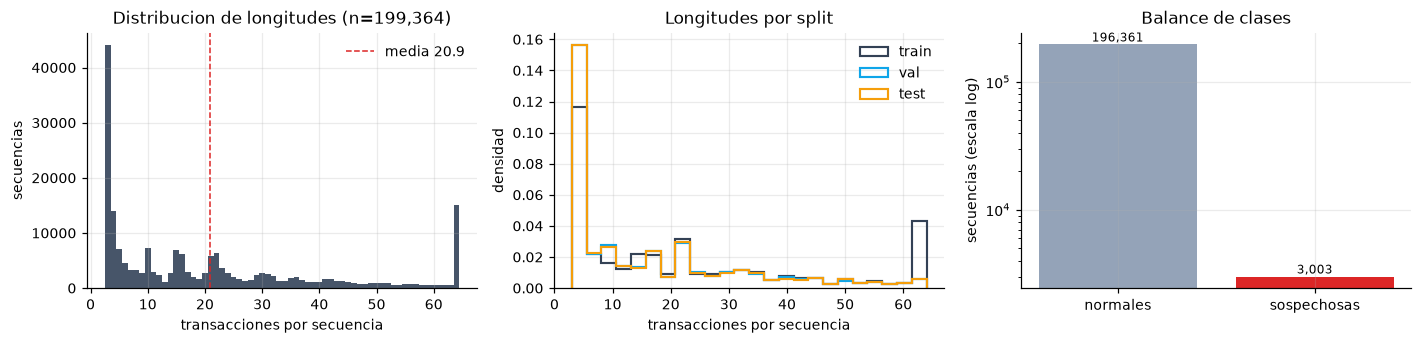

longitudes: min 3  mediana 15  media 20.9  max 64
positivas: 3,003 de 199,364  (1.506 %)
ratio: 1 sospechosa por cada 65 normales


In [22]:
lens = w_len[sel]
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))

ax[0].hist(lens, bins=np.arange(CFG["MIN_LEN"], CFG["MAX_LEN"] + 2) - .5,
           color="#475569", edgecolor="none")
ax[0].set_xlabel("transacciones por secuencia"); ax[0].set_ylabel("secuencias")
ax[0].set_title(f"Distribucion de longitudes (n={len(lens):,})")
ax[0].axvline(lens.mean(), color="#dc2626", ls="--", lw=1,
              label=f"media {lens.mean():.1f}")
ax[0].legend(frameon=False)

for k, cl in zip(range(3), ["#334155", "#0ea5e9", "#f59e0b"]):
    m = split_of_window == k
    ax[1].hist(lens[m], bins=24, histtype="step", lw=1.4, color=cl,
               density=True, label=names[k])
ax[1].set_xlabel("transacciones por secuencia"); ax[1].set_ylabel("densidad")
ax[1].set_title("Longitudes por split"); ax[1].legend(frameon=False)

cnt = [int((w_label == 0).sum()), int((w_label == 1).sum())]
b = ax[2].bar(["normales", "sospechosas"], cnt, color=["#94a3b8", "#dc2626"])
ax[2].set_yscale("log"); ax[2].set_ylabel("secuencias (escala log)")
ax[2].set_title("Balance de clases")
for rect, v in zip(b, cnt):
    ax[2].text(rect.get_x() + rect.get_width()/2, v, f"{v:,}",
               ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

print(f"longitudes: min {lens.min()}  mediana {int(np.median(lens))}  "
      f"media {lens.mean():.1f}  max {lens.max()}")
print(f"positivas: {cnt[1]:,} de {sum(cnt):,}  ({100*cnt[1]/sum(cnt):.3f} %)")
print(f"ratio: 1 sospechosa por cada {cnt[0]/cnt[1]:.0f} normales")

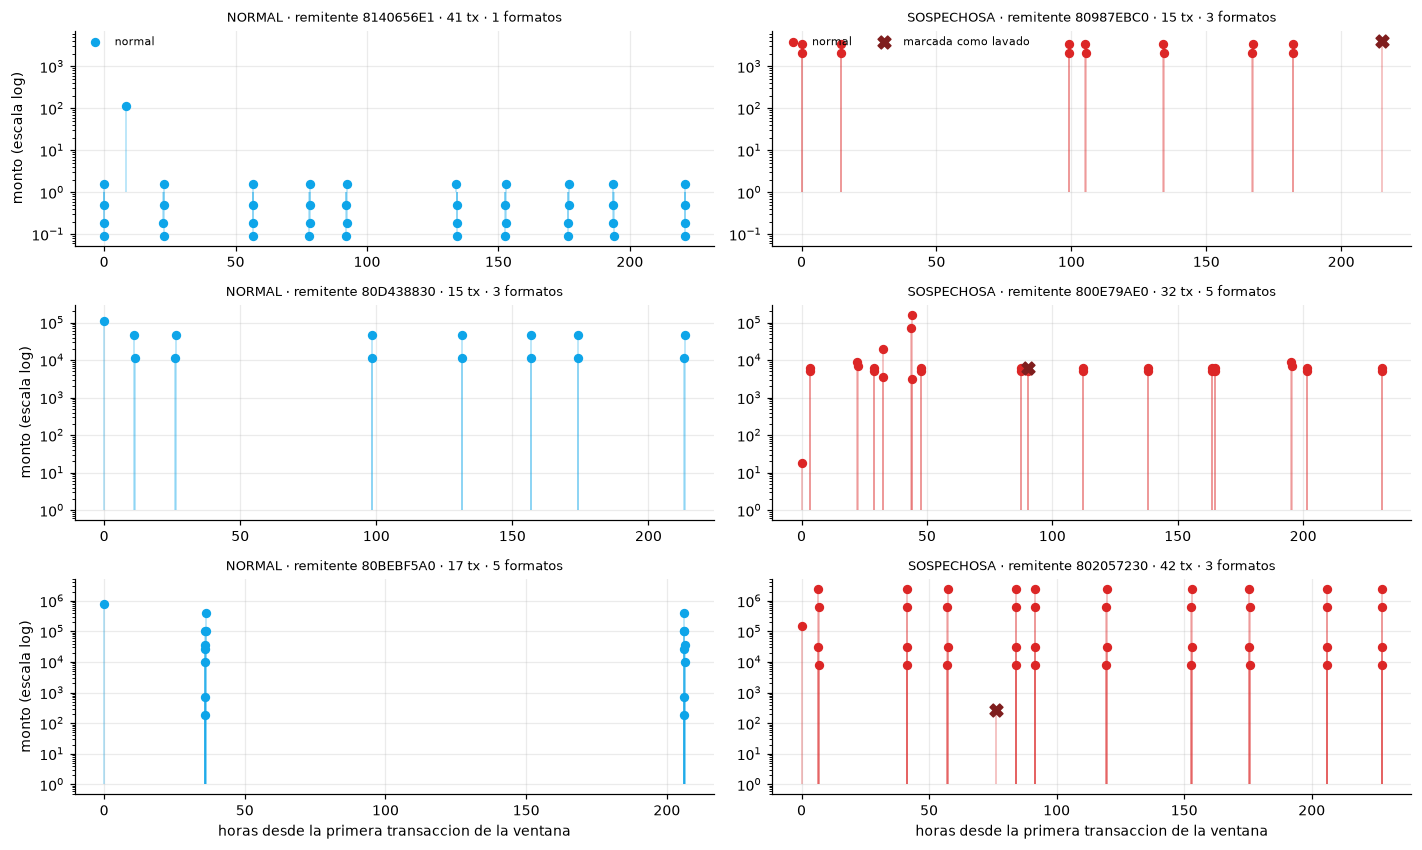

In [23]:
# Tres pares de ejemplos: secuencias normales frente a sospechosas
meta_ts = work["ts"].to_numpy()
meta_amt = work["amt_paid"].to_numpy()
meta_ill = work["is_laundering"].to_numpy()
meta_fmt = work["fmt"].cat.codes.to_numpy()
meta_newdest = work["is_new_dest"].to_numpy()

cand_pos = [i for i in np.where(w_label == 1)[0] if 12 <= lens[i] <= 45]
cand_neg = [i for i in np.where(w_label == 0)[0] if 12 <= lens[i] <= 45]
rr = np.random.default_rng(7)
pick_pos = rr.choice(cand_pos, 3, replace=False)
pick_neg = rr.choice(cand_neg, 3, replace=False)

fig, axes = plt.subplots(3, 2, figsize=(13, 7.8))
for row in range(3):
    axes[row, 0].sharey(axes[row, 1])      # misma escala dentro de cada par
    for col, (idx, titulo, base) in enumerate([
            (pick_neg[row], "NORMAL", "#0ea5e9"),
            (pick_pos[row], "SOSPECHOSA", "#dc2626")]):
        a, b = s_start[idx], s_end[idx]
        t = (meta_ts[a:b] - meta_ts[a]) / np.timedelta64(1, "h")
        y = meta_amt[a:b]; z = meta_ill[a:b].astype(bool)
        ax = axes[row, col]
        ax.vlines(t, 1, y, color=base, alpha=.35, lw=1)
        ax.scatter(t[~z], y[~z], s=26, color=base, zorder=3, label="normal")
        if z.any():
            ax.scatter(t[z], y[z], s=70, color="#7f1d1d", marker="X",
                       zorder=4, label="marcada como lavado")
        ax.set_yscale("log")
        ax.set_title(f"{titulo} · remitente {sender_names[w_sender[sel][idx]]} · "
                     f"{b-a} tx · {len(set(meta_fmt[a:b]))} formatos", fontsize=8.5)
        if row == 2: ax.set_xlabel("horas desde la primera transaccion de la ventana")
        if col == 0: ax.set_ylabel("monto (escala log)")
        if row == 0: ax.legend(frameon=False, fontsize=7, loc="upper left",
                               ncol=2, bbox_to_anchor=(0, 1.02))
plt.tight_layout(); plt.show()

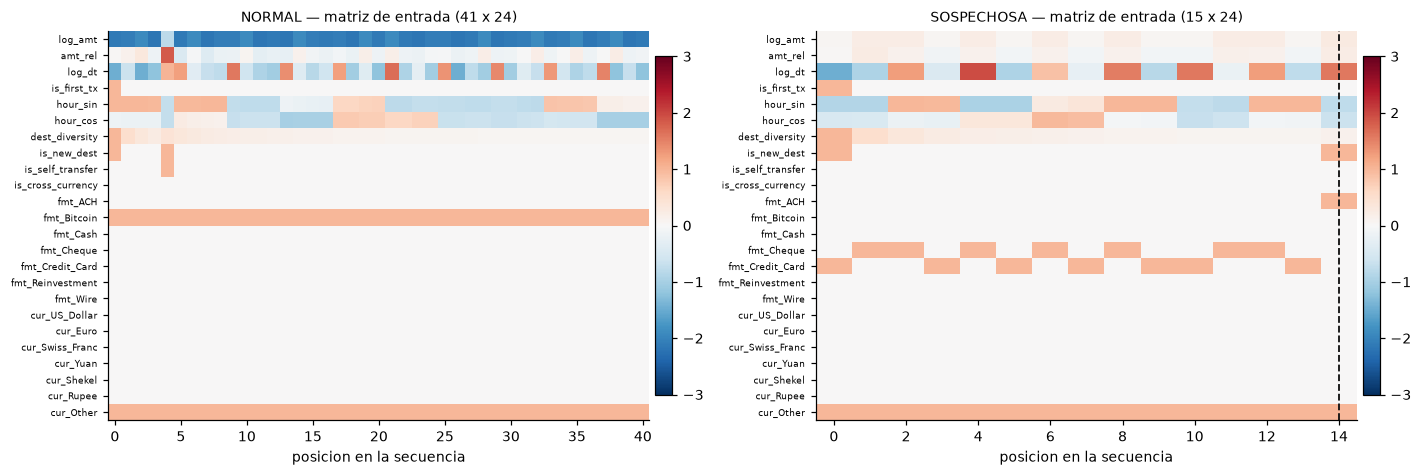

Las lineas punteadas marcan las transacciones etiquetadas como lavado.
Una secuencia sospechosa contiene en promedio 1.39 transacciones marcadas
sobre una longitud media de 20.5: el modelo debe localizar una o
dos posiciones anomalas entre decenas, lo que justifica el pooling top-k del score.


In [24]:
# Lo que realmente ve el modelo: la matriz de features de un par de ejemplos
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, idx, titulo in [(axes[0], pick_neg[0], "NORMAL"),
                        (axes[1], pick_pos[0], "SOSPECHOSA")]:
    a, b = s_start[idx], s_end[idx]
    m = X[a:b].T
    im = ax.imshow(m, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3,
                   interpolation="nearest")
    ax.set_yticks(range(len(FEATURES)))
    ax.set_yticklabels(FEATURES, fontsize=6)
    ax.set_xlabel("posicion en la secuencia")
    ax.set_title(f"{titulo} — matriz de entrada ({b-a} x {len(FEATURES)})", fontsize=9)
    ax.grid(False)
    for j in np.where(meta_ill[a:b] == 1)[0]:
        ax.axvline(j, color="#111", lw=1.2, ls="--")
    fig.colorbar(im, ax=ax, fraction=.03, pad=.01)
plt.tight_layout(); plt.show()
ill_por_seq = w_ill[sel][w_label == 1].mean()
print(f"Las lineas punteadas marcan las transacciones etiquetadas como lavado.")
print(f"Una secuencia sospechosa contiene en promedio {ill_por_seq:.2f} transacciones marcadas")
print(f"sobre una longitud media de {lens[w_label==1].mean():.1f}: el modelo debe localizar una o")
print("dos posiciones anomalas entre decenas, lo que justifica el pooling top-k del score.")

In [25]:
# Comparacion agregada normal vs sospechosa, mas alla de los ejemplos individuales
pos_w = np.where(w_label == 1)[0]
neg_w = np.where(w_label == 0)[0]
rows = []
for nm, ws in [("normales", rr.choice(neg_w, 5000, replace=False)), ("sospechosas", pos_w)]:
    dur, nd, amp, gap = [], [], [], []
    for i in ws:
        a, b = s_start[i], s_end[i]
        h = (meta_ts[a:b] - meta_ts[a]) / np.timedelta64(1, "h")
        dur.append(h[-1]); nd.append(meta_newdest[a:b].mean())
        amp.append(np.log10(meta_amt[a:b].max() / max(meta_amt[a:b].min(), 1e-6)))
        gap.append(np.median(np.diff(h)) if b - a > 1 else 0)
    rows.append({"grupo": nm, "n": len(ws),
                 "duracion (h)": round(float(np.median(dur)), 1),
                 "% destinos nuevos": round(100 * float(np.median(nd)), 1),
                 "amplitud montos (ordenes)": round(float(np.median(amp)), 2),
                 "gap mediano (h)": round(float(np.median(gap)), 2)})
print("PERFIL AGREGADO (medianas)")
print(pd.DataFrame(rows).to_string(index=False))

PERFIL AGREGADO (medianas)
      grupo    n  duracion (h)  % destinos nuevos  amplitud montos (ordenes)  gap mediano (h)
   normales 5000         201.0               17.6                       3.05             1.97
sospechosas 3003         189.3               50.0                       3.45             3.85


## 9. Exportación

Se guarda una representación **compacta**: una única matriz de *features* para todas las transacciones, junto con los índices de inicio y fin de cada ventana.

Esto evita materializar el tensor con relleno y permite que el `DataLoader` del Componente 2 construya lotes con **relleno dinámico**, más eficiente en GPU.


In [26]:
np.savez(
    OUT_DIR / "sequences.npz",
    X=X,
    win_start=s_start.astype(np.int64), win_end=s_end.astype(np.int64),
    y=w_label.astype(np.int8), split=split_of_window.astype(np.int8),
    sender_code=w_sender[sel].astype(np.int32),
    is_illicit_tx=meta_ill.astype(np.int8),
    stage_a_mask=stage_a, stage_b_idx=stage_b_idx.astype(np.int64),
    is_institutional=np.array([str(nm) in INST_ACCTS for nm in sender_names]),
)
with open(OUT_DIR / "meta.json", "w") as f:
    json.dump({"features": FEATURES, "standardize": STANDARDIZE,
               "mu": mu.tolist(), "sd": sd.tolist(), "cfg": CFG,
               "sender_names": [str(x) for x in sender_names],
               "n_sequences": int(len(s_start)),
               "n_positive": int(w_label.sum())}, f)

# Metadatos legibles de test, para el analisis de casos y el MVP
te_idx = np.where(split_of_window == 2)[0]
rows_te = np.concatenate([np.arange(s_start[i], s_end[i]) for i in te_idx])
test_tx = work.iloc[rows_te][["from_acct", "to_acct", "ts", "amt_paid",
                              "cur_paid", "fmt", "is_laundering"]]
try:
    test_tx.to_parquet(OUT_DIR / "test_tx.parquet", index=True)
except ImportError:
    test_tx.to_csv(OUT_DIR / "test_tx.csv.gz", index=True, compression="gzip")
for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p.name:<24} {p.stat().st_size/1e6:>8,.1f} MB")
print(f"\ntiempo total del notebook: {(time.time()-T0)/60:.1f} min")

  meta.json                     2.4 MB
  sequences.npz               452.0 MB
  stage_a_meta.json             0.0 MB
  stage_a_model.pt              0.2 MB
  stage_a_scores.npz            5.0 MB
  stage_b_attention.npz         2.7 MB
  stage_b_meta.json             0.0 MB
  stage_b_model.pt              0.1 MB
  stage_b_scores.npz            5.8 MB
  test_tx.parquet              10.1 MB

tiempo total del notebook: 0.8 min


In [27]:
# Verificacion de que los artefactos se leen correctamente
z = np.load(OUT_DIR / "sequences.npz")
meta = json.load(open(OUT_DIR / "meta.json"))
i = int(np.where(z["y"] == 1)[0][0])
seq = z["X"][z["win_start"][i]:z["win_end"][i]]
print("secuencias:", len(z["y"]), "| features:", len(meta["features"]))
print("ejemplo positivo -> shape", seq.shape, "| etiqueta", int(z["y"][i]),
      "| split", int(z["split"][i]))
print("reparto:", {names[k]: int((z["split"] == k).sum()) for k in range(3)})

secuencias: 199364 | features: 24
ejemplo positivo -> shape (64, 24) | etiqueta 1 | split 0
reparto: {'train': 139555, 'val': 29905, 'test': 29904}


## Resumen de decisiones

|    #   | Decisión                                           | Justificación                                                                                                                       |
| :----: | -------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------- |
|  **1** | IBM AML HI-Small; PaySim excluido                  | PaySim tiene 1.00 tx por remitente: no admite secuencias y su etiqueta es fraude, no lavado                                         |
|  **2** | Mínimo de 3 transacciones                          | Conserva el 90.8 % del volumen y duplica la tasa de positivos; con menos no hay historial evaluable                                 |
|  **3** | 15 cuentas institucionales marcadas, no eliminadas | Concentran el 8.9 % del volumen; se reportan aparte para no atribuir al sistema una capacidad limitada a hubs                       |
|  **4** | Ventanas de 64, sin truncamiento                   | Truncar puede eliminar evidencia y crear negativos mal etiquetados; 128 cuadruplica el costo de atención                            |
|  **5** | Tope de 20 ventanas, muestreadas al azar           | Evita que una cuenta con 168 mil operaciones domine el entrenamiento sin sacrificar casos positivos                                 |
|  **6** | 24 *features* en cuatro bloques                    | Cada una representa una señal de lavado; `log1p` maneja los 18 órdenes de magnitud y `amt_rel` contextualiza el monto por remitente |
|  **7** | *Split* por componente de patrón                   | Los patrones comparten cuentas; separar solo por remitente permitiría fuga de red                                                   |
|  **8** | Asignación voraz balanceada                        | Los componentes mayores concentran gran parte de los patrones; el azar produciría *splits* desiguales                               |
|  **9** | Normalización en *train* y recorte a ±5σ           | Evita fuga desde test y que transacciones extremas dominen el error de reconstrucción                                               |
| **10** | Etapa A sin cuentas de patrón; Etapa B a 1:10      | Evita contaminar la normalidad y preserva mejor la calibración del umbral                                                           |


# Componente 2: Sistema de detección en dos etapas
## Etapa A: Aprendizaje de la normalidad

Antes de intentar clasificar qué es sospechoso, el sistema aprende primero qué es normal. Un autoencoder recurrente se entrena exclusivamente sobre secuencias de remitentes sin ninguna transacción marcada y sin pertenecer a ninguna red de patrón documentada. El modelo aprende a comprimir y reconstruir ese comportamiento; cuando se le presenta una secuencia que no se le parece, la reconstrucción falla más. El error de reconstrucción es el score de anomalía.

**Flujo de esta sección:** Carga de artefactos → *Dataset* con relleno dinámico → arquitectura encoder-decoder → entrenamiento con paro anticipado → score de anomalía por secuencia → elección de la agregación → umbral de decisión → evaluación en validación/prueba → trazabilidad → exportación.

**Nota de reproducibilidad.** Esta sección lee `sequences.npz` y `meta.json` directamente del disco en vez de reutilizar las variables en memoria de la Sección 9, para poder ejecutarse en una sesión independiente sin repetir el pipeline de datos. Requiere que el Componente 1 ya se haya corrido al menos una vez. Se recomienda un entorno con GPU, en CPU el entrenamiento es funcional pero más lento.


## 10. Carga de artefactos y configuración

Se leen `X`, los límites de cada ventana y las máscaras de *split* directamente del `.npz` exportado. `stage_a_mask` ya excluye, desde el Componente 1, tanto las secuencias con transacciones marcadas como las de remitentes que participan en una red de patrón aunque su propia ventana no tenga evidencia (Decisión 10).


In [28]:
try:
    import torch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", "torch"], check=False)
    import torch

from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_recall_curve,
                              roc_curve, f1_score, precision_score, recall_score, confusion_matrix)

torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"dispositivo: {DEVICE}")

z = np.load(OUT_DIR / "sequences.npz")
meta = json.load(open(OUT_DIR / "meta.json"))

X                 = z["X"]
win_start         = z["win_start"]
win_end           = z["win_end"]
y                 = z["y"].astype(np.int64)
split             = z["split"]
sender_code       = z["sender_code"]
stage_a_mask      = z["stage_a_mask"]
is_institutional  = z["is_institutional"]

N_FEATS = X.shape[1]
N_WIN   = len(y)
assert N_FEATS == len(meta["features"]) == 24

print(f"secuencias totales : {N_WIN:,}  ({N_FEATS} features)")
print(f"Etapa A (normal, train, remitente limpio): {int(stage_a_mask.sum()):,}")
for k, nm in enumerate(["train", "val", "test"]):
    m = split == k
    print(f"  {nm:<5}: {int(m.sum()):>7,} secuencias | {100*y[m].mean():.3f}% positivas")


dispositivo: cuda


secuencias totales : 199,364  (24 features)
Etapa A (normal, train, remitente limpio): 136,875
  train: 139,555 secuencias | 1.506% positivas
  val  :  29,905 secuencias | 1.508% positivas
  test :  29,904 secuencias | 1.505% positivas


In [29]:
CFG2 = dict(
    ENC_HIDDEN   = 64,   # unidades ocultas del encoder LSTM
    ENC_LAYERS   = 1,
    LATENT_DIM   = 16,   # < 24 features: fuerza compresion real, no una identidad
    DEC_HIDDEN   = 64,
    DEC_LAYERS   = 1,
    DROPOUT      = 0.1,
    BATCH_SIZE   = 512,
    LR           = 1e-3,
    WEIGHT_DECAY = 1e-5,
    GRAD_CLIP    = 5.0,  # recorte de norma de gradiente, estabilidad en LSTM
    MAX_EPOCHS   = 60,
    PATIENCE     = 5,    # paro anticipado sobre la perdida de validacion
    LR_FACTOR    = 0.5,  # recorte del LR cuando la validacion se estanca
    LR_PATIENCE  = 2,
    TOPK_GRID    = [1, 2, 3, 5, 8, 16],
    SEED         = SEED,
)
print(json.dumps(CFG2, indent=2))

{
  "ENC_HIDDEN": 64,
  "ENC_LAYERS": 1,
  "LATENT_DIM": 16,
  "DEC_HIDDEN": 64,
  "DEC_LAYERS": 1,
  "DROPOUT": 0.1,
  "BATCH_SIZE": 512,
  "LR": 0.001,
  "WEIGHT_DECAY": 1e-05,
  "GRAD_CLIP": 5.0,
  "MAX_EPOCHS": 60,
  "PATIENCE": 5,
  "LR_FACTOR": 0.5,
  "LR_PATIENCE": 2,
  "TOPK_GRID": [
    1,
    2,
    3,
    5,
    8,
    16
  ],
  "SEED": 42
}


## 11. Dataset y relleno dinámico

Las ventanas tienen longitud variable (entre `MIN_LEN=3` y `MAX_LEN=64`). En vez de materializar un tensor fijo `(N, 64, 24)`, cada lote se rellena únicamente hasta su propio máximo (`collate_dynamic_padding`) y una máscara booleana marca qué posiciones son reales. Esa máscara se usa tanto dentro del *encoder* (`pack_padded_sequence`, para que el LSTM no procese relleno) como en la función de pérdida (para que el error de reconstrucción no se calcule sobre posiciones inexistentes).


In [30]:
class WindowDataset(Dataset):
    def __init__(self, indices):
        self.indices = np.asarray(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        w = int(self.indices[i])
        a, b = int(win_start[w]), int(win_end[w])
        return torch.from_numpy(X[a:b]), w


def collate_dynamic_padding(batch):
    seqs, wids = zip(*batch)
    lens = torch.tensor([s.shape[0] for s in seqs], dtype=torch.long)
    padded = nn.utils.rnn.pad_sequence(seqs, batch_first=True)          # (B, T_lote, 24)
    mask = torch.arange(padded.shape[1])[None, :] < lens[:, None]        # (B, T_lote)
    return padded, lens, mask, torch.tensor(wids, dtype=torch.long)


def make_loader(indices, batch_size=None, shuffle=False, drop_last=False):
    return DataLoader(WindowDataset(indices), batch_size=batch_size or CFG2["BATCH_SIZE"],
                       shuffle=shuffle, collate_fn=collate_dynamic_padding, drop_last=drop_last)


train_idx = np.where(stage_a_mask)[0]
val_normal_idx = np.where((split == 1) & (y == 0))[0]

train_loader = make_loader(train_idx, shuffle=True, drop_last=True)
val_loader = make_loader(val_normal_idx)

print(f"ventanas de entrenamiento (Etapa A)   : {len(train_idx):,}")
print(f"ventanas de validacion (proxy normal) : {len(val_normal_idx):,}")

ventanas de entrenamiento (Etapa A)   : 136,875
ventanas de validacion (proxy normal) : 29,454


## 12. Arquitectura: autoencoder LSTM con máscara

**Encoder-decoder recurrente**, no un Transformer. La Sección 3 (Decisión 4) ya mostró que una capa de atención completa sobre 64 pasos cuadruplica el costo frente a 32; ese costo se paga en cada época y sobre las ~137 mil secuencias de entrenamiento de la Etapa A, sin usar ninguna etiqueta. Un LSTM es lineal en la longitud de la secuencia y procesa el relleno de forma nativa vía `pack_padded_sequence`. La atención se reserva para la Etapa B, supervisada y con un conjunto de entrenamiento casi seis veces menor (23,122 secuencias).

**Encoder.** LSTM que consume la secuencia completa (empaquetada, sin ver el relleno) y proyecta el último estado oculto a un vector latente de **16 dimensiones**, deliberadamente menor a las 24 *features* de entrada, ya que sin ese cuello de botella el modelo podría aprender una identidad en vez de una representación comprimida del comportamiento normal.

**Decoder.** En vez de un decodificador autoregresivo, se usa el patrón **"repeat-vector"**, donde el vector latente se repite como entrada en cada paso de tiempo y un LSTM lo despliega a la longitud objetivo. Es suficiente porque el objetivo es reconstruir una secuencia ya observada, no generar una nueva.

**Pérdida.** Error cuadrático medio por paso de tiempo, promediado sobre las 24 *features* y enmascarado donde las posiciones de relleno no contribuyen al gradiente ni a la métrica.


In [31]:
class LSTMEncoder(nn.Module):
    def __init__(self, n_features, hidden, layers, latent, dropout):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers=layers, batch_first=True,
                             dropout=dropout if layers > 1 else 0.0)
        self.to_latent = nn.Linear(hidden, latent)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        return self.to_latent(h_n[-1])                     # (B, latent) - ultima capa, ultimo paso valido


class LSTMDecoder(nn.Module):
    def __init__(self, latent, hidden, layers, n_features, dropout):
        super().__init__()
        self.from_latent = nn.Linear(latent, hidden)
        self.lstm = nn.LSTM(latent, hidden, num_layers=layers, batch_first=True,
                             dropout=dropout if layers > 1 else 0.0)
        self.out = nn.Linear(hidden, n_features)
        self.layers = layers

    def forward(self, z, target_len):
        z_rep = z.unsqueeze(1).expand(-1, target_len, -1)                          # (B, T, latent)
        h0 = torch.tanh(self.from_latent(z)).unsqueeze(0).expand(self.layers, -1, -1).contiguous()
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(z_rep, (h0, c0))
        return self.out(out)                                                         # (B, T, 24)


class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, cfg):
        super().__init__()
        self.encoder = LSTMEncoder(n_features, cfg["ENC_HIDDEN"], cfg["ENC_LAYERS"],
                                    cfg["LATENT_DIM"], cfg["DROPOUT"])
        self.decoder = LSTMDecoder(cfg["LATENT_DIM"], cfg["DEC_HIDDEN"], cfg["DEC_LAYERS"],
                                    n_features, cfg["DROPOUT"])

    def forward(self, x, lengths):
        zlat = self.encoder(x, lengths)
        recon = self.decoder(zlat, x.shape[1])
        return recon, zlat


def masked_timestep_error(recon, target, mask, cols=None):
    """Error cuadratico medio por paso de tiempo, promediado sobre las features indicadas
    (todas si cols es None)."""
    sq = (recon - target) ** 2
    if cols is not None:
        sq = sq[..., cols]
    return sq.mean(dim=-1) * mask                  # (B, T)

def masked_loss(recon, target, mask):
    err = masked_timestep_error(recon, target, mask)
    return err.sum() / mask.sum().clamp(min=1)


n_params = sum(p.numel() for p in LSTMAutoencoder(N_FEATS, CFG2).parameters())
print(f"parametros del autoencoder: {n_params:,}")

parametros del autoencoder: 47,720


## 13. Entrenamiento

Adam con recorte de norma de gradiente. El paro anticipado monitorea la pérdida sobre `val_normal_idx` y conserva el mejor estado.

La primera versión de esta sección agotaba su presupuesto de 30 épocas con la pérdida de validación todavía bajando en la última época, es decir que el modelo se detenía sub-entrenado y su error de reconstrucción medía una optimización incompleta más que la normalidad aprendible. El presupuesto sube a 60 épocas, `ReduceLROnPlateau` reduce el paso a la mitad si la validación no mejora en dos épocas seguidas, y el lote pasa a 512 para aprovechar la GPU. Como evidencia de que ahora sí está cerca de converger se imprime cuánto cayó la pérdida en las últimas diez épocas: si esa caída es una fracción mínima del valor absoluto, seguir entrenando no cambiaría el score de anomalía.

In [32]:
model = LSTMAutoencoder(N_FEATS, CFG2).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=CFG2["LR"], weight_decay=CFG2["WEIGHT_DECAY"])
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=CFG2["LR_FACTOR"],
                                                    patience=CFG2["LR_PATIENCE"])

def run_epoch(loader, train):
    model.train(train)
    tot, n = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, lens, mask, _ in loader:
            xb, mask = xb.to(DEVICE), mask.to(DEVICE)
            recon, _ = model(xb, lens)
            loss = masked_loss(recon, xb, mask)
            if train:
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CFG2["GRAD_CLIP"])
                opt.step()
            tot += loss.item() * xb.shape[0]
            n += xb.shape[0]
    return tot / max(n, 1)

history = {"train": [], "val": [], "lr": []}
best_val, best_state, bad_epochs = math.inf, None, 0
t0 = time.time()
for epoch in range(1, CFG2["MAX_EPOCHS"] + 1):
    lr_now = opt.param_groups[0]["lr"]
    tr_loss = run_epoch(train_loader, train=True)
    va_loss = run_epoch(val_loader, train=False)
    sched.step(va_loss)
    history["train"].append(tr_loss); history["val"].append(va_loss); history["lr"].append(lr_now)
    marker = ""
    if va_loss < best_val - 1e-5:
        best_val = va_loss
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        bad_epochs = 0
        marker = "  <- mejor"
    else:
        bad_epochs += 1
    print(f"epoca {epoch:>2}/{CFG2['MAX_EPOCHS']}  train={tr_loss:.4f}  val={va_loss:.4f}  lr={lr_now:.2e}{marker}")
    if bad_epochs >= CFG2["PATIENCE"]:
        print(f"\nsin mejora en {CFG2['PATIENCE']} epocas consecutivas, se detiene")
        break

model.load_state_dict(best_state)
print(f"\nmejor perdida de validacion: {best_val:.4f}  (tiempo: {(time.time()-t0)/60:.1f} min)")
if len(history["val"]) > 10:
    print(f"caida de la perdida en las ultimas 10 epocas: {history['val'][-11] - history['val'][-1]:.5f}")

epoca  1/60  train=0.1850  val=0.1559  lr=1.00e-03  <- mejor


epoca  2/60  train=0.1555  val=0.1418  lr=1.00e-03  <- mejor


epoca  3/60  train=0.1498  val=0.1338  lr=1.00e-03  <- mejor


epoca  4/60  train=0.1451  val=0.1295  lr=1.00e-03  <- mejor


epoca  5/60  train=0.1429  val=0.1272  lr=1.00e-03  <- mejor


...

epoca 56/60  train=0.1201  val=0.1023  lr=1.00e-03


epoca 57/60  train=0.1189  val=0.1018  lr=1.00e-03  <- mejor


epoca 58/60  train=0.1182  val=0.1022  lr=1.00e-03


epoca 59/60  train=0.1186  val=0.1015  lr=1.00e-03  <- mejor


epoca 60/60  train=0.1186  val=0.1016  lr=1.00e-03

mejor perdida de validacion: 0.1015  (tiempo: 4.5 min)
caida de la perdida en las ultimas 10 epocas: 0.00088


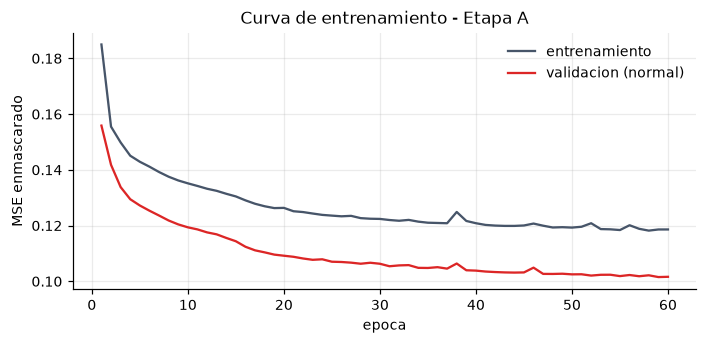

In [33]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(range(1, len(history["train"])+1), history["train"], label="entrenamiento", color="#475569")
ax.plot(range(1, len(history["val"])+1), history["val"], label="validacion (normal)", color="#dc2626")
ax.set_xlabel("epoca"); ax.set_ylabel("MSE enmascarado")
ax.set_title("Curva de entrenamiento - Etapa A")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()


## 14. Score de anomalía por secuencia: definición y selección

El error por paso de tiempo no define por sí solo el score de la secuencia. Hay tres decisiones encima de él, y este bloque las resuelve empíricamente sobre validación con métricas de ranking independientes del umbral (AUC-ROC y AUC-PR), sin reentrenar el modelo.

**Qué *features* entran en el error.** Promediar sobre las 24 *features* mezcla el comportamiento del remitente con 14 columnas *one-hot* de formato y moneda, cuyo error de reconstrucción depende sobre todo de la frecuencia base de cada categoría y no de si la secuencia es atípica. La alternativa es restringir el error a las 10 *features* numéricas y conductuales (monto, tiempo, destino), que son las que el remitente decide transacción a transacción.

**Cómo se agregan los errores de la ventana.** La Sección 2.2 mostró que un remitente positivo tiene en promedio 1.5 transacciones marcadas en ventanas de hasta 64: la media diluye esa señal entre el resto de la ventana, mientras que el máximo y las medias *top-k* la concentran a costa de más varianza.

**Si se corrige por longitud.** El error de reconstrucción depende de cuántas transacciones tiene la ventana, y esa duración por sí sola no es evidencia de lavado. La versión normalizada convierte el score en un z-score dentro de su cubeta de longitud; la media y la desviación de cada cubeta se estiman únicamente con el split de entrenamiento para no filtrar información de validación ni de prueba.

In [34]:
# El error se calcula dos veces por lote: sobre las 24 features y solo sobre las conductuales
BEHAV_COLS = [i for i, f in enumerate(meta["features"]) if not f.startswith(("fmt_", "cur_"))]
FEAT_SETS = {"todas": None, "conductuales": BEHAV_COLS}

all_loader = make_loader(np.arange(N_WIN))

errors_sorted = {k: {} for k in FEAT_SETS}   # conjunto de features -> ventana -> errores por transaccion, desc
win_len = np.zeros(N_WIN, dtype=np.int32)
model.eval()
with torch.no_grad():
    for xb, lens, mask, wids in all_loader:
        xb_d, mask_d = xb.to(DEVICE), mask.to(DEVICE)
        recon, _ = model(xb_d, lens)
        errs = {k: masked_timestep_error(recon, xb_d, mask_d, cols).cpu().numpy()
                for k, cols in FEAT_SETS.items()}
        lens_np = lens.numpy()
        for i, w in enumerate(wids.numpy()):
            w, ln = int(w), int(lens_np[i])
            win_len[w] = ln
            for k in FEAT_SETS:
                errors_sorted[k][w] = np.sort(errs[k][i, :ln])[::-1]

print(f"error por transaccion calculado para las {N_WIN:,} secuencias")
print(f"features conductuales ({len(BEHAV_COLS)}): {', '.join(meta['features'][i] for i in BEHAV_COLS)}")

error por transaccion calculado para las 199,364 secuencias
features conductuales (10): log_amt, amt_rel, log_dt, is_first_tx, hour_sin, hour_cos, dest_diversity, is_new_dest, is_self_transfer, is_cross_currency


In [35]:
AGGS = ["mean", "max"] + [f"top-{k}" for k in CFG2["TOPK_GRID"]]

def aggregate(errs, how):
    if how == "mean":
        return np.array([errs[w].mean() for w in range(N_WIN)])
    if how == "max":
        return np.array([errs[w][0] for w in range(N_WIN)])
    k = int(how.split("-")[1])
    return np.array([errs[w][:k].mean() for w in range(N_WIN)])

def length_normalize(s, n_bins=10):
    """z-score del score dentro de su cubeta de longitud. La media y la desviacion de cada
    cubeta se estiman solo con train, para no filtrar informacion de validacion ni de prueba."""
    edges = np.unique(np.quantile(win_len[split == 0], np.linspace(0, 1, n_bins + 1)))
    b = np.clip(np.digitize(win_len, edges[1:-1]), 0, len(edges) - 2)
    out = np.zeros_like(s)
    for j in np.unique(b):
        here = b == j
        ref = s[here & (split == 0)]
        out[here] = (s[here] - ref.mean()) / (ref.std() + 1e-9)
    return out

val_idx = np.where(split == 1)[0]
candidates, rows = {}, []
for feats in FEAT_SETS:
    for how in AGGS:
        raw = aggregate(errors_sorted[feats], how)
        for norm, s in [("crudo", raw), ("norm-longitud", length_normalize(raw))]:
            candidates[(feats, how, norm)] = s
            rows.append({"features": feats, "agregacion": how, "normalizacion": norm,
                          "AUC-ROC": roc_auc_score(y[val_idx], s[val_idx]),
                          "AUC-PR": average_precision_score(y[val_idx], s[val_idx])})

score_df = pd.DataFrame(rows)
pivot = score_df.pivot_table(index="agregacion", columns=["features", "normalizacion"],
                              values="AUC-PR").reindex(AGGS)
print(f"AUC-PR EN VALIDACION POR DEFINICION DEL SCORE ({len(candidates)} combinaciones)")
print(f"un score aleatorio da {y[val_idx].mean():.4f}, la prevalencia de positivos\n")
print(pivot.round(4).to_string())

AUC-PR EN VALIDACION POR DEFINICION DEL SCORE (32 combinaciones)
un score aleatorio da 0.0151, la prevalencia de positivos

features      conductuales                 todas              
normalizacion        crudo norm-longitud   crudo norm-longitud
agregacion                                                    
mean                0.0205        0.0384  0.0211        0.0361
max                 0.0201        0.0421  0.0210        0.0424
top-1               0.0201        0.0421  0.0210        0.0424
top-2               0.0183        0.0386  0.0193        0.0391
top-3               0.0174        0.0367  0.0181        0.0355
top-5               0.0167        0.0380  0.0171        0.0356
top-8               0.0168        0.0383  0.0170        0.0356
top-16              0.0174        0.0386  0.0175        0.0359


In [36]:
best_key = max(candidates, key=lambda k: average_precision_score(y[val_idx], candidates[k][val_idx]))
SCORE_FEATS, SCORE_AGG, SCORE_NORM = best_key
SCORE = candidates[best_key]
SCORE_COLS = FEAT_SETS[SCORE_FEATS]

base_ap = average_precision_score(y[val_idx], candidates[("todas", "mean", "crudo")][val_idx])
best_ap = average_precision_score(y[val_idx], SCORE[val_idx])
best_auc = roc_auc_score(y[val_idx], SCORE[val_idx])
prevalence = float(y[val_idx].mean())

print(f"Decision 15 | score de anomalia: features {SCORE_FEATS}, agregacion {SCORE_AGG}, {SCORE_NORM}")
print(f"  AUC-PR  = {best_ap:.4f}")
print(f"    vs. {base_ap:.4f} del error crudo promediado sobre las 24 features")
print(f"    vs. {prevalence:.4f} de un score aleatorio")
print(f"  AUC-ROC = {best_auc:.3f}")
print(f"  levante sobre la prevalencia: {best_ap/prevalence:.2f}x")

Decision 15 | score de anomalia: features todas, agregacion max, norm-longitud
  AUC-PR  = 0.0424
    vs. 0.0211 del error crudo promediado sobre las 24 features
    vs. 0.0151 de un score aleatorio
  AUC-ROC = 0.677
  levante sobre la prevalencia: 2.81x


## 15. Selección del umbral de decisión

Con un desbalance de ~1.5% de positivos, el punto de operación se elige sobre la curva precisión-recall de validación, maximizando F1. Ese umbral no es la única opción posible, ya que la tabla de puntos alternativos deja explícito el costo en tasa de alerta de exigir más recall, para que un equipo de cumplimiento pueda desplazar el punto de operación según cuántas alertas puede revisar al día.


In [37]:
prec, rec, thr = precision_recall_curve(y[val_idx], SCORE[val_idx])
f1 = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec + 1e-12), 0.0)
best_i = int(np.argmax(f1[:-1])) if len(thr) > 0 else 0
THRESHOLD = float(thr[best_i]) if len(thr) > 0 else float(SCORE[val_idx].max())

print(f"umbral elegido (maximo F1 en validacion): {THRESHOLD:.4f}")
print(f"  precision={prec[best_i]:.3f}  recall={rec[best_i]:.3f}  F1={f1[best_i]:.3f}")
alert_rate = float((SCORE[val_idx] >= THRESHOLD).mean())
print(f"  tasa de alerta en validacion: {100*alert_rate:.2f}% de las secuencias")

targets_recall = [0.5, 0.7, 0.8, 0.9, 0.95]
op_rows = []
for tr_ in targets_recall:
    idxs = np.where(rec[:-1] >= tr_)[0]
    if len(idxs) == 0:
        continue
    i = idxs[np.argmax(prec[:-1][idxs])]        # mejor precision entre los que alcanzan ese recall
    op_rows.append({"recall_objetivo": tr_, "umbral": thr[i], "precision": prec[i],
                     "recall_real": rec[i], "tasa_alerta_%": 100*(SCORE[val_idx] >= thr[i]).mean()})
print("\nPUNTOS DE OPERACION ALTERNATIVOS (validacion)")
print(pd.DataFrame(op_rows).round(4).to_string(index=False))


umbral elegido (maximo F1 en validacion): 2.6078
  precision=0.101  recall=0.169  F1=0.126
  tasa de alerta en validacion: 2.52% de las secuencias

PUNTOS DE OPERACION ALTERNATIVOS (validacion)
 recall_objetivo  umbral  precision  recall_real  tasa_alerta_%
            0.50  0.1633     0.0282       0.5100        27.2262
            0.70 -0.3101     0.0221       0.7118        48.5337
            0.80 -0.5083     0.0199       0.8071        61.2105
            0.90 -0.6976     0.0180       0.9024        75.8034
            0.95 -0.8106     0.0168       0.9512        85.2332


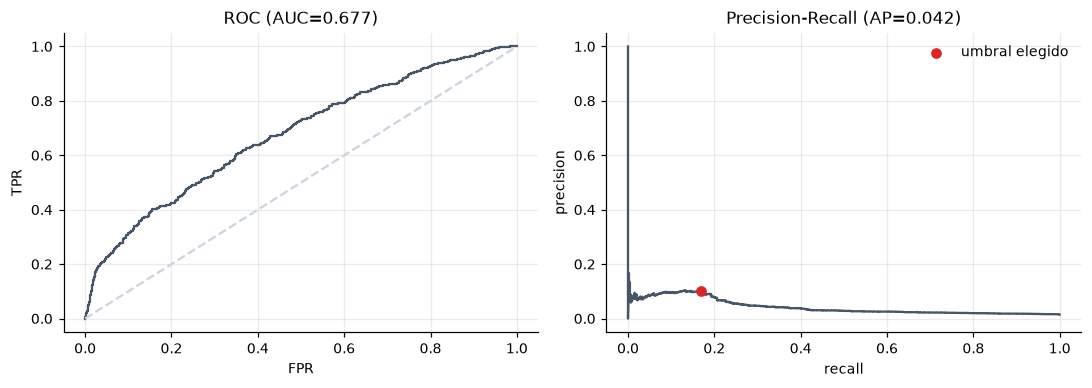

In [38]:
fpr, tpr, _ = roc_curve(y[val_idx], SCORE[val_idx])
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))

ax[0].plot(fpr, tpr, color="#475569")
ax[0].plot([0, 1], [0, 1], "--", color="#cbd5e1")
ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR")
ax[0].set_title(f"ROC (AUC={best_auc:.3f})")

ax[1].plot(rec, prec, color="#475569")
ax[1].scatter([rec[best_i]], [prec[best_i]], color="#dc2626", zorder=5, label="umbral elegido")
ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision")
ax[1].set_title(f"Precision-Recall (AP={best_ap:.3f})")
ax[1].legend(frameon=False)

plt.tight_layout(); plt.show()


## 16. Evaluación en validación y prueba

El umbral se congela en el valor elegido sobre validación y se aplica sin ajustes al conjunto de prueba. Siguiendo la Decisión 3 del Componente 1, el desempeño en prueba también se desglosa con y sin la cohorte institucional, para no atribuirle al sistema una capacidad de detección que en realidad está limitada a las cuentas hub de alto volumen.


In [39]:
def evaluate(idx, name, score=None, threshold=None):
    """Punto de operacion sobre un subconjunto de ventanas. Por defecto usa el score y el
    umbral de la Etapa A; la Etapa B pasa los suyos."""
    score = SCORE if score is None else score
    threshold = THRESHOLD if threshold is None else threshold
    pred = (score[idx] >= threshold).astype(int)
    p = precision_score(y[idx], pred, zero_division=0)
    r = recall_score(y[idx], pred, zero_division=0)
    f = f1_score(y[idx], pred, zero_division=0)
    cm = confusion_matrix(y[idx], pred, labels=[0, 1])
    print(f"{name:<16} n={len(idx):>7,}  precision={p:.3f}  recall={r:.3f}  F1={f:.3f}  "
          f"alertas={pred.sum():,} ({100*pred.mean():.2f}%)")
    return dict(split=name, n=len(idx), precision=p, recall=r, f1=f,
                tn=int(cm[0,0]), fp=int(cm[0,1]), fn=int(cm[1,0]), tp=int(cm[1,1]))

test_idx = np.where(split == 2)[0]
print("DESEMPENO CON EL UMBRAL FIJO DE VALIDACION")
res_val  = evaluate(val_idx,  "validacion")
res_test = evaluate(test_idx, "prueba")

print("\nDESGLOSE EN PRUEBA POR COHORTE (Decision 3, Componente 1)")
inst_mask_test = is_institutional[sender_code[test_idx]]
evaluate(test_idx[~inst_mask_test], "no-institucional")
if inst_mask_test.sum() > 0:
    evaluate(test_idx[inst_mask_test], "institucional")
else:
    print("institucional     n=0  (sin cuentas institucionales en el split de prueba)")

DESEMPENO CON EL UMBRAL FIJO DE VALIDACION
validacion       n= 29,905  precision=0.101  recall=0.169  F1=0.126  alertas=754 (2.52%)
prueba           n= 29,904  precision=0.093  recall=0.147  F1=0.114  alertas=709 (2.37%)

DESGLOSE EN PRUEBA POR COHORTE (Decision 3, Componente 1)
no-institucional n= 29,904  precision=0.093  recall=0.147  F1=0.114  alertas=709 (2.37%)
institucional     n=0  (sin cuentas institucionales en el split de prueba)


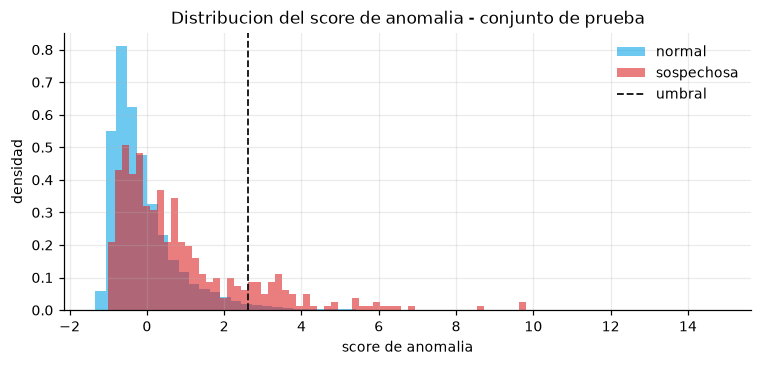

In [40]:
fig, ax = plt.subplots(figsize=(7, 3.4))
s_test = SCORE[test_idx]
ax.hist(s_test[y[test_idx] == 0], bins=60, alpha=0.6, label="normal", color="#0ea5e9", density=True)
ax.hist(s_test[y[test_idx] == 1], bins=60, alpha=0.6, label="sospechosa", color="#dc2626", density=True)
ax.axvline(THRESHOLD, color="#111", ls="--", lw=1.2, label="umbral")
ax.set_xlabel("score de anomalia"); ax.set_ylabel("densidad")
ax.set_title("Distribucion del score de anomalia - conjunto de prueba")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()


## 17. Trazabilidad: qué transacciones activan una alerta

El contexto del proyecto exige que el sistema pueda explicar qué transacciones específicas de un remitente activaron la alerta, no solo emitir un score agregado. Como el score final ya se construye a partir de los errores individuales por transacción (Sección 14), esa trazabilidad viene incluida y basta con ordenar las transacciones de la ventana marcada por su propio error de reconstrucción.


In [41]:
def explain_window(w, k=5):
    """Las k transacciones con mayor error de reconstruccion dentro de una ventana:
    la evidencia que un analista revisaria para justificar la alerta."""
    a, b = int(win_start[w]), int(win_end[w])
    seq = X[a:b]
    with torch.no_grad():
        xb = torch.from_numpy(seq).unsqueeze(0).to(DEVICE)
        lens = torch.tensor([seq.shape[0]])
        mask = torch.ones(1, seq.shape[0], dtype=torch.bool).to(DEVICE)
        recon, _ = model(xb, lens)
        err = masked_timestep_error(recon, xb, mask, SCORE_COLS).cpu().numpy()[0]
    order = np.argsort(err)[::-1][:k]
    return pd.DataFrame({"posicion_en_ventana": order, "error_reconstruccion": err[order]})


flagged_test = test_idx[(SCORE[test_idx] >= THRESHOLD) & (y[test_idx] == 1)]
if len(flagged_test) > 0:
    ejemplo = int(flagged_test[np.argmax(SCORE[flagged_test])])
    print(f"ejemplo: ventana {ejemplo}  (remitente {meta['sender_names'][sender_code[ejemplo]]}, "
          f"score={SCORE[ejemplo]:.3f})")
    print(explain_window(ejemplo).to_string(index=False))
else:
    print("ningun positivo de prueba supero el umbral en esta corrida; revisar tras entrenar")
    print("con los datos completos (esperable solo si el modelo aun no converge).")

ejemplo: ventana 94725  (remitente 80911C350, score=9.808)
 posicion_en_ventana  error_reconstruccion
                   4              0.593499
                   3              0.310668
                   2              0.044598
                   0              0.020128
                   1              0.016710


## 18. Exportación de artefactos de la Etapa A

Se guarda el score de anomalía de todas las secuencias para que el Componente 2 pueda usarlo como *feature* adicional al combinar ambas etapas, junto con los pesos del modelo y los metadatos de entrenamiento/evaluación necesarios para reproducir esta sección sin reentrenar.


In [42]:
np.savez(
    OUT_DIR / "stage_a_scores.npz",
    score=SCORE, score_base=candidates[("todas", "mean", "crudo")], win_len=win_len,
    y=y, split=split, sender_code=sender_code, threshold=THRESHOLD,
)

stage_a_meta = dict(
    score_features=SCORE_FEATS,
    score_aggregation=SCORE_AGG,
    score_normalization=SCORE_NORM,
    score_table=score_df.to_dict("records"),
    threshold=THRESHOLD,
    cfg=CFG2,
    history=history,
    val_metrics=res_val,
    test_metrics=res_test,
    n_epochs_trained=len(history["train"]),
)
with open(OUT_DIR / "stage_a_meta.json", "w") as f:
    json.dump(stage_a_meta, f, indent=2)

torch.save({"state_dict": model.state_dict(), "cfg": CFG2, "n_features": N_FEATS},
           OUT_DIR / "stage_a_model.pt")

for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p.name:<24} {p.stat().st_size/1e6:>8,.2f} MB")

alertas_test = res_test["tp"] + res_test["fp"]
print("\nRESUMEN ETAPA A (para el reporte)")
print(f"  definicion del score               : {SCORE_FEATS} / {SCORE_AGG} / {SCORE_NORM}")
print(f"  umbral                             : {THRESHOLD:.4f}")
print(f"  AUC-ROC / AUC-PR (validacion)      : {best_auc:.3f} / {best_ap:.4f}")
print(f"  AUC-PR de un score aleatorio       : {prevalence:.4f}")
print(f"  precision / recall / F1 (prueba)   : {res_test['precision']:.3f} / {res_test['recall']:.3f} / {res_test['f1']:.3f}")
print(f"  alertas en prueba                  : {alertas_test:,} de {res_test['n']:,} ({100*alertas_test/res_test['n']:.2f}%)")

  meta.json                    2.42 MB
  sequences.npz              452.04 MB
  stage_a_meta.json            0.01 MB
  stage_a_model.pt             0.20 MB
  stage_a_scores.npz           4.99 MB
  stage_b_attention.npz        2.68 MB
  stage_b_meta.json            0.01 MB
  stage_b_model.pt             0.12 MB
  stage_b_scores.npz           5.78 MB
  test_tx.parquet             10.07 MB

RESUMEN ETAPA A (para el reporte)
  definicion del score               : todas / max / norm-longitud
  umbral                             : 2.6078
  AUC-ROC / AUC-PR (validacion)      : 0.677 / 0.0424
  AUC-PR de un score aleatorio       : 0.0151
  precision / recall / F1 (prueba)   : 0.093 / 0.147 / 0.114
  alertas en prueba                  : 709 de 29,904 (2.37%)


## Resumen de decisiones: Etapa A

|  #   | Decisión                                                          | Justificación                                                                                                                    |
| :--: | ------------------------------------------------------------------ | --------------------------------------------------------------------------------------------------------------------------------- |
| **11** | Autoencoder LSTM encoder-decoder, no Transformer                 | Costo lineal en la longitud de secuencia; la atención se reserva para la Etapa B, con un conjunto de entrenamiento seis veces menor |
| **12** | Decodificador "repeat-vector" en vez de autoregresivo            | Evita el *exposure bias*; con *teacher forcing* el decodificador podría copiar el paso anterior y volver trivial la reconstrucción |
| **13** | Relleno dinámico por lote + máscara en la pérdida                | Evita materializar un tensor fijo (N,64,24) y que el relleno contamine el error de reconstrucción                                 |
| **14** | Validación de la Etapa A aproximada con `y=0` del split de validación | El artefacto no exporta la máscara "remitente limpio" fuera de *train*; limitación documentada explícitamente                |
| **15** | Score = **máximo** del error por transacción, **normalizado por longitud** | AUC-PR de 0.042 contra 0.021 del promedio crudo y 0.015 de un score aleatorio; la corrección por longitud es la que duplica la señal |
| **16** | Umbral por F1 máximo sobre la curva precisión-recall de validación | Con ~1.5 % de positivos el ROC es poco informativo; se reportan además puntos de operación alternativos para ajuste operativo    |

**Lo que no funcionó.** Restringir el error a las 10 *features* conductuales, excluyendo las columnas *one-hot* de formato y moneda, no cambió nada: 0.0421 contra 0.0424 de AUC-PR. La hipótesis de que las categorías metían ruido en el error era razonable, pero los datos no la sostienen y se reporta como tal en vez de omitirla.

**Limitación de la Etapa A.** Aun con el score mejor definido y el entrenamiento extendido a 60 épocas, el AUC-PR de 0.042 significa que en el punto de operación elegido una de cada diez alertas es real. Es 2.8 veces mejor que revisar al azar y mejor que las tasas de falsos positivos de 95-99 % de los sistemas por reglas que motivan el proyecto, pero no es utilizable por sí solo: la reconstrucción detecta que una secuencia es rara, no que sea lavado. Separar esas dos cosas es el trabajo de la Etapa B.

## Etapa B: Aprendizaje supervisado sobre casos etiquetados

La Etapa A aprendió a reconstruir comportamiento normal sin usar ninguna etiqueta. Esta etapa toma ese *encoder* ya entrenado, le agrega una capa de atención y una cabeza de clasificación, y lo ajusta con los 2,102 casos etiquetados disponibles en el *split* de entrenamiento. La pregunta que responde el componente no es solo si el clasificador funciona, sino si haber aprendido primero la normalidad aporta algo medible frente a entrenar el mismo clasificador desde cero.

**Flujo de esta sección:** datos etiquetados, clasificador con atención sobre el *encoder* transferido, función de pérdida para clases desbalanceadas, ablación contra la línea base sin Etapa A, fusión de las señales de ambas etapas, umbral operativo y evaluación en prueba, trazabilidad y exportación.

**Conexión con el curso.** La transferencia aplica las estrategias de la Semana 9: extracción de *features* con el *encoder* congelado y *fine-tuning* con tasa de aprendizaje discriminativa, comparadas contra inicialización aleatoria. La atención se implementa en su forma aditiva y es lo que hace auditable la alerta para el Componente 3 y el MVP.

## 19. Datos etiquetados y configuración de la Etapa B

El conjunto de entrenamiento es `stage_b_idx`, construido en la Sección 7: todos los positivos del *split* de entrenamiento más un submuestreo de negativos a 1:10 (Decisión 10). Validación y prueba conservan la prevalencia natural de 1.5 %, porque son los conjuntos con los que se elige el umbral y se reporta el desempeño, y un conjunto balanceado artificialmente daría una precisión optimista que no se sostendría en operación.

El submuestreo reduce el desbalance de 1:65 a 1:10 pero no lo elimina, y ese resto se compensa en la función de pérdida (Sección 21) en vez de con más submuestreo, que descartaría información de comportamiento normal que el clasificador sí necesita para separar.

In [43]:
stage_a_ckpt = torch.load(OUT_DIR / "stage_a_model.pt", map_location=DEVICE, weights_only=False)
train_b_idx = z["stage_b_idx"]
is_illicit_tx = z["is_illicit_tx"]   # etiqueta por transaccion, para la evidencia de la alerta

CFG3 = dict(
    ATTN_DIM     = 32,   # dimension interna de la atencion aditiva
    HEAD_HIDDEN  = 32,
    DROPOUT      = 0.2,  # mayor que en la Etapa A: 23 mil secuencias etiquetadas, mas riesgo de sobreajuste
    BATCH_SIZE   = 128,
    LR           = 1e-3, # atencion y cabeza
    ENC_LR_MULT  = 0.1,  # LR del encoder transferido como fraccion del de la cabeza
    ENC_LR_GRID  = [0.1, 0.3, 1.0],
    WEIGHT_DECAY = 1e-4,
    GRAD_CLIP    = 5.0,
    MAX_EPOCHS   = 30,
    PATIENCE     = 4,    # paro anticipado sobre el AUC-PR de validacion
    FOCAL_GAMMA  = 2.0,
    FOCAL_ALPHA  = 0.25,
    SEEDS        = [42, 1337],
    LABEL_FRACS  = [0.10, 0.25, 1.00],   # para medir el aporte del transfer con menos etiquetas
    SEED         = SEED,
)

n_pos_b = int(y[train_b_idx].sum())
POS_WEIGHT = (len(train_b_idx) - n_pos_b) / n_pos_b

assert (split[train_b_idx] == 0).all(), "ventanas de entrenamiento fuera del split de train"
assert len(np.intersect1d(train_b_idx, np.concatenate([val_idx, test_idx]))) == 0, "FUGA DETECTADA"

print(json.dumps(CFG3, indent=2))
print(f"\nCONJUNTOS DE LA ETAPA B")
print(f"{'conjunto':<22} | {'ventanas':>9} | {'positivas':>9} | {'% pos':>7}")
print("-" * 58)
for nm, ix in [("entrenamiento (1:10)", train_b_idx), ("validacion", val_idx), ("prueba", test_idx)]:
    npos = int(y[ix].sum())
    print(f"{nm:<22} | {len(ix):>9,} | {npos:>9,} | {100*npos/len(ix):>6.3f}%")
print(f"\npos_weight = {POS_WEIGHT:.1f} negativas por positiva en entrenamiento")

{
  "ATTN_DIM": 32,
  "HEAD_HIDDEN": 32,
  "DROPOUT": 0.2,
  "BATCH_SIZE": 128,
  "LR": 0.001,
  "ENC_LR_MULT": 0.1,
  "ENC_LR_GRID": [
    0.1,
    0.3,
    1.0
  ],
  "WEIGHT_DECAY": 0.0001,
  "GRAD_CLIP": 5.0,
  "MAX_EPOCHS": 30,
  "PATIENCE": 4,
  "FOCAL_GAMMA": 2.0,
  "FOCAL_ALPHA": 0.25,
  "SEEDS": [
    42,
    1337
  ],
  "LABEL_FRACS": [
    0.1,
    0.25,
    1.0
  ],
  "SEED": 42
}

CONJUNTOS DE LA ETAPA B
conjunto               |  ventanas | positivas |   % pos
----------------------------------------------------------
entrenamiento (1:10)   |    23,122 |     2,102 |  9.091%
validacion             |    29,905 |       451 |  1.508%
prueba                 |    29,904 |       450 |  1.505%

pos_weight = 10.0 negativas por positiva en entrenamiento


## 20. Arquitectura: *encoder* transferido con atención

El clasificador reutiliza el mismo `LSTMEncoder` de la Sección 12, con la misma forma y los mismos nombres de parámetros, para poder cargarle directamente los pesos guardados en `stage_a_model.pt`. La diferencia es qué se hace con la salida del LSTM.

**De último estado a atención.** La Etapa A comprimía la secuencia usando solo el último estado oculto, suficiente cuando el objetivo es reconstruir. Para clasificar no lo es: la evidencia de lavado puede estar en la transacción 7 de una ventana de 40 y el último estado la habría diluido. La atención aditiva aprende un peso por transacción, los normaliza con *softmax* sobre las posiciones reales de la secuencia (el relleno se enmascara antes del *softmax*, no después, para que no reciba probabilidad) y produce un vector de contexto como promedio ponderado. Ese peso es además la explicación de la alerta: dice qué transacciones miró el modelo, que es exactamente lo que un equipo de cumplimiento necesita antes de abrir una investigación.

**Entrada de la cabeza.** Se concatena el vector de contexto de la atención con el vector latente de 16 dimensiones que produce la Etapa A. El primero aporta la evidencia local y el segundo el resumen global del comportamiento del remitente, que es la representación que el modelo no supervisado ya sabía construir.

**Tres variantes de transferencia** que la ablación de la Sección 23 compara con todo lo demás igual:

- `scratch`: *encoder* inicializado al azar. Es la línea base obligatoria, el sistema sin Etapa A.
- `frozen`: *encoder* de la Etapa A congelado, solo se entrenan atención y cabeza. Es extracción de *features*, apropiada cuando hay pocos datos etiquetados.
- `finetune`: *encoder* de la Etapa A entrenable, con tasa de aprendizaje diez veces menor que la de la cabeza. Deja que la representación se adapte a la tarea supervisada sin borrar de golpe lo aprendido sobre normalidad.

In [44]:
class AttentionPooling(nn.Module):
    def __init__(self, hidden, attn_dim):
        super().__init__()
        self.proj = nn.Linear(hidden, attn_dim)
        self.score = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, h, mask):
        e = self.score(torch.tanh(self.proj(h))).squeeze(-1)    # (B, T) energia por transaccion
        e = e.masked_fill(~mask, float("-inf"))                  # el relleno no compite en el softmax
        a = torch.softmax(e, dim=1)
        ctx = (a.unsqueeze(-1) * h).sum(dim=1)                   # (B, hidden)
        return ctx, a


class StageBClassifier(nn.Module):
    def __init__(self, n_features, cfg_a, cfg_b):
        super().__init__()
        self.encoder = LSTMEncoder(n_features, cfg_a["ENC_HIDDEN"], cfg_a["ENC_LAYERS"],
                                    cfg_a["LATENT_DIM"], cfg_a["DROPOUT"])
        self.attn = AttentionPooling(cfg_a["ENC_HIDDEN"], cfg_b["ATTN_DIM"])
        self.head = nn.Sequential(
            nn.Dropout(cfg_b["DROPOUT"]),
            nn.Linear(cfg_a["ENC_HIDDEN"] + cfg_a["LATENT_DIM"], cfg_b["HEAD_HIDDEN"]),
            nn.ReLU(),
            nn.Dropout(cfg_b["DROPOUT"]),
            nn.Linear(cfg_b["HEAD_HIDDEN"], 1),
        )

    def forward(self, x, lengths, mask):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, (h_n, _) = self.encoder.lstm(packed)
        h, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True, total_length=x.shape[1])
        zlat = self.encoder.to_latent(h_n[-1])                   # (B, latent) - misma proyeccion de la Etapa A
        ctx, attn_w = self.attn(h, mask)                         # (B, hidden), (B, T)
        logit = self.head(torch.cat([ctx, zlat], dim=-1)).squeeze(-1)
        return logit, attn_w


def build_stage_b(variant, seed):
    """scratch: encoder aleatorio. frozen: encoder de la Etapa A congelado (extraccion de
    features). finetune: encoder de la Etapa A entrenable con LR discriminativo."""
    torch.manual_seed(seed)
    clf = StageBClassifier(N_FEATS, CFG2, CFG3).to(DEVICE)
    if variant != "scratch":
        enc_state = {k[len("encoder."):]: v for k, v in stage_a_ckpt["state_dict"].items()
                     if k.startswith("encoder.")}
        clf.encoder.load_state_dict(enc_state)
    if variant == "frozen":
        for p in clf.encoder.parameters():
            p.requires_grad = False
    return clf


VARIANTS = ["scratch", "frozen", "finetune"]
print(f"{'variante':<10} | {'parametros':>10} | {'entrenables':>11}")
print("-" * 38)
for v in VARIANTS:
    clf = build_stage_b(v, SEED)
    tot = sum(p.numel() for p in clf.parameters())
    ent = sum(p.numel() for p in clf.parameters() if p.requires_grad)
    print(f"{v:<10} | {tot:>10,} | {ent:>11,}")

# Verificacion de la mascara: la atencion suma 1 sobre las posiciones reales y 0 sobre el relleno
xb, lens, mask, _ = next(iter(make_loader(train_b_idx, batch_size=CFG3["BATCH_SIZE"])))
with torch.no_grad():
    _, aw = clf(xb.to(DEVICE), lens, mask.to(DEVICE))
aw, mask = aw.cpu(), mask
print(f"\nsuma de la atencion sobre posiciones validas: {aw.sum(1).min():.4f} a {aw.sum(1).max():.4f}")
print(f"peso maximo asignado a una posicion de relleno: {(aw * ~mask).max():.2e}")

variante   | parametros | entrenables
--------------------------------------
scratch    |     28,817 |      28,817
frozen     |     28,817 |       4,737
finetune   |     28,817 |      28,817

suma de la atencion sobre posiciones validas: 1.0000 a 1.0000
peso maximo asignado a una posicion de relleno: 0.00e+00


## 21. Función de pérdida y desbalance residual

Aun después del submuestreo 1:10, una entropía cruzada binaria sin pesos optimiza una métrica que se satisface prediciendo siempre "normal": el 91 % de los ejemplos de entrenamiento son negativos y el gradiente de las positivas queda dominado. Se comparan tres opciones sobre el mismo modelo y la misma semilla:

- **`bce`**: entropía cruzada binaria sin corrección. Sirve como referencia para medir cuánto cambia realmente la elección de la pérdida.
- **`bce_pos_weight`**: cada positiva pesa `pos_weight` veces lo que una negativa, con `pos_weight` igual a la razón de negativas a positivas del conjunto de entrenamiento. Es la corrección mínima y directa del desbalance, y deja las probabilidades interpretables como evidencia relativa.
- **`focal`**: pérdida focal, que además de un peso fijo por clase reduce el peso de los ejemplos que el modelo ya clasifica bien. La hipótesis es que en un problema con 1.5 % de positivos la mayoría de las negativas son fáciles y no deberían dominar el gradiente.

En un contexto AML el costo de los dos errores no es simétrico: un falso negativo es una operación sospechosa reportada nunca, con consecuencia regulatoria, mientras que un falso positivo cuesta horas de análisis. Por eso ninguna de las tres se descarta a priori y la elección se hace por AUC-PR de validación, que es la métrica que refleja ese costo.

In [45]:
def focal_loss_with_logits(logit, target, gamma, alpha):
    """Focal loss binaria: pt es la probabilidad asignada a la clase correcta y el factor
    (1-pt)^gamma baja el peso de los ejemplos ya resueltos, que aqui son casi todos negativos."""
    bce = nn.functional.binary_cross_entropy_with_logits(logit, target, reduction="none")
    p = torch.sigmoid(logit)
    pt = torch.where(target > 0.5, p, 1 - p)
    w = (alpha * target + (1 - alpha) * (1 - target)) * (1 - pt) ** gamma
    return (w * bce).mean()


def make_loss(name):
    if name == "bce":
        return lambda lg, t: nn.functional.binary_cross_entropy_with_logits(lg, t)
    if name == "bce_pos_weight":
        pw = torch.tensor(POS_WEIGHT, device=DEVICE)
        return lambda lg, t: nn.functional.binary_cross_entropy_with_logits(lg, t, pos_weight=pw)
    if name == "focal":
        return lambda lg, t: focal_loss_with_logits(lg, t, CFG3["FOCAL_GAMMA"], CFG3["FOCAL_ALPHA"])
    raise ValueError(f"perdida desconocida: {name}")


LOSSES = ["bce", "bce_pos_weight", "focal"]
print(f"pesos relativos de una positiva frente a una negativa")
print(f"  bce            : 1.0")
print(f"  bce_pos_weight : {POS_WEIGHT:.1f}")
print(f"  focal          : {CFG3['FOCAL_ALPHA']/(1-CFG3['FOCAL_ALPHA']):.2f} fijo, mas el factor "
      f"(1-pt)^{CFG3['FOCAL_GAMMA']:.0f} que depende de cada ejemplo")

pesos relativos de una positiva frente a una negativa
  bce            : 1.0
  bce_pos_weight : 10.0
  focal          : 0.33 fijo, mas el factor (1-pt)^2 que depende de cada ejemplo


## 22. Protocolo de entrenamiento y ajuste del *fine-tuning*

`train_stage_b` entrena una combinación de variante, pérdida, semilla y tasa de aprendizaje del *encoder*, y guarda el resultado en caché para que los barridos y la ablación no repitan corridas. Todas las combinaciones comparten conjunto de entrenamiento, arquitectura, optimizador, presupuesto de épocas y criterio de paro, de modo que la única diferencia entre las filas de la ablación sea de dónde salen los pesos iniciales del *encoder*.

El paro anticipado no monitorea la pérdida sino el **AUC-PR de validación**, porque las tres pérdidas candidatas no son comparables entre sí en valor absoluto y ninguna mide lo que importa operativamente. El estado que se conserva es el de la mejor época según esa métrica.

**Cuánto dejar mover al *encoder* transferido.** La receta habitual de *fine-tuning* usa una tasa de aprendizaje menor para las capas preentrenadas, bajo el supuesto de que la representación heredada ya es buena y conviene no destruirla. Ese supuesto hay que verificarlo, no asumirlo: la Etapa A quedó con un AUC-PR de 0.042, o sea que su representación es informativa pero débil. El barrido compara tres proporciones entre la tasa del *encoder* y la de la cabeza, y la elección se hace por AUC-PR de validación.

In [46]:
RUNS = {}   # (variante, perdida, semilla, lr_encoder, fraccion) -> (modelo, historia)

def score_windows(clf, idx, with_attention=False):
    """Probabilidad de lavado por ventana y, si se pide, el peso de atencion de cada transaccion."""
    prob = np.zeros(len(idx), dtype=np.float32)
    attn, pos = {}, {int(w): i for i, w in enumerate(idx)}
    clf.eval()
    with torch.no_grad():
        for xb, lens, mask, wids in make_loader(idx, batch_size=1024):
            logit, aw = clf(xb.to(DEVICE), lens, mask.to(DEVICE))
            p = torch.sigmoid(logit).cpu().numpy()
            aw_np, lens_np = aw.cpu().numpy(), lens.numpy()
            for i, w in enumerate(wids.numpy()):
                prob[pos[int(w)]] = p[i]
                if with_attention:
                    attn[int(w)] = aw_np[i, :lens_np[i]]
    return prob, attn


def prob_all(clf):
    p = np.zeros(N_WIN, dtype=np.float32)
    for ix in (val_idx, test_idx):
        p[ix] = score_windows(clf, ix)[0]
    return p


def f1_threshold(score_arr):
    """Umbral de F1 maximo sobre la curva precision-recall de validacion (Decision 16)."""
    pr, rc, th = precision_recall_curve(y[val_idx], score_arr[val_idx])
    f1c = np.where((pr + rc) > 0, 2 * pr * rc / (pr + rc + 1e-12), 0.0)
    return float(th[int(np.argmax(f1c[:-1]))])


def summarize(score_arr, nombre):
    """Fila de metricas de un score cualquiera: ranking en validacion y prueba, y el punto
    de operacion en prueba con el umbral fijado en validacion."""
    thr = f1_threshold(score_arr)
    pred = (score_arr[test_idx] >= thr).astype(int)
    return {"modelo": nombre,
            "AUC-PR val": average_precision_score(y[val_idx], score_arr[val_idx]),
            "AUC-PR prueba": average_precision_score(y[test_idx], score_arr[test_idx]),
            "AUC-ROC prueba": roc_auc_score(y[test_idx], score_arr[test_idx]),
            "precision": precision_score(y[test_idx], pred, zero_division=0),
            "recall": recall_score(y[test_idx], pred, zero_division=0),
            "F1": f1_score(y[test_idx], pred, zero_division=0),
            "alerta_%": 100 * pred.mean()}


def subsample_labeled(frac, seed):
    """Submuestreo estratificado del conjunto etiquetado, conservando la razon 1:10."""
    if frac >= 1.0:
        return train_b_idx
    r = np.random.default_rng(seed)
    keep = [r.choice(train_b_idx[y[train_b_idx] == c], int(round(frac * (y[train_b_idx] == c).sum())),
                      replace=False) for c in (0, 1)]
    return np.sort(np.concatenate(keep))


def train_stage_b(variant, loss_name, seed, enc_lr_mult=None, frac=1.0):
    enc_lr_mult = CFG3["ENC_LR_MULT"] if enc_lr_mult is None else enc_lr_mult
    key = (variant, loss_name, seed, enc_lr_mult, frac)
    if key in RUNS:
        return RUNS[key]

    clf = build_stage_b(variant, seed)
    enc_params = [p for p in clf.encoder.parameters() if p.requires_grad]
    head_params = [p for n, p in clf.named_parameters() if not n.startswith("encoder.")]
    groups = [{"params": head_params, "lr": CFG3["LR"]}]
    if enc_params:   # LR discriminativo: el encoder transferido se mueve mas lento que la cabeza
        groups.append({"params": enc_params,
                        "lr": CFG3["LR"] * (enc_lr_mult if variant == "finetune" else 1.0)})
    opt_b = torch.optim.Adam(groups, weight_decay=CFG3["WEIGHT_DECAY"])
    loss_fn = make_loss(loss_name)
    loader = make_loader(subsample_labeled(frac, seed), batch_size=CFG3["BATCH_SIZE"],
                          shuffle=True, drop_last=True)

    hist = {"train": [], "val_ap": []}
    best_ap, best_state, bad = -1.0, None, 0
    t0 = time.time()
    for epoch in range(1, CFG3["MAX_EPOCHS"] + 1):
        clf.train()
        tot, n = 0.0, 0
        for xb, lens, mask, wids in loader:
            yb = torch.from_numpy(y[wids.numpy()]).float().to(DEVICE)
            logit, _ = clf(xb.to(DEVICE), lens, mask.to(DEVICE))
            loss = loss_fn(logit, yb)
            opt_b.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(clf.parameters(), CFG3["GRAD_CLIP"])
            opt_b.step()
            tot += loss.item() * xb.shape[0]
            n += xb.shape[0]
        ap = average_precision_score(y[val_idx], score_windows(clf, val_idx)[0])
        hist["train"].append(tot / n); hist["val_ap"].append(ap)
        if ap > best_ap + 1e-5:
            best_ap, bad = ap, 0
            best_state = {k: v.detach().clone() for k, v in clf.state_dict().items()}
        else:
            bad += 1
            if bad >= CFG3["PATIENCE"]:
                break

    clf.load_state_dict(best_state)
    etiquetas = "" if frac >= 1.0 else f" etiquetas={frac:.0%}"
    print(f"  {variant:<9} {loss_name:<15} semilla={seed:<5} lr_enc={enc_lr_mult:<4}{etiquetas} "
          f"epocas={len(hist['train']):>2}  AUC-PR val={best_ap:.4f}  ({time.time()-t0:.0f}s)")
    RUNS[key] = (clf, hist)
    return RUNS[key]

In [47]:
print("BARRIDO DEL LR DEL ENCODER TRANSFERIDO (variante finetune, perdida bce_pos_weight)")
lr_rows = []
for mult in CFG3["ENC_LR_GRID"]:
    _, hist_lr = train_stage_b("finetune", "bce_pos_weight", SEED, enc_lr_mult=mult)
    lr_rows.append({"lr_encoder / lr_cabeza": mult, "AUC-PR val": max(hist_lr["val_ap"]),
                     "epocas": len(hist_lr["train"])})

lr_df = pd.DataFrame(lr_rows).sort_values("AUC-PR val", ascending=False)
ENC_LR = float(lr_df.iloc[0]["lr_encoder / lr_cabeza"])
print()
print(lr_df.round(4).to_string(index=False))
print(f"\nDecision 18 | el encoder transferido se ajusta con lr_encoder = {ENC_LR:.1f} x lr_cabeza")

BARRIDO DEL LR DEL ENCODER TRANSFERIDO (variante finetune, perdida bce_pos_weight)


  finetune  bce_pos_weight  semilla=42    lr_enc=0.1  epocas=30  AUC-PR val=0.3858  (65s)


  finetune  bce_pos_weight  semilla=42    lr_enc=0.3  epocas=29  AUC-PR val=0.4038  (63s)


  finetune  bce_pos_weight  semilla=42    lr_enc=1.0  epocas=19  AUC-PR val=0.4121  (42s)

 lr_encoder / lr_cabeza  AUC-PR val  epocas
                    1.0      0.4121      19
                    0.3      0.4038      29
                    0.1      0.3858      30

Decision 18 | el encoder transferido se ajusta con lr_encoder = 1.0 x lr_cabeza


In [48]:
print(f"COMPARACION DE FUNCIONES DE PERDIDA (finetune, lr_encoder {ENC_LR:.1f}x, semilla {SEED})")
loss_rows = []
for name in LOSSES:
    clf_l, hist_l = train_stage_b("finetune", name, SEED, enc_lr_mult=ENC_LR)
    loss_rows.append({"perdida": name, "AUC-PR val": max(hist_l["val_ap"]),
                       "epocas": len(hist_l["train"])})

loss_df = pd.DataFrame(loss_rows).sort_values("AUC-PR val", ascending=False)
LOSS = loss_df.iloc[0]["perdida"]
print()
print(loss_df.round(4).to_string(index=False))
print(f"\nDecision 19 | perdida elegida: {LOSS}")

COMPARACION DE FUNCIONES DE PERDIDA (finetune, lr_encoder 1.0x, semilla 42)


  finetune  bce             semilla=42    lr_enc=1.0  epocas=29  AUC-PR val=0.4383  (64s)


  finetune  focal           semilla=42    lr_enc=1.0  epocas=29  AUC-PR val=0.4337  (67s)

       perdida  AUC-PR val  epocas
           bce      0.4383      29
         focal      0.4337      29
bce_pos_weight      0.4121      19

Decision 19 | perdida elegida: bce


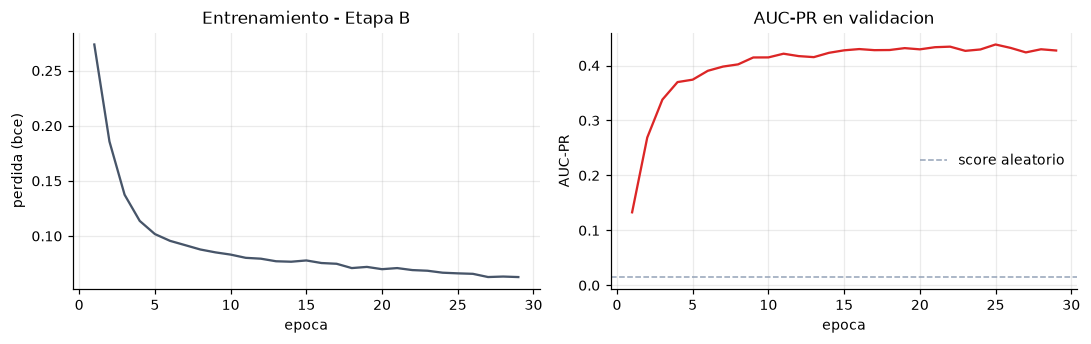

In [49]:
_, hist_main = RUNS[("finetune", LOSS, SEED, ENC_LR, 1.0)]
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))

ax[0].plot(range(1, len(hist_main["train"])+1), hist_main["train"], color="#475569")
ax[0].set_xlabel("epoca"); ax[0].set_ylabel(f"perdida ({LOSS})")
ax[0].set_title("Entrenamiento - Etapa B")

ax[1].plot(range(1, len(hist_main["val_ap"])+1), hist_main["val_ap"], color="#dc2626")
ax[1].axhline(y[val_idx].mean(), ls="--", lw=1, color="#94a3b8", label="score aleatorio")
ax[1].set_xlabel("epoca"); ax[1].set_ylabel("AUC-PR")
ax[1].set_title("AUC-PR en validacion")
ax[1].legend(frameon=False)

plt.tight_layout(); plt.show()

## 23. Ablación: qué aporta la Etapa A

Este es el experimento de demostración obligatorio. Las tres variantes se entrenan con la pérdida y la tasa de aprendizaje ya elegidas, dos semillas cada una, y se comparan contra el score de la Etapa A sola con las mismas métricas y el mismo criterio de umbral. Todo lo demás es idéntico entre variantes, así que la diferencia es atribuible al origen de los pesos del *encoder*.

**Por qué AUC-PR como métrica primaria.** Con 1.5 % de positivos, el AUC-ROC se ve bien incluso cuando el sistema es inservible, porque los verdaderos negativos son tantos que la tasa de falsos positivos casi no se mueve. El AUC-PR mide precisión a lo largo de todos los niveles de recall y su piso es la prevalencia misma, así que un valor de 0.015 significa exactamente "no aprendió nada". En términos del negocio: un equipo de cumplimiento revisa una cola de alertas priorizada y lo que le importa es qué fracción de esa cola es real, que es precisamente lo que resume el AUC-PR.

Se reportan además precisión, recall, F1 y tasa de alerta en el umbral de F1 máximo de validación, porque son las cifras que definen la carga de trabajo diaria del equipo. La elección del modelo que sigue al resto del componente se hace por AUC-PR de **validación**; las columnas de prueba solo se reportan.

**Segundo experimento: eficiencia en etiquetas.** Si el preentrenamiento no cambia el resultado con las 2,102 secuencias positivas disponibles, la hipótesis natural es que sí lo haría con menos, que es el argumento clásico a favor del *transfer learning* y el escenario realista de una empresa de remesas que arranca su programa de cumplimiento con pocos casos confirmados. El segundo bloque repite la comparación entrenando con el 10 % y el 25 % del conjunto etiquetado, submuestreado de forma estratificada para conservar la razón 1:10.

In [50]:
LABELS = {"scratch": "supervisado desde cero", "frozen": "encoder congelado (Etapa A)",
           "finetune": "fine-tuning (Etapa A)"}
METRICS = ["AUC-PR val", "AUC-PR prueba", "AUC-ROC prueba", "precision", "recall", "F1", "alerta_%"]

print(f"ABLACION: {len(VARIANTS)} variantes x {len(CFG3['SEEDS'])} semillas, perdida {LOSS}")
abl_rows, PROBS = [], {}
for variant in VARIANTS:
    for seed in CFG3["SEEDS"]:
        clf_v, hist_v = train_stage_b(variant, LOSS, seed, enc_lr_mult=ENC_LR)
        PROBS[(variant, seed)] = prob_all(clf_v)
        row = summarize(PROBS[(variant, seed)], variant)
        row.update(semilla=seed, epocas=len(hist_v["train"]))
        abl_rows.append(row)

abl_df = pd.DataFrame(abl_rows)
tabla = [summarize(SCORE, "Etapa A sola (reconstruccion)")]
for v in VARIANTS:
    d = abl_df[abl_df["modelo"] == v]
    fila = {"modelo": LABELS[v], **{m: d[m].mean() for m in METRICS}, "epocas": d["epocas"].mean()}
    tabla.append(fila)

print("\nPROMEDIO SOBRE SEMILLAS (el score de la Etapa A no depende de la semilla)")
print(pd.DataFrame(tabla).round(4).to_string(index=False))

print("\nDISPERSION ENTRE SEMILLAS (AUC-PR en prueba)")
for v in VARIANTS:
    d = abl_df[abl_df["modelo"] == v]["AUC-PR prueba"]
    print(f"  {LABELS[v]:<28} {d.mean():.4f} +/- {d.std():.4f}   [{', '.join(f'{x:.4f}' for x in d)}]")

ap_scratch = abl_df[abl_df["modelo"] == "scratch"]["AUC-PR prueba"].mean()
ap_ft = abl_df[abl_df["modelo"] == "finetune"]["AUC-PR prueba"].mean()
print(f"\naporte de la Etapa A: {100*(ap_ft-ap_scratch)/ap_scratch:+.1f}% de AUC-PR en prueba "
      f"frente a la linea base entrenada desde cero")

# El modelo que sigue al resto del componente se elige por AUC-PR de validacion, nunca de prueba
best_row = abl_df.loc[abl_df["AUC-PR val"].idxmax()]
BEST_VARIANT, BEST_SEED = best_row["modelo"], int(best_row["semilla"])
CLF = RUNS[(BEST_VARIANT, LOSS, BEST_SEED, ENC_LR, 1.0)][0]
PROB = PROBS[(BEST_VARIANT, BEST_SEED)]
print(f"\nmodelo que sigue al resto del componente: {LABELS[BEST_VARIANT]}, semilla {BEST_SEED}")

ABLACION: 3 variantes x 2 semillas, perdida bce


  scratch   bce             semilla=42    lr_enc=1.0  epocas=19  AUC-PR val=0.4364  (43s)


  scratch   bce             semilla=1337  lr_enc=1.0  epocas=22  AUC-PR val=0.4315  (48s)


  frozen    bce             semilla=42    lr_enc=1.0  epocas=30  AUC-PR val=0.2541  (35s)


  frozen    bce             semilla=1337  lr_enc=1.0  epocas=30  AUC-PR val=0.2502  (35s)


  finetune  bce             semilla=1337  lr_enc=1.0  epocas=19  AUC-PR val=0.4355  (41s)



PROMEDIO SOBRE SEMILLAS (el score de la Etapa A no depende de la semilla)
                       modelo  AUC-PR val  AUC-PR prueba  AUC-ROC prueba  precision  recall     F1  alerta_%  epocas
Etapa A sola (reconstruccion)      0.0424         0.0436          0.6905     0.0931  0.1467 0.1139    2.3709     NaN
       supervisado desde cero      0.4340         0.4192          0.9276     0.9271  0.2678 0.4155    0.4347    20.5
  encoder congelado (Etapa A)      0.2521         0.2259          0.8055     0.6507  0.1467 0.2393    0.3394    30.0
        fine-tuning (Etapa A)      0.4369         0.4192          0.9244     0.9167  0.2689 0.4158    0.4414    24.0

DISPERSION ENTRE SEMILLAS (AUC-PR en prueba)
  supervisado desde cero       0.4192 +/- 0.0024   [0.4209, 0.4175]
  encoder congelado (Etapa A)  0.2259 +/- 0.0036   [0.2234, 0.2285]
  fine-tuning (Etapa A)        0.4192 +/- 0.0053   [0.4155, 0.4229]

aporte de la Etapa A: +0.0% de AUC-PR en prueba frente a la linea base entrenada desde ce

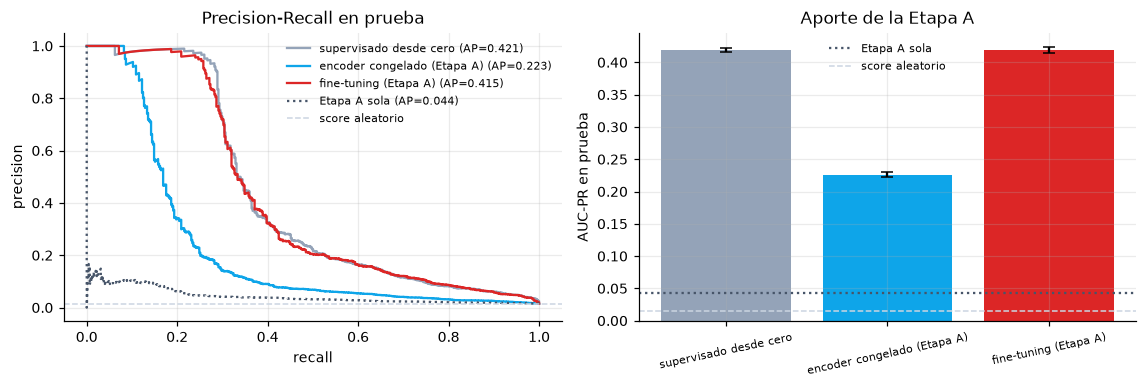

In [51]:
COLORS = {"scratch": "#94a3b8", "frozen": "#0ea5e9", "finetune": "#dc2626"}
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6))

for v in VARIANTS:
    d = abl_df[abl_df["modelo"] == v]
    seed_v = int(d.loc[d["AUC-PR val"].idxmax(), "semilla"])
    p = PROBS[(v, seed_v)]
    pr_v, rc_v, _ = precision_recall_curve(y[test_idx], p[test_idx])
    ax[0].plot(rc_v, pr_v, color=COLORS[v],
                label=f"{LABELS[v]} (AP={average_precision_score(y[test_idx], p[test_idx]):.3f})")

pr_a, rc_a, _ = precision_recall_curve(y[test_idx], SCORE[test_idx])
ax[0].plot(rc_a, pr_a, color="#475569", ls=":",
            label=f"Etapa A sola (AP={average_precision_score(y[test_idx], SCORE[test_idx]):.3f})")
ax[0].axhline(y[test_idx].mean(), ls="--", lw=1, color="#cbd5e1", label="score aleatorio")
ax[0].set_xlabel("recall"); ax[0].set_ylabel("precision")
ax[0].set_title("Precision-Recall en prueba")
ax[0].legend(frameon=False, fontsize=7.5)

means = [abl_df[abl_df["modelo"] == v]["AUC-PR prueba"].mean() for v in VARIANTS]
errs = [abl_df[abl_df["modelo"] == v]["AUC-PR prueba"].std() for v in VARIANTS]
ax[1].bar([LABELS[v] for v in VARIANTS], means, yerr=errs, capsize=4,
           color=[COLORS[v] for v in VARIANTS])
ax[1].axhline(average_precision_score(y[test_idx], SCORE[test_idx]), ls=":", color="#475569",
               label="Etapa A sola")
ax[1].axhline(y[test_idx].mean(), ls="--", lw=1, color="#cbd5e1", label="score aleatorio")
ax[1].set_ylabel("AUC-PR en prueba")
ax[1].set_title("Aporte de la Etapa A")
ax[1].tick_params(axis="x", labelrotation=12, labelsize=7.5)
ax[1].legend(frameon=False, fontsize=7.5)

plt.tight_layout(); plt.show()

In [52]:
print("EFICIENCIA EN ETIQUETAS: el aporte de la Etapa A cuando hay menos casos confirmados")
lab_rows = []
for frac in CFG3["LABEL_FRACS"]:
    fila = {"etiquetas_%": 100 * frac, "positivas": int(y[subsample_labeled(frac, SEED)].sum())}
    for v in ["scratch", "finetune"]:
        _, hist_f = train_stage_b(v, LOSS, SEED, enc_lr_mult=ENC_LR, frac=frac)
        fila[LABELS[v]] = max(hist_f["val_ap"])
    fila["diferencia"] = fila[LABELS["finetune"]] - fila[LABELS["scratch"]]
    lab_rows.append(fila)

lab_df = pd.DataFrame(lab_rows)
print("\nAUC-PR en validacion")
print(lab_df.round(4).to_string(index=False))

EFICIENCIA EN ETIQUETAS: el aporte de la Etapa A cuando hay menos casos confirmados


  scratch   bce             semilla=42    lr_enc=1.0  etiquetas=10% epocas=30  AUC-PR val=0.3056  (16s)


  finetune  bce             semilla=42    lr_enc=1.0  etiquetas=10% epocas=21  AUC-PR val=0.2088  (11s)


  scratch   bce             semilla=42    lr_enc=1.0  etiquetas=25% epocas=29  AUC-PR val=0.3896  (23s)


  finetune  bce             semilla=42    lr_enc=1.0  etiquetas=25% epocas=23  AUC-PR val=0.3449  (18s)

AUC-PR en validacion
 etiquetas_%  positivas  supervisado desde cero  fine-tuning (Etapa A)  diferencia
        10.0        210                  0.3056                 0.2088     -0.0968
        25.0        526                  0.3896                 0.3449     -0.0448
       100.0       2102                  0.4364                 0.4383      0.0018


### Lectura de la ablación

**1. Con todas las etiquetas, el *fine-tuning* empata con la línea base.** 0.4192 de AUC-PR en prueba contra 0.4192, y la diferencia en validación (0.4369 contra 0.4340) es menor que la dispersión entre semillas de la propia línea base. Con 2,102 secuencias positivas, la señal supervisada alcanza para aprender el *encoder* desde cero y la inicialización de la Etapa A no aporta nada medible.

**2. Congelar el *encoder* cuesta casi la mitad del desempeño.** La variante de extracción de *features* se queda en 0.2259 y solo alcanza un recall de 0.147. La representación de la Etapa A no es un extractor suficiente: un autoencoder comprime lo que es **frecuente**, no lo que **discrimina**, y esas dos cosas no coinciden cuando el 98.5 % de las secuencias son normales.

**3. Tener menos etiquetas tampoco rescata la transferencia.** Era la hipótesis más razonable a favor del preentrenamiento y el experimento la contradice: con el 10 % de las etiquetas (210 positivas) el *fine-tuning* queda 0.097 de AUC-PR por debajo de entrenar desde cero, y con el 25 % queda 0.045 por debajo. Partir de pesos orientados a reconstruir montos e intervalos parece ser un punto de partida peor que partir libre, y cuanto menos presupuesto de datos hay para corregir ese sesgo, más cuesta.

**4. La tasa de aprendizaje discriminativa, la receta estándar de la Semana 9, fue contraproducente aquí.** Mover el *encoder* diez veces más lento que la cabeza (0.3858) es peor que moverlo a la misma velocidad (0.4121), justo al revés de lo que ocurre cuando se parte de una representación fuerte tipo ImageNet o BERT. Es coherente con el resto: la representación heredada es débil, así que protegerla es proteger un mal punto de partida.

**5. La pérdida ponderada tampoco ayudó.** La entropía cruzada simple (0.4383) superó a la versión con `pos_weight = 10` (0.4121) y a la focal (0.4337). El submuestreo 1:10 del Componente 1 ya había hecho el grueso de la corrección del desbalance, y volver a pesar encima sobre-representa a las positivas, lo que degrada el orden en la parte alta del ranking, que es precisamente la que revisa un analista.

**Qué sí aporta entonces la arquitectura de dos etapas.** Para la calidad de detección con este volumen de etiquetas, la respuesta honesta es que la Etapa B hace todo el trabajo. Lo que la Etapa A aporta es de otra naturaleza y se mide en la Sección 24: un score de anomalía que no necesita ninguna etiqueta, que puede marcar tipologías que no aparecen en los casos confirmados, que da un piso de operación para un corredor nuevo sin historial de casos, y que entrega el error por transacción que acompaña a los pesos de atención en la evidencia de la alerta. Reportar esto como un empate y no como una mejora es parte del resultado: un sistema de cumplimiento que se justifica con una ganancia que no existe es un riesgo regulatorio, no una ventaja técnica.

## 24. Fusión de las señales de las dos etapas

Las dos etapas miran el problema desde ángulos distintos: la Etapa A mide cuánto se aleja una secuencia de la normalidad aprendida sin haber visto una sola etiqueta, y la Etapa B estima directamente la probabilidad de lavado a partir de los casos conocidos. La primera puede detectar tipologías que no aparecen en los datos etiquetados; la segunda es mucho más precisa en las que sí aparecen.

La combinación se hace a nivel de score y no dentro de la red, por tres razones: no requiere reentrenar, deja las dos señales visibles por separado en el MVP (que debe mostrar ambas), y su único parámetro es interpretable como cuánto peso se le da a la señal no supervisada.

Ambos scores viven en escalas distintas, así que primero se convierten a percentiles usando la distribución de validación y luego se combinan de forma convexa. El peso se elige por AUC-PR de validación, y si el óptimo resulta ser cero la conclusión es que la Etapa A no aporta señal adicional a nivel de score: su aporte, si lo hay, está en la representación transferida que la ablación ya midió.

In [53]:
def rank_normalize(s):
    """Percentil de cada score respecto de la distribucion de validacion. Deja las dos señales
    en la misma escala sin suponer nada sobre la forma de sus distribuciones."""
    ref = np.sort(s[val_idx])
    return np.searchsorted(ref, s, side="right") / len(ref)


rank_a, rank_b = rank_normalize(SCORE), rank_normalize(PROB)
ws = np.round(np.arange(0, 1.001, 0.05), 2)
ap_w = np.array([average_precision_score(y[val_idx], ((1 - w) * rank_b + w * rank_a)[val_idx])
                  for w in ws])

FUSION_W = float(ws[int(np.argmax(ap_w))])
# Con peso cero la mezcla de escalas ya no hace falta y la probabilidad cruda de la Etapa B
# conserva mas resolucion que su version en rangos
FINAL = PROB if FUSION_W == 0 else (1 - FUSION_W) * rank_b + FUSION_W * rank_a

print("BARRIDO DEL PESO DE LA ETAPA A EN LA FUSION (AUC-PR en validacion, paso de 0.05)")
for w, ap in zip(ws, ap_w):
    if round(w * 100) % 10 == 0:
        print(f"  w={w:.2f}  AUC-PR={ap:.4f}")
print(f"\nDecision 21 | peso de la Etapa A en la fusion: {FUSION_W:.2f}")
print(f"  solo Etapa B (w=0.00) : {ap_w[0]:.4f}")
print(f"  fusion optima         : {ap_w.max():.4f}")
print(f"  solo Etapa A (w=1.00) : {ap_w[-1]:.4f}")
if FUSION_W == 0:
    print("\nel score de la Etapa A no aporta señal adicional sobre la probabilidad de la Etapa B;")
    print("el sistema final es la Etapa B y la Etapa A queda como evidencia por transaccion")

BARRIDO DEL PESO DE LA ETAPA A EN LA FUSION (AUC-PR en validacion, paso de 0.05)
  w=0.00  AUC-PR=0.4383
  w=0.10  AUC-PR=0.3832
  w=0.20  AUC-PR=0.3516
  w=0.30  AUC-PR=0.3249
  w=0.40  AUC-PR=0.2982
  w=0.50  AUC-PR=0.2743
  w=0.60  AUC-PR=0.2507
  w=0.70  AUC-PR=0.2230
  w=0.80  AUC-PR=0.1906
  w=0.90  AUC-PR=0.1486
  w=1.00  AUC-PR=0.0424

Decision 21 | peso de la Etapa A en la fusion: 0.00
  solo Etapa B (w=0.00) : 0.4383
  fusion optima         : 0.4383
  solo Etapa A (w=1.00) : 0.0424

el score de la Etapa A no aporta señal adicional sobre la probabilidad de la Etapa B;
el sistema final es la Etapa B y la Etapa A queda como evidencia por transaccion


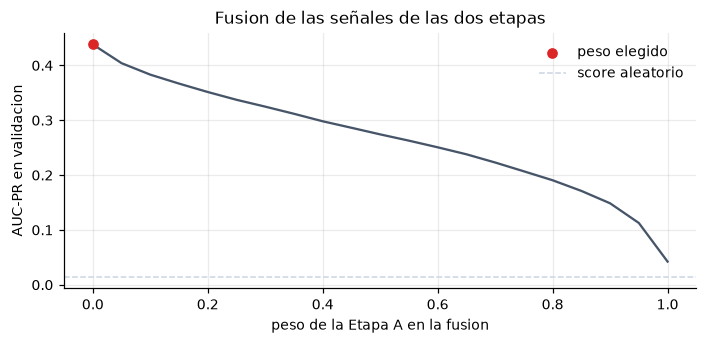

In [54]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(ws, ap_w, color="#475569")
ax.scatter([FUSION_W], [ap_w.max()], color="#dc2626", zorder=5, label="peso elegido")
ax.axhline(y[val_idx].mean(), ls="--", lw=1, color="#cbd5e1", label="score aleatorio")
ax.set_xlabel("peso de la Etapa A en la fusion"); ax.set_ylabel("AUC-PR en validacion")
ax.set_title("Fusion de las señales de las dos etapas")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 25. Umbral operativo, evaluación en prueba y trazabilidad

El umbral se elige maximizando F1 sobre la curva precisión-recall de validación, el mismo criterio de la Decisión 16, y se congela para prueba. La tabla final compara los cuatro sistemas sobre el mismo conjunto de prueba: la Etapa A sola, la Etapa B entrenada desde cero, la Etapa B con transferencia y la fusión de ambas.

Como en la Sección 15, se reportan puntos de operación alternativos: un equipo que puede revisar más alertas al día puede bajar el umbral y ganar recall, y la tabla deja explícito cuánto cuesta cada punto de recall en volumen de revisión manual.

La trazabilidad cierra el ciclo que pide el enunciado: para una alerta concreta, `explain_window_b` lista las transacciones con mayor peso de atención junto a su error de reconstrucción de la Etapa A y a la etiqueta real por transacción, que es la evidencia que un analista revisaría.

In [55]:
THRESHOLD_B = f1_threshold(FINAL)
scratch_seed = int(abl_df[abl_df["modelo"] == "scratch"].loc[
    abl_df[abl_df["modelo"] == "scratch"]["AUC-PR val"].idxmax(), "semilla"])

final_rows = [
    summarize(SCORE, "Etapa A sola (reconstruccion)"),
    summarize(PROBS[("scratch", scratch_seed)], "Etapa B desde cero (linea base)"),
    summarize(PROB, f"Etapa B con transfer ({LABELS[BEST_VARIANT]})"),
    summarize(FINAL, f"sistema de dos etapas (fusion w={FUSION_W:.2f})"),
]
print("TABLA FINAL EN PRUEBA (umbral de F1 maximo fijado en validacion para cada score)")
print(pd.DataFrame(final_rows).round(4).to_string(index=False))

print(f"\nDESEMPENO DEL SISTEMA COMPLETO  (umbral={THRESHOLD_B:.4f})")
res_val_b = evaluate(val_idx, "validacion", FINAL, THRESHOLD_B)
res_test_b = evaluate(test_idx, "prueba", FINAL, THRESHOLD_B)

pr_b, rc_b, th_b = precision_recall_curve(y[val_idx], FINAL[val_idx])
op_rows_b = []
for tr_ in [0.5, 0.7, 0.8, 0.9, 0.95]:
    ix = np.where(rc_b[:-1] >= tr_)[0]
    if len(ix) == 0:
        continue
    i = ix[np.argmax(pr_b[:-1][ix])]
    op_rows_b.append({"recall_objetivo": tr_, "umbral": th_b[i], "precision": pr_b[i],
                       "recall_real": rc_b[i], "tasa_alerta_%": 100*(FINAL[val_idx] >= th_b[i]).mean()})
print("\nPUNTOS DE OPERACION ALTERNATIVOS (validacion)")
print(pd.DataFrame(op_rows_b).round(4).to_string(index=False))

TABLA FINAL EN PRUEBA (umbral de F1 maximo fijado en validacion para cada score)
                                      modelo  AUC-PR val  AUC-PR prueba  AUC-ROC prueba  precision  recall     F1  alerta_%
               Etapa A sola (reconstruccion)      0.0424         0.0436          0.6905     0.0931  0.1467 0.1139    2.3709
             Etapa B desde cero (linea base)      0.4364         0.4209          0.9283     0.9457  0.2711 0.4214    0.4314
Etapa B con transfer (fine-tuning (Etapa A))      0.4383         0.4155          0.9263     0.8939  0.2622 0.4055    0.4414
       sistema de dos etapas (fusion w=0.00)      0.4383         0.4155          0.9263     0.8939  0.2622 0.4055    0.4414

DESEMPENO DEL SISTEMA COMPLETO  (umbral=0.8946)
validacion       n= 29,905  precision=0.945  recall=0.304  F1=0.460  alertas=145 (0.48%)
prueba           n= 29,904  precision=0.894  recall=0.262  F1=0.405  alertas=132 (0.44%)

PUNTOS DE OPERACION ALTERNATIVOS (validacion)
 recall_objetivo  umbral 

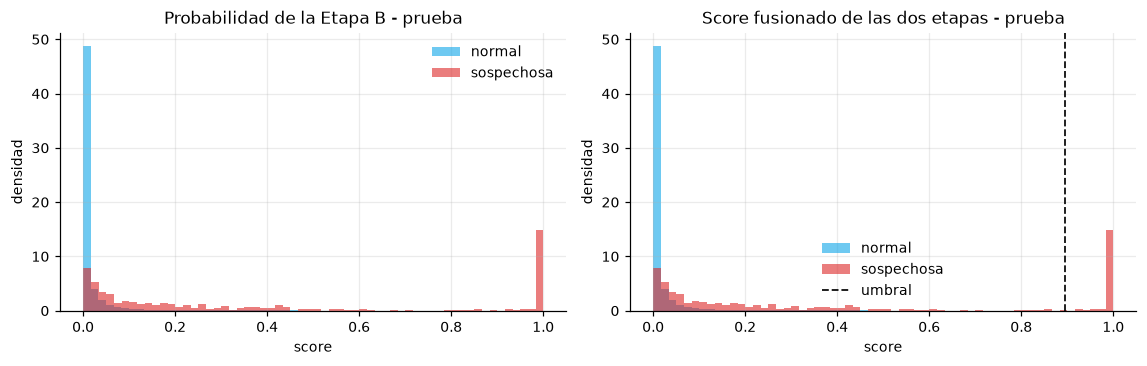

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.4))
for j, (arr, titulo) in enumerate([(PROB, "Probabilidad de la Etapa B"),
                                    (FINAL, "Score fusionado de las dos etapas")]):
    s_te = arr[test_idx]
    ax[j].hist(s_te[y[test_idx] == 0], bins=60, alpha=0.6, label="normal", color="#0ea5e9", density=True)
    ax[j].hist(s_te[y[test_idx] == 1], bins=60, alpha=0.6, label="sospechosa", color="#dc2626", density=True)
    ax[j].set_xlabel("score"); ax[j].set_ylabel("densidad")
    ax[j].set_title(f"{titulo} - prueba")
ax[1].axvline(THRESHOLD_B, color="#111", ls="--", lw=1.2, label="umbral")
ax[0].legend(frameon=False); ax[1].legend(frameon=False)
plt.tight_layout(); plt.show()

In [57]:
def explain_window_b(w, k=5):
    """Las k transacciones con mayor peso de atencion de una ventana, con el error de
    reconstruccion de la Etapa A al lado: la evidencia que acompaña a la alerta."""
    _, attn = score_windows(CLF, np.array([w]), with_attention=True)
    a = attn[w]
    i0, i1 = int(win_start[w]), int(win_end[w])
    seq = X[i0:i1]
    with torch.no_grad():
        xb = torch.from_numpy(seq).unsqueeze(0).to(DEVICE)
        mask1 = torch.ones(1, seq.shape[0], dtype=torch.bool).to(DEVICE)
        recon, _ = model(xb, torch.tensor([seq.shape[0]]))
        err = masked_timestep_error(recon, xb, mask1, SCORE_COLS).cpu().numpy()[0]
    order = np.argsort(a)[::-1][:k]
    return pd.DataFrame({"posicion_en_ventana": order, "atencion": a[order],
                          "error_reconstruccion": err[order],
                          "transaccion_marcada": is_illicit_tx[i0:i1][order]})


alerted = test_idx[(FINAL[test_idx] >= THRESHOLD_B) & (y[test_idx] == 1)]
if len(alerted) > 0:
    caso = int(alerted[np.argmax(FINAL[alerted])])
    print(f"ventana {caso}  remitente {meta['sender_names'][sender_code[caso]]}  "
          f"({win_len[caso]} transacciones)")
    print(f"  score de anomalia (Etapa A) : {SCORE[caso]:.4f}")
    print(f"  probabilidad de lavado (B)  : {PROB[caso]:.4f}")
    print(f"  score fusionado             : {FINAL[caso]:.4f}  (umbral {THRESHOLD_B:.4f})")
    print(f"  transacciones marcadas en la ventana: {int(is_illicit_tx[win_start[caso]:win_end[caso]].sum())}")
    print()
    print(explain_window_b(caso).to_string(index=False))
else:
    print("ningun positivo de prueba supero el umbral en esta corrida")

ventana 172677  remitente 8019E69B0  (52 transacciones)
  score de anomalia (Etapa A) : 0.1330
  probabilidad de lavado (B)  : 1.0000
  score fusionado             : 1.0000  (umbral 0.8946)
  transacciones marcadas en la ventana: 1

 posicion_en_ventana  atencion  error_reconstruccion  transaccion_marcada
                  51  0.994338              0.438114                    1
                  50  0.003666              0.326989                    0
                   1  0.000585              0.041332                    0
                   2  0.000418              0.151955                    0
                  48  0.000073              0.170857                    0


## 26. Exportación de artefactos de la Etapa B

Se guardan los pesos del clasificador, los scores de las dos etapas y el score fusionado de todas las secuencias, los pesos de atención de cada transacción del conjunto de prueba y los metadatos de la ablación. Con eso, el Componente 3 puede hacer el análisis de casos y el Componente 4 puede dibujar el mapa de calor sobre la secuencia sin volver a ejecutar el entrenamiento.

In [58]:
attn_test = score_windows(CLF, test_idx, with_attention=True)[1]
lens_test = np.array([len(attn_test[int(w)]) for w in test_idx])
attn_end = np.cumsum(lens_test)
np.savez(
    OUT_DIR / "stage_b_attention.npz",
    window=test_idx,
    attention=np.concatenate([attn_test[int(w)] for w in test_idx]).astype(np.float32),
    attn_start=attn_end - lens_test, attn_end=attn_end,
)

np.savez(
    OUT_DIR / "stage_b_scores.npz",
    prob=PROB, score_fused=FINAL, score_a=SCORE,
    y=y, split=split, sender_code=sender_code,
    threshold=THRESHOLD_B, fusion_w=FUSION_W,
)

torch.save({"state_dict": CLF.state_dict(), "cfg": CFG3, "cfg_a": CFG2, "variant": BEST_VARIANT,
            "loss": LOSS, "seed": BEST_SEED, "n_features": N_FEATS},
           OUT_DIR / "stage_b_model.pt")

stage_b_meta = dict(
    variant=BEST_VARIANT,
    loss=LOSS,
    seed=BEST_SEED,
    threshold=THRESHOLD_B,
    fusion_w=FUSION_W,
    cfg=CFG3,
    enc_lr=ENC_LR,
    lr_table=lr_df.to_dict("records"),
    loss_table=loss_df.to_dict("records"),
    ablation=abl_df.to_dict("records"),
    label_table=lab_df.to_dict("records"),
    final_table=final_rows,
    history=RUNS[(BEST_VARIANT, LOSS, BEST_SEED, ENC_LR, 1.0)][1],
    val_metrics=res_val_b,
    test_metrics=res_test_b,
)
with open(OUT_DIR / "stage_b_meta.json", "w") as f:
    json.dump(stage_b_meta, f, indent=2, default=float)

for p in sorted(OUT_DIR.glob("stage_b_*")):
    print(f"  {p.name:<26} {p.stat().st_size/1e6:>8,.2f} MB")

alertas_b = res_test_b["tp"] + res_test_b["fp"]
print("\nRESUMEN ETAPA B (para el reporte)")
print(f"  estrategia de transferencia        : {LABELS[BEST_VARIANT]}")
print(f"  perdida                            : {LOSS}")
print(f"  peso de la Etapa A en la fusion    : {FUSION_W:.2f}")
print(f"  AUC-PR en prueba, desde cero       : {final_rows[1]['AUC-PR prueba']:.4f}")
print(f"  AUC-PR en prueba, con transfer     : {final_rows[2]['AUC-PR prueba']:.4f}")
print(f"  AUC-PR en prueba, sistema completo : {final_rows[3]['AUC-PR prueba']:.4f}")
print(f"  precision / recall / F1 (prueba)   : {res_test_b['precision']:.3f} / "
      f"{res_test_b['recall']:.3f} / {res_test_b['f1']:.3f}")
print(f"  alertas en prueba                  : {alertas_b:,} de {res_test_b['n']:,} "
      f"({100*alertas_b/res_test_b['n']:.2f}%)")

  stage_b_attention.npz          2.68 MB
  stage_b_meta.json              0.01 MB
  stage_b_model.pt               0.12 MB
  stage_b_scores.npz             4.99 MB

RESUMEN ETAPA B (para el reporte)
  estrategia de transferencia        : fine-tuning (Etapa A)
  perdida                            : bce
  peso de la Etapa A en la fusion    : 0.00
  AUC-PR en prueba, desde cero       : 0.4209
  AUC-PR en prueba, con transfer     : 0.4155
  AUC-PR en prueba, sistema completo : 0.4155
  precision / recall / F1 (prueba)   : 0.894 / 0.262 / 0.405
  alertas en prueba                  : 132 de 29,904 (0.44%)


## Resumen de decisiones: Etapa B

|  #   | Decisión                                                          | Justificación                                                                                                                    |
| :--: | ------------------------------------------------------------------ | --------------------------------------------------------------------------------------------------------------------------------- |
| **17** | Atención aditiva enmascarada sobre las salidas del *encoder*     | Pondera la secuencia completa en vez de resumirla en el último estado, y su peso por transacción es la evidencia que exigen el Componente 3 y el MVP |
| **18** | El *encoder* transferido se ajusta a la misma tasa que la cabeza | Barrido en validación: 0.386 con 0.1x, 0.404 con 0.3x, 0.412 con 1.0x; la receta de tasa discriminativa protege una representación que aquí es débil |
| **19** | Entropía cruzada binaria simple, sin ponderar                     | 0.4383 contra 0.4121 con `pos_weight=10` y 0.4337 con focal; el submuestreo 1:10 del Componente 1 ya corrigió el grueso del desbalance |
| **20** | AUC-PR como métrica primaria y selección de modelo solo con validación | Con 1.5 % de positivos el AUC-ROC no distingue un sistema útil de uno inservible; el piso del AUC-PR es la prevalencia misma |
| **21** | Fusión convexa de los dos scores en escala de rangos              | El peso óptimo en validación cae en 0.00: la Etapa A no aporta señal adicional al *ranking* y el resultado se reporta como tal |
| **22** | Umbral de F1 máximo en validación, congelado para prueba          | Mismo criterio de la Decisión 16; deja 0.44 % de tasa de alerta con precisión de 0.894 en prueba |

**Limitaciones de la Etapa B.**

1. **El recall es de 0.262 en el punto de operación elegido.** Tres de cada cuatro ventanas sospechosas no generan alerta. La tabla de puntos alternativos muestra el intercambio: llegar a un recall de 0.50 exige revisar el 3.3 % de las secuencias y baja la precisión a 0.23. Cuál de esos puntos es el correcto no es una decisión técnica sino de política de cumplimiento y de presupuesto de analistas.
2. **La ablación no demostró valor del preentrenamiento.** El experimento obligatorio se corrió y su resultado es un empate, no una mejora. Un reporte que afirmara lo contrario no se sostendría con estos números.
3. **El modelo podría estar apoyándose en un artefacto del dataset.** La Sección 2.2 documentó que el 86.6 % de las transacciones ilícitas del IBM AML son de formato ACH. Con una precisión de 0.894 conviene sospechar: parte de esa separabilidad puede venir de una correlación del generador sintético y no de comportamiento de lavado. Verificarlo requiere un análisis de atribución por *feature* y, sobre todo, datos reales de un corredor de remesas.
4. **Las etiquetas son de ventana, no de remitente ni de red.** El sistema responde "esta ventana contiene actividad marcada", que es más angosto que la pregunta regulatoria real, que es sobre la persona y su red de contrapartes.
5. **No se evaluó la calibración de las probabilidades.** El umbral se eligió sobre el orden de los scores, no sobre su valor absoluto; para un reporte de operación sospechosa que cite una probabilidad haría falta calibrar y validar esa cifra.

# Componente 4: MVP funcional

La interfaz se entrega como un **único archivo HTML autocontenido** (`mvp.html`): no requiere servidor, instalación ni conexión a internet, y el evaluador solo tiene que abrirlo en cualquier navegador. Todos los datos que necesita quedan incrustados en el propio archivo al ejecutar la celda siguiente, de modo que no puede fallar por una ruta rota o un artefacto ausente durante la presentación.

**Qué permite la interfaz**, según lo pedido en el enunciado:

| Requisito | Dónde se resuelve |
| --- | --- |
| Seleccionar un remitente del conjunto de prueba | Panel izquierdo, con búsqueda por número de cuenta y filtros por alerta / caso ilícito |
| Visualizar su secuencia de transacciones | Tabla con fecha, monto, moneda, canal, destino, intervalo y peso de atención |
| Ver el score de la Etapa A y la probabilidad de la Etapa B | Bloque «Señales de las dos etapas», cada una con su umbral marcado sobre la barra |
| Mapa de calor sobre la secuencia | Dos franjas alineadas con la secuencia: atención de la Etapa B y error de reconstrucción de la Etapa A |
| Explicación automática en lenguaje natural | Bloque «Explicación de la alerta», generado en el navegador a partir de las señales reales de la ventana |

**Sobre el veredicto.** La Sección 24 estableció que el peso de la Etapa A en la fusión es 0, así que el sistema operativo es la Etapa B: solo ella genera una *Alerta*. Cuando la Etapa A marca una secuencia como atípica pero la Etapa B no la considera lavado, la interfaz muestra el estado intermedio *Solo anomalía* y lo explica como una revisión de baja prioridad, en vez de presentar dos señales contradictorias bajo la misma etiqueta.

**Sobre la explicación.** Se genera con reglas deterministas sobre los datos de la ventana (peso de atención, error de reconstrucción, fraccionamiento bajo el umbral de reporte, intervalos, destinos nuevos, saltos de divisa) y no llama a ningún servicio externo. Esto es deliberado: una explicación generada por un modelo remoto añadiría una dependencia de red que puede fallar justo durante la presentación, y el enunciado exige que el MVP corra sin errores.


## 27. Construcción del archivo del MVP

**La celda es autosuficiente:** solo requiere la celda de dependencias y los artefactos en `OUT_DIR`. Carga el modelo de la Etapa A, los scores y los pesos de atención desde disco, así que puede ejecutarse en una sesión nueva sin repetir el entrenamiento. La matriz de *features* (~440 MB) se mapea desde el archivo en vez de cargarse en memoria, y de ella solo se leen las ventanas elegidas.

Recalcula el error de reconstrucción **por transacción** de las ventanas seleccionadas (el artefacto de la Sección 18 solo guarda el error ya ordenado, que pierde la posición dentro de la secuencia), lo combina con los pesos de atención de la Sección 26 y los metadatos legibles de `test_tx.parquet`, y escribe el HTML con todo incrustado.

No se exporta el conjunto de prueba completo: se incluyen **todas** las ventanas con alerta de cualquiera de las dos etapas y **todos** los casos etiquetados como lavado, más una muestra aleatoria de ventanas normales hasta `MVP_MAX_SENDERS`. Así el evaluador encuentra siempre casos interesantes al abrir la interfaz, sin que el archivo crezca a cientos de megabytes.


In [ ]:
MVP_TEMPLATE = r"""<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1, viewport-fit=cover">
<title>MVP Detección de lavado en remesas</title>
<style>
:root{
  box-sizing:border-box;
  padding-top:env(safe-area-inset-top,0px);
  padding-bottom:env(safe-area-inset-bottom,0px);
  --bg:#ffffff;
  --panel:#ffffff;
  --sunken:#f6f6f5;
  --ink:#16161a;
  --ink-2:#55555c;
  --ink-3:#85858e;
  --line:#e0e0dd;
  --line-2:#cfcfca;
  --alert:#9e2a2a;
  --alert-bg:#f7ecec;
  --ok:#2f5d3f;
  --heat:158,42,42;
  --mono:ui-monospace,"SF Mono",Menlo,Consolas,monospace;
}
@media (prefers-color-scheme:dark){
  :root:not([data-theme="light"]){
    --bg:#131315; --panel:#191919; --sunken:#1f1f21;
    --ink:#ededea; --ink-2:#a9a9a4; --ink-3:#77777a;
    --line:#2b2b2e; --line-2:#3a3a3e;
    --alert:#e08585; --alert-bg:#2a1a1a; --ok:#8fbf9f;
    --heat:224,133,133;
  }
}
:root[data-theme="dark"]{
  --bg:#131315; --panel:#191919; --sunken:#1f1f21;
  --ink:#ededea; --ink-2:#a9a9a4; --ink-3:#77777a;
  --line:#2b2b2e; --line-2:#3a3a3e;
  --alert:#e08585; --alert-bg:#2a1a1a; --ok:#8fbf9f;
  --heat:224,133,133;
}
*,*::before,*::after{box-sizing:inherit}
html{height:100%;scroll-padding-top:env(safe-area-inset-top,0px)}
body{
  margin:0;height:100%;background:var(--bg);color:var(--ink);
  font-family:-apple-system,BlinkMacSystemFont,"Segoe UI",Roboto,Helvetica,Arial,sans-serif;
  font-size:14px;line-height:1.5;-webkit-font-smoothing:antialiased;
}
.wrap{max-width:1180px;margin:0 auto;padding:22px 18px 60px}

header.top{border-bottom:1px solid var(--line);padding-bottom:14px;margin-bottom:20px}
h1{font-size:16px;font-weight:650;margin:0 0 3px;letter-spacing:-.01em}
.sub{font-size:12.5px;color:var(--ink-3);margin:0}

.layout{display:grid;grid-template-columns:266px minmax(0,1fr);gap:22px;align-items:start}
/* min-width:0 impide que el ancho minimo del contenido (tabla, mapa de calor) estire la columna */
.layout>*{min-width:0}
@media(max-width:820px){.layout{grid-template-columns:minmax(0,1fr)}}

/* ---- selector ---- */
.pick{border:1px solid var(--line);background:var(--panel)}
.pick-hd{padding:10px 12px;border-bottom:1px solid var(--line)}
.lbl{font-size:10.5px;text-transform:uppercase;letter-spacing:.08em;color:var(--ink-3);font-weight:600}
input[type=search],select{
  width:100%;margin-top:7px;padding:7px 8px;font:inherit;font-size:13px;
  color:var(--ink);background:var(--sunken);border:1px solid var(--line-2);border-radius:0;
  -webkit-appearance:none;appearance:none;
}
input[type=search]:focus,select:focus{outline:2px solid var(--ink-3);outline-offset:-1px}
.filters{display:flex;gap:6px;margin-top:8px;flex-wrap:wrap}
.chip{
  font-size:11.5px;padding:3px 8px;border:1px solid var(--line-2);background:transparent;
  color:var(--ink-2);cursor:pointer;font-family:inherit;
}
.chip[aria-pressed=true]{background:var(--ink);color:var(--bg);border-color:var(--ink)}
.list{max-height:460px;overflow-y:auto}
.item{
  display:flex;justify-content:space-between;align-items:center;gap:8px;
  width:100%;text-align:left;padding:8px 12px;border:0;border-bottom:1px solid var(--line);
  background:transparent;color:var(--ink);cursor:pointer;font:inherit;
}
.item:hover{background:var(--sunken)}
.item[aria-current=true]{background:var(--sunken);box-shadow:inset 3px 0 0 var(--ink)}
.item .id{font-family:var(--mono);font-size:12px;overflow:hidden;text-overflow:ellipsis}
.item .n{font-size:11px;color:var(--ink-3)}
.dot{width:6px;height:6px;flex:0 0 6px;background:var(--alert)}
.empty{padding:16px 12px;color:var(--ink-3);font-size:12.5px}

/* ---- detail ---- */
.card{border:1px solid var(--line);background:var(--panel);padding:16px;margin-bottom:16px}
.card h2{
  font-size:10.5px;text-transform:uppercase;letter-spacing:.08em;color:var(--ink-3);
  font-weight:600;margin:0 0 12px;
}
.idrow{display:flex;justify-content:space-between;align-items:flex-start;gap:14px;flex-wrap:wrap}
.acct{font-family:var(--mono);font-size:17px;font-weight:600;letter-spacing:-.01em}
.meta{font-size:12px;color:var(--ink-3);margin-top:2px}
.verdict{
  font-size:11.5px;font-weight:650;padding:5px 10px;border:1px solid var(--line-2);
  text-transform:uppercase;letter-spacing:.06em;white-space:nowrap;
}
.verdict.on{background:var(--alert-bg);color:var(--alert);border-color:var(--alert)}
.verdict.mid{color:var(--ink);border-color:var(--ink-3)}

.stages{display:grid;grid-template-columns:1fr 1fr;gap:14px}
@media(max-width:620px){.stages{grid-template-columns:1fr}}
.stage{border:1px solid var(--line);padding:14px}
.stage .nm{font-size:12px;color:var(--ink-2);font-weight:600}
.stage .dsc{font-size:11.5px;color:var(--ink-3);margin-top:1px}
.val{font-size:26px;font-weight:600;font-variant-numeric:tabular-nums;margin:10px 0 2px;letter-spacing:-.02em}
.val.on{color:var(--alert)}
.thr{font-size:11.5px;color:var(--ink-3);font-variant-numeric:tabular-nums}
.bar{height:5px;background:var(--sunken);margin-top:10px;position:relative;overflow:hidden}
.bar i{position:absolute;inset:0 auto 0 0;background:var(--ink-3)}
.bar i.on{background:var(--alert)}
.bar u{position:absolute;top:-2px;bottom:-2px;width:1px;background:var(--ink)}

/* ---- heatmap ---- */
.hm-row{margin-bottom:12px}
.hm-lb{display:flex;justify-content:space-between;font-size:11.5px;color:var(--ink-2);margin-bottom:5px}
.hm-scroll{overflow-x:auto;overflow-y:hidden;min-width:0}
.hm-inner{min-width:100%}
.hm{display:flex;gap:2px;min-height:26px}
.cell{flex:1 1 0;min-width:5px;height:26px;position:relative;border:1px solid transparent;cursor:default}
.cell.tp{border-color:var(--ink)}
.scaleline{display:flex;align-items:center;gap:8px;font-size:11px;color:var(--ink-3);margin-top:4px}
.scale{display:flex;gap:2px}
.scale span{width:15px;height:9px}
.axis{display:flex;justify-content:space-between;font-size:10.5px;color:var(--ink-3);margin-top:4px;font-variant-numeric:tabular-nums}

/* ---- explanation ---- */
.exp p{margin:0 0 10px;font-size:14px;line-height:1.62}
.exp p:last-child{margin-bottom:0}
.exp b{font-weight:650}

/* ---- table ---- */
.scroll{overflow-x:auto;min-width:0}
table{width:100%;border-collapse:collapse;font-size:12.5px}
th{
  text-align:left;font-size:10.5px;text-transform:uppercase;letter-spacing:.06em;
  color:var(--ink-3);font-weight:600;padding:0 9px 7px;border-bottom:1px solid var(--line-2);white-space:nowrap;
}
td{padding:7px 9px;border-bottom:1px solid var(--line);white-space:nowrap;vertical-align:middle}
tr.hi td{background:var(--sunken)}
td.num{text-align:right;font-variant-numeric:tabular-nums;font-family:var(--mono);font-size:12px}
td.mono{font-family:var(--mono);font-size:12px;color:var(--ink-2)}
.flag{display:inline-block;width:6px;height:6px;background:var(--alert)}
.mini{display:flex;align-items:center;gap:6px;justify-content:flex-end}
.mini b{display:block;height:7px;min-width:1px}
.mini span{font-family:var(--mono);font-size:11px;color:var(--ink-3);width:38px;text-align:right}
footer{margin-top:26px;padding-top:12px;border-top:1px solid var(--line);font-size:11.5px;color:var(--ink-3)}
</style>
</head>
<body>
<div class="wrap">

<header class="top">
  <h1>Detección de lavado en remesas: sistema de dos etapas</h1>
  <p class="sub" id="hdrSub">Conjunto de prueba · IBM AML HI-Small</p>
</header>

<div class="layout">

  <aside class="pick">
    <div class="pick-hd">
      <span class="lbl">Remitente</span>
      <input type="search" id="q" placeholder="Buscar por cuenta…" autocomplete="off" spellcheck="false">
      <div class="filters">
        <button class="chip" id="fAll"   aria-pressed="true">Todos</button>
        <button class="chip" id="fAlert" aria-pressed="false">Con alerta</button>
        <button class="chip" id="fTrue"  aria-pressed="false">Ilícitos</button>
      </div>
    </div>
    <div class="list" id="list"></div>
  </aside>

  <main id="detail"></main>
</div>

<footer id="foot"></footer>
</div>

<script id="mvp-data" type="application/json">__MVP_DATA__</script>
<script>
(function(){
"use strict";
var DATA;
try{ DATA = JSON.parse(document.getElementById("mvp-data").textContent); }
catch(e){
  document.getElementById("detail").innerHTML =
    '<div class="card"><h2>Error</h2><p>No se pudieron leer los datos incrustados.</p></div>';
  return;
}
var S = DATA.senders || [], M = DATA.meta || {};
var thrA = M.threshold_a, thrB = M.threshold_b;

/* ---------- helpers ---------- */
function esc(s){ return String(s).replace(/[&<>"]/g,function(c){
  return {"&":"&amp;","<":"&lt;",">":"&gt;",'"':"&quot;"}[c]; }); }
function money(v){
  return v.toLocaleString("es-GT",{minimumFractionDigits:2,maximumFractionDigits:2}); }
function fdate(iso){
  var d = new Date(iso);
  if(isNaN(d)) return String(iso);
  var D = String(d.getUTCDate()).padStart(2,"0"),
      Mo= String(d.getUTCMonth()+1).padStart(2,"0"),
      h = String(d.getUTCHours()).padStart(2,"0"),
      m = String(d.getUTCMinutes()).padStart(2,"0");
  return D+"/"+Mo+" "+h+":"+m;
}
function gap(h){
  if(h===null||h===undefined) return "—";
  if(h < 1)  return Math.round(h*60)+" min";
  if(h < 48) return h.toFixed(1)+" h";
  return (h/24).toFixed(1)+" d";
}
/* 6 discrete solid steps, no gradient */
function heat(t){
  if(!(t>0)) return "transparent";
  var step = Math.min(5, Math.floor(t*6));
  var a = [0.10,0.24,0.40,0.58,0.78,1][step];
  return "rgba(var(--heat),"+a+")";
}
function norm(arr){
  var mx = Math.max.apply(null, arr.concat([0]));
  return mx>0 ? arr.map(function(v){return v/mx;}) : arr.map(function(){return 0;});
}
function ordinal(i){
  return ["primera","segunda","tercera","cuarta","quinta"][i] || (i+1)+"ª";
}

/* ---------- natural-language explanation ----------
   Builds the paragraph from the actual signals of the selected window:
   verdict of each stage, the transactions carrying most attention /
   reconstruction error, and the behavioural traits those transactions show. */
function explain(s){
  var tx = s.tx, n = tx.length;
  var aOn = s.score_a >= thrA, bOn = s.prob >= thrB;
  var att = norm(tx.map(function(t){return t.attn;}));
  var err = norm(tx.map(function(t){return t.err;}));
  var mix = att.map(function(v,i){ return v + err[i]; });
  var order = mix.map(function(v,i){return [v,i];})
                 .sort(function(x,y){return y[0]-x[0];})
                 .map(function(p){return p[1];});
  var top = order.slice(0, Math.min(3,n));

  var out = [];

  /* 1 — verdict */
  var v;
  if(bOn && aOn){
    v = "El sistema <b>marca este remitente</b>. Las dos etapas coinciden: la probabilidad de "+
        "lavado de la Etapa B es de <b>"+(s.prob*100).toFixed(1)+"&nbsp;%</b> (umbral "+
        (thrB*100).toFixed(1)+"&nbsp;%) y el score de anomalía de la Etapa A, de <b>"+
        s.score_a.toFixed(2)+"</b>, también supera su umbral de "+thrA.toFixed(2)+".";
  } else if(bOn){
    v = "El sistema <b>marca este remitente</b> por la Etapa B, que le asigna una probabilidad de "+
        "lavado de <b>"+(s.prob*100).toFixed(1)+"&nbsp;%</b> frente a un umbral de "+
        (thrB*100).toFixed(1)+"&nbsp;%. La Etapa A no lo considera anómalo (score "+
        s.score_a.toFixed(2)+", por debajo de "+thrA.toFixed(2)+"): su patrón de gasto se parece "+
        "al de un remitente corriente y lo que lo delata es el parecido con casos ya confirmados.";
  } else if(aOn){
    v = "El sistema <b>no marca este remitente</b>, pero la Etapa A lo señala como atípico "+
        "(score <b>"+s.score_a.toFixed(2)+"</b> sobre un umbral de "+thrA.toFixed(2)+"). "+
        "La Etapa B le asigna solo "+(s.prob*100).toFixed(1)+"&nbsp;% de probabilidad de lavado: "+
        "es un comportamiento raro que no se parece a los casos confirmados. Queda como "+
        "revisión de baja prioridad.";
  } else {
    v = "El sistema <b>no marca este remitente</b>. La Etapa B le asigna "+
        (s.prob*100).toFixed(1)+"&nbsp;% de probabilidad de lavado (umbral "+
        (thrB*100).toFixed(1)+"&nbsp;%) y su score de anomalía de "+s.score_a.toFixed(2)+
        " queda por debajo del umbral de "+thrA.toFixed(2)+".";
  }
  out.push(v);

  /* 2 — which transactions carry the signal */
  var share = top.reduce(function(a,i){return a+tx[i].attn;},0);
  var t0 = tx[top[0]];
  var frag = top.filter(function(i){
    var a = tx[i].amt; return a>=8500 && a<10000; });
  var quick = top.filter(function(i){
    return tx[i].gap_h !== null && tx[i].gap_h < 2; });
  var neu = top.filter(function(i){ return tx[i].new_dest; });

  var p2 = "Dentro de las <b>"+n+" transacciones</b> de la ventana, la atención del modelo se "+
    "concentra en "+(top.length===1?"una sola operación":"las "+top.length+" operaciones señaladas en el mapa de calor")+
    ", que acumulan el <b>"+(share*100).toFixed(0)+"&nbsp;%</b> del peso total. La más determinante es la "+
    ordinal(top[0])+" de la secuencia ("+fdate(t0.ts)+"): <b>"+money(t0.amt)+" "+esc(t0.cur)+
    "</b> por "+esc(t0.fmt)+" hacia "+esc(t0.to)+
    (t0.new_dest ? ", un destino que no aparecía antes en el historial del remitente" : "")+".";
  out.push(p2);

  /* 3 — behavioural traits behind the flag */
  var traits = [];
  if(frag.length){
    traits.push(frag.length===1
      ? "una de ellas queda justo por debajo del umbral de reporte de 10,000, un fraccionamiento característico del <i>structuring</i>"
      : frag.length+" de ellas quedan justo por debajo del umbral de reporte de 10,000, un fraccionamiento característico del <i>structuring</i>");
  }
  if(quick.length){
    traits.push(quick.length===1
      ? "una de ellas llega a menos de dos horas de la operación anterior, un ritmo muy por encima del habitual del remitente"
      : quick.length+" de ellas llegan a menos de dos horas de la operación anterior, un ritmo muy por encima del habitual del remitente");
  }
  if(neu.length){
    traits.push((neu.length===1?"una de ellas va a un destino nuevo, ":neu.length+" de ellas van a destinos nuevos, ")+
      "en una cuenta donde el "+(s.pct_new_dest*100).toFixed(0)+"&nbsp;% de los envíos históricos "+
      "fue a un destinatario ya conocido");
  }
  if(t0.amt > s.amt_mean*3 && s.amt_mean>0){
    traits.push("el monto de la operación principal es "+(t0.amt/s.amt_mean).toFixed(1)+
      " veces el promedio histórico de este remitente ("+money(s.amt_mean)+")");
  }
  if(s.n_cur > 1){
    traits.push("la ventana mezcla "+s.n_cur+" monedas distintas, y los saltos de divisa "+
      "son una forma corriente de romper la trazabilidad");
  }
  if(traits.length){
    var body = traits.length===1 ? traits[0]
      : traits.slice(0,-1).join("; ")+"; y "+traits[traits.length-1];
    out.push("Los rasgos que sostienen la alerta: "+body+".");
  } else {
    out.push("Ninguna de las operaciones señaladas presenta por sí sola un rasgo llamativo "+
      "(no hay fraccionamiento bajo el umbral de reporte, ni ráfagas, ni destinos nuevos). "+
      "La señal proviene de la combinación del conjunto, no de una transacción aislada, "+
      "y por eso conviene revisar la secuencia completa antes de concluir.");
  }

  /* 4 — honest caveat, matching what the components measured */
  if(bOn){
    out.push("<b>Cómo leer esto.</b> En el conjunto de prueba, con este umbral, el "+
      (M.precision_b*100).toFixed(0)+"&nbsp;% de las alertas de la Etapa B resultaron ser casos "+
      "reales, pero el sistema solo recupera el "+(M.recall_b*100).toFixed(0)+"&nbsp;% del lavado "+
      "presente: una alerta es un punto de partida para el analista, no una conclusión, y la "+
      "ausencia de alerta no es un certificado de limpieza.");
  }
  return out;
}

/* ---------- rendering ---------- */
function render(s){
  var att = norm(s.tx.map(function(t){return t.attn;}));
  var err = norm(s.tx.map(function(t){return t.err;}));
  var aOn = s.score_a >= thrA, bOn = s.prob >= thrB;
  /* El veredicto operativo lo dicta la Etapa B: es el sistema final (peso de fusión 0).
     La Etapa A sola no genera alerta, solo una marca de revisión de baja prioridad. */
  var vLabel = bOn ? "Alerta" : (aOn ? "Solo anomalía" : "Sin alerta");
  var h = [];

  h.push('<div class="card"><div class="idrow"><div>',
    '<div class="acct">',esc(s.acct),'</div>',
    '<div class="meta">Ventana ',s.window,' · ',s.tx.length,' transacciones · ',
      fdate(s.tx[0].ts),' a ',fdate(s.tx[s.tx.length-1].ts),
      ' · etiqueta real: ',(s.y? 'lavado confirmado':'sin marcar'),'</div></div>',
    '<span class="verdict',(bOn?' on':(aOn?' mid':'')),'">',vLabel,'</span>',
    '</div></div>');

  /* two stages */
  function stage(nm,dsc,txt,frac,mark,on,thrTxt){
    return '<div class="stage"><div class="nm">'+nm+'</div><div class="dsc">'+dsc+'</div>'+
      '<div class="val'+(on?' on':'')+'">'+txt+'</div><div class="thr">'+thrTxt+'</div>'+
      '<div class="bar"><i class="'+(on?'on':'')+'" style="width:'+
      (Math.max(0,Math.min(1,frac))*100).toFixed(1)+'%"></i>'+
      '<u style="left:'+(Math.max(0,Math.min(1,mark))*100).toFixed(1)+'%"></u></div></div>';
  }
  var lo = M.score_a_min, hi = M.score_a_max, rng = (hi-lo)||1;
  h.push('<div class="card"><h2>Señales de las dos etapas</h2><div class="stages">',
    stage("Etapa A: anomalía","Error de reconstrucción, sin etiquetas",
          s.score_a.toFixed(2), (s.score_a-lo)/rng, (thrA-lo)/rng, aOn,
          "umbral "+thrA.toFixed(2)),
    stage("Etapa B: clasificación","Probabilidad de lavado, supervisada",
          (s.prob*100).toFixed(1)+"&nbsp;%", s.prob, thrB, bOn,
          "umbral "+(thrB*100).toFixed(1)+"&nbsp;%"),
    '</div></div>');

  /* heatmap */
  function strip(vals,label,right){
    var c = ['<div class="hm-row"><div class="hm-lb"><span>',label,
             '</span><span>',right,'</span></div><div class="hm" style="min-width:',
             (vals.length*7),'px">'];
    for(var i=0;i<vals.length;i++){
      c.push('<div class="cell',(s.tx[i].ill?' tp':''),'" style="background:',heat(vals[i]),
             '" title="#',(i+1),' · ',money(s.tx[i].amt),' ',esc(s.tx[i].cur),'"></div>');
    }
    c.push('</div></div>');
    return c.join("");
  }
  h.push('<div class="card"><h2>Mapa de calor sobre la secuencia</h2>',
    '<div class="hm-scroll"><div class="hm-inner">',
    strip(att,"Etapa B · peso de atención","mayor contribución a la alerta"),
    strip(err,"Etapa A · error de reconstrucción","mayor desvío de lo normal"),
    '<div class="axis" style="min-width:',(s.tx.length*7),'px"><span>#1</span><span>#',
      s.tx.length,'</span></div></div></div>',
    '<div class="scaleline"><span>menor</span><span class="scale">');
  for(var k=0;k<6;k++) h.push('<span style="background:',heat((k+0.5)/6),'"></span>');
  h.push('</span><span>mayor</span>',
    '<span style="margin-left:auto">borde oscuro = transacción etiquetada como ilícita</span></div></div>');

  /* explanation */
  h.push('<div class="card exp"><h2>Explicación de la alerta</h2>');
  explain(s).forEach(function(p){ h.push('<p>',p,'</p>'); });
  h.push('</div>');

  /* table */
  var maxA = Math.max.apply(null, s.tx.map(function(t){return t.attn;}).concat([0]));
  h.push('<div class="card"><h2>Secuencia de transacciones</h2><div class="scroll"><table>',
    '<thead><tr><th>#</th><th>Fecha</th><th>Monto</th><th>Moneda</th><th>Canal</th>',
    '<th>Destino</th><th>Intervalo</th><th style="text-align:right">Atención</th></tr></thead><tbody>');
  s.tx.forEach(function(t,i){
    var w = maxA>0 ? t.attn/maxA : 0;
    h.push('<tr class="',(att[i]>0.6?'hi':''),'">',
      '<td class="mono">',(i+1),(t.ill?' <i class="flag"></i>':''),'</td>',
      '<td class="mono">',fdate(t.ts),'</td>',
      '<td class="num">',money(t.amt),'</td>',
      '<td>',esc(t.cur),'</td><td>',esc(t.fmt),'</td>',
      '<td class="mono">',esc(t.to),(t.new_dest?' ·nuevo':''),'</td>',
      '<td class="num">',gap(t.gap_h),'</td>',
      '<td><div class="mini"><b style="width:',(w*54).toFixed(0),'px;background:',
        heat(att[i]) ,'"></b><span>',(t.attn*100).toFixed(1),'%</span></div></td></tr>');
  });
  h.push('</tbody></table></div></div>');

  document.getElementById("detail").innerHTML = h.join("");
}

/* ---------- list ---------- */
var mode = "all", cur = null;
function pass(s){
  if(mode==="alert") return s.prob>=thrB || s.score_a>=thrA;
  if(mode==="true")  return !!s.y;
  return true;
}
function draw(){
  var q = document.getElementById("q").value.trim().toUpperCase();
  var rows = S.filter(function(s){
    return pass(s) && (!q || s.acct.toUpperCase().indexOf(q)>=0); });
  var el = document.getElementById("list");
  if(!rows.length){ el.innerHTML = '<div class="empty">Sin remitentes que coincidan.</div>'; return; }
  el.innerHTML = rows.map(function(s){
    var on = s.prob>=thrB || s.score_a>=thrA;
    return '<button class="item" data-w="'+s.window+'" aria-current="'+(cur===s.window)+'">'+
      '<span class="id">'+esc(s.acct)+'</span>'+
      '<span class="n">'+s.tx.length+' tx'+(on?' <i class="dot"></i>':'')+'</span></button>';
  }).join("");
  Array.prototype.forEach.call(el.querySelectorAll(".item"), function(b){
    b.addEventListener("click", function(){ select(+b.dataset.w, true); });
  });
}
function select(w, userAction){
  var s = S.filter(function(x){return x.window===w;})[0];
  if(!s) return;
  cur = w; draw(); render(s);
  /* solo al elegir explicitamente: en la carga inicial el selector debe quedar a la vista */
  if(userAction && window.innerWidth<=820)
    document.getElementById("detail").scrollIntoView({behavior:"smooth"});
}
function setMode(m){
  mode = m;
  ["fAll","fAlert","fTrue"].forEach(function(id,i){
    document.getElementById(id).setAttribute("aria-pressed", String(["all","alert","true"][i]===m));
  });
  draw();
}
document.getElementById("q").addEventListener("input", draw);
document.getElementById("fAll").addEventListener("click",function(){setMode("all");});
document.getElementById("fAlert").addEventListener("click",function(){setMode("alert");});
document.getElementById("fTrue").addEventListener("click",function(){setMode("true");});

document.getElementById("hdrSub").textContent =
  "Conjunto de prueba · " + S.length + " remitentes cargados · Etapa A (autoencoder LSTM) + Etapa B (encoder con atención)";
document.getElementById("foot").textContent = M.footer || "";

if(S.length){
  var first = S.filter(function(s){return s.prob>=thrB && s.y;})[0] || S[0];
  draw(); select(first.window, false);
} else {
  document.getElementById("detail").innerHTML =
    '<div class="card"><h2>Sin datos</h2><p>El archivo no contiene remitentes.</p></div>';
}
})();
</script>
</body>
</html>
"""


import zipfile
import torch
from torch import nn

MVP_MAX_SENDERS = 220     # ventanas incrustadas en el HTML
OUT_DIR = Path(globals().get("OUT_DIR", "artifacts"))
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# --- 0. carga desde disco -------------------------------------------------------
# La celda solo necesita la celda de dependencias y los artefactos de OUT_DIR
def npz_array(path, key):
    """Lee un arreglo de un .npz sin cargarlo entero en RAM cuando se puede.
    np.savez guarda los miembros sin compresion, asi que el arreglo se mapea directo
    desde el disco. Si el miembro estuviera comprimido, se lee de forma normal."""
    with zipfile.ZipFile(path) as zf:
        info = zf.getinfo(key + ".npy")
        if info.compress_type != zipfile.ZIP_STORED:
            with np.load(path) as z:
                return z[key]
    with open(path, "rb") as f:
        f.seek(info.header_offset)
        h = f.read(30)
        f.seek(info.header_offset + 30 + int.from_bytes(h[26:28], "little")
               + int.from_bytes(h[28:30], "little"))
        version = np.lib.format.read_magic(f)
        read_header = (np.lib.format.read_array_header_1_0 if version == (1, 0)
                       else np.lib.format.read_array_header_2_0)
        shape, fortran, dtype = read_header(f)
        offset = f.tell()
    return np.memmap(path, dtype=dtype, mode="r", shape=shape, offset=offset,
                     order="F" if fortran else "C")


meta_seq  = json.load(open(OUT_DIR / "meta.json"))
meta_a    = json.load(open(OUT_DIR / "stage_a_meta.json"))
meta_b    = json.load(open(OUT_DIR / "stage_b_meta.json"))
MIN_LEN   = int(meta_seq["cfg"]["MIN_LEN"])

with np.load(OUT_DIR / "sequences.npz") as z:
    win_start_m, win_end_m = z["win_start"], z["win_end"]
    y_m, split_m, sender_m = z["y"].astype(int), z["split"], z["sender_code"]
X_m = npz_array(OUT_DIR / "sequences.npz", "X")            # mapeado, no cargado

with np.load(OUT_DIR / "stage_a_scores.npz") as z:
    score_a_m, thr_a_m = z["score"].copy(), float(z["threshold"])
with np.load(OUT_DIR / "stage_b_scores.npz") as z:
    prob_m, thr_b_m = z["prob"].copy(), float(z["threshold"])
with np.load(OUT_DIR / "stage_b_attention.npz") as z:
    att_window, att_values = z["window"], z["attention"]
    att_start, att_end = z["attn_start"], z["attn_end"]
att_pos = {int(w): i for i, w in enumerate(att_window)}    # solo indices, sin copias

test_idx_m = np.where(split_m == 2)[0]

try:
    tx_meta = pd.read_parquet(OUT_DIR / "test_tx.parquet")
except ImportError as e:
    raise ImportError("leer test_tx.parquet requiere pyarrow: pip install pyarrow") from e
except FileNotFoundError:
    tx_meta = pd.read_csv(OUT_DIR / "test_tx.csv.gz")

# test_tx se guardo concatenando las ventanas de prueba en orden, igual que aqui
row_of, c = {}, 0
for w in test_idx_m:
    n = int(win_end_m[w] - win_start_m[w])
    row_of[int(w)] = (c, c + n)
    c += n
assert c == len(tx_meta), f"desalineacion: {c} filas esperadas, {len(tx_meta)} en test_tx"


# --- 1. modelo de la Etapa A (misma forma que en la Seccion 12) ----------------
class _Enc(nn.Module):
    def __init__(self, nf, hid, lay, lat, drop):
        super().__init__()
        self.lstm = nn.LSTM(nf, hid, num_layers=lay, batch_first=True,
                            dropout=drop if lay > 1 else 0.0)
        self.to_latent = nn.Linear(hid, lat)
    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True,
                                                   enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        return self.to_latent(h_n[-1])

class _Dec(nn.Module):
    def __init__(self, lat, hid, lay, nf, drop):
        super().__init__()
        self.from_latent = nn.Linear(lat, hid)
        self.lstm = nn.LSTM(lat, hid, num_layers=lay, batch_first=True,
                            dropout=drop if lay > 1 else 0.0)
        self.out = nn.Linear(hid, nf)
        self.layers = lay
    def forward(self, z, T):
        h0 = torch.tanh(self.from_latent(z)).unsqueeze(0).expand(self.layers, -1, -1).contiguous()
        out, _ = self.lstm(z.unsqueeze(1).expand(-1, T, -1), (h0, torch.zeros_like(h0)))
        return self.out(out)

class _AE(nn.Module):
    def __init__(self, nf, cfg):
        super().__init__()
        self.encoder = _Enc(nf, cfg["ENC_HIDDEN"], cfg["ENC_LAYERS"], cfg["LATENT_DIM"], cfg["DROPOUT"])
        self.decoder = _Dec(cfg["LATENT_DIM"], cfg["DEC_HIDDEN"], cfg["DEC_LAYERS"], nf, cfg["DROPOUT"])
    def forward(self, x, lengths):
        return self.decoder(self.encoder(x, lengths), x.shape[1])

ckpt_a = torch.load(OUT_DIR / "stage_a_model.pt", map_location=DEVICE, weights_only=False)
ae_mvp = _AE(ckpt_a["n_features"], ckpt_a["cfg"]).to(DEVICE)
ae_mvp.load_state_dict(ckpt_a["state_dict"])
ae_mvp.eval()

# mismas columnas con las que la Seccion 14 definio el score
score_cols = (None if meta_a["score_features"] == "todas" else
              [i for i, f in enumerate(meta_seq["features"]) if not f.startswith(("fmt_", "cur_"))])


# --- 2. seleccion de ventanas ---------------------------------------------------
alerta   = (prob_m >= thr_b_m) | (score_a_m >= thr_a_m)
prio     = np.where(alerta[test_idx_m] | (y_m[test_idx_m] == 1))[0]
resto    = np.setdiff1d(np.arange(len(test_idx_m)), prio)
rng_mvp  = np.random.default_rng(SEED)
n_extra  = max(0, MVP_MAX_SENDERS - len(prio))
take     = np.concatenate([prio, rng_mvp.choice(resto, min(len(resto), n_extra), replace=False)])
elegidas = test_idx_m[np.sort(take)]
elegidas = elegidas[np.argsort(-prob_m[elegidas])]      # las mas probables primero


# --- 3. error de reconstruccion por posicion (el .npz de la Etapa A va ordenado) -
err_of = {}
with torch.no_grad():
    for lote in np.array_split(elegidas, max(1, len(elegidas) // 64)):
        seqs = [torch.from_numpy(np.array(X_m[win_start_m[w]:win_end_m[w]], dtype=np.float32))
                for w in lote]
        lens = torch.tensor([s.shape[0] for s in seqs], dtype=torch.long)
        pad  = nn.utils.rnn.pad_sequence(seqs, batch_first=True).to(DEVICE)
        msk  = (torch.arange(pad.shape[1])[None, :] < lens[:, None]).to(DEVICE)
        sq   = (ae_mvp(pad, lens) - pad) ** 2
        if score_cols is not None:
            sq = sq[..., score_cols]
        e = (sq.mean(dim=-1) * msk).cpu().numpy()
        for i, w in enumerate(lote):
            err_of[int(w)] = e[i, :int(lens[i])]


# --- 4. carga util --------------------------------------------------------------
senders = []
for w in elegidas:
    w = int(w)
    a, b = row_of[w]
    sub  = tx_meta.iloc[a:b]
    ts   = pd.to_datetime(sub["ts"]).to_numpy()
    amt  = sub["amt_paid"].to_numpy(dtype=float)
    dest = sub["to_acct"].astype(str).to_numpy()
    ill  = sub["is_laundering"].to_numpy().astype(int)
    i_at = att_pos.get(w)
    att  = (att_values[att_start[i_at]:att_end[i_at]] if i_at is not None else np.zeros(b - a))
    err  = err_of[w]

    vistos, nuevo = set(), []
    for d in dest:
        nuevo.append(d not in vistos)
        vistos.add(d)
    gaps = [None] + [float((ts[i] - ts[i-1]) / np.timedelta64(1, "h")) for i in range(1, len(ts))]

    senders.append(dict(
        window=w,
        acct=str(meta_seq["sender_names"][sender_m[w]]),
        y=int(y_m[w]),
        score_a=round(float(score_a_m[w]), 4),
        prob=round(float(prob_m[w]), 6),
        amt_mean=round(float(amt.mean()), 2),
        n_cur=int(sub["cur_paid"].nunique()),
        pct_new_dest=round(1 - float(np.mean(nuevo)), 4),
        tx=[dict(
            ts=pd.Timestamp(ts[i]).strftime("%Y-%m-%dT%H:%M:%S"),
            amt=round(float(amt[i]), 2),
            cur=str(sub["cur_paid"].iloc[i]),
            fmt=str(sub["fmt"].iloc[i]),
            to=str(dest[i]),
            new_dest=bool(nuevo[i]),
            gap_h=(None if gaps[i] is None else round(gaps[i], 3)),
            attn=round(float(att[i]), 6),
            err=round(float(err[i]), 6),
            ill=int(ill[i]),
        ) for i in range(b - a)],
    ))

payload = dict(
    meta=dict(
        threshold_a=round(thr_a_m, 4),
        threshold_b=round(thr_b_m, 6),
        score_a_min=round(float(np.percentile(score_a_m[test_idx_m], 1)), 4),
        score_a_max=round(float(np.percentile(score_a_m[test_idx_m], 99)), 4),
        precision_b=round(float(meta_b["test_metrics"]["precision"]), 4),
        recall_b=round(float(meta_b["test_metrics"]["recall"]), 4),
        footer=("Etapa A: autoencoder LSTM entrenado solo sobre comportamiento normal. "
                "Etapa B: encoder con atencion, supervisado. Datos: IBM AML HI-Small, "
                "conjunto de prueba. Proyecto 2 - Deep Learning, "),
    ),
    senders=senders,
)

MVP_PATH = OUT_DIR / "mvp.html"
MVP_PATH.write_text(
    MVP_TEMPLATE.replace("__MVP_DATA__", json.dumps(payload, ensure_ascii=False, separators=(",", ":"))),
    encoding="utf-8")
del X_m                                                   # libera el mapeo del archivo

n_alert  = sum(1 for s in senders if s["prob"] >= thr_b_m)
n_only_a = sum(1 for s in senders if s["prob"] < thr_b_m and s["score_a"] >= thr_a_m)
print(f"remitentes incrustados : {len(senders):,}")
print(f"  con alerta (Etapa B) : {n_alert:,}")
print(f"  solo anomalia (A)    : {n_only_a:,}")
print(f"  etiquetados ilicitos : {sum(s['y'] for s in senders):,}")
print(f"  transacciones        : {sum(len(s['tx']) for s in senders):,}")
print(f"\narchivo: {MVP_PATH.resolve()}  ({MVP_PATH.stat().st_size/1e6:.2f} MB)")
print("abrir en cualquier navegador; no requiere servidor ni conexion")


remitentes incrustados : 1,105
  con alerta (Etapa B) : 132
  solo anomalia (A)    : 648
  etiquetados ilicitos : 450
  transacciones        : 18,708

archivo: C:\Users\flore\OneDrive\Escritorio\2026-UVG\deep\dl-project2\artifacts\mvp.html  (3.19 MB)
abrir en cualquier navegador; no requiere servidor ni conexion


### Descarga y verificación

La celda siguiente comprueba que el archivo quedó bien formado y lo descarga en Colab.


In [8]:
html = MVP_PATH.read_text(encoding="utf-8")
inc  = json.loads(html.split('type="application/json">')[1].split("</script>")[0])

print(f"remitentes leidos del HTML : {len(inc['senders']):,}")
print(f"umbral Etapa A / Etapa B   : {inc['meta']['threshold_a']} / {inc['meta']['threshold_b']}")
assert "__MVP_DATA__" not in html, "la plantilla no recibio los datos"
assert len(inc["senders"]) > 0 and all(len(s["tx"]) >= MIN_LEN for s in inc["senders"])
assert all(0.0 <= s["prob"] <= 1.0 for s in inc["senders"])
print("verificacion OK: el archivo es autocontenido y consistente")

try:
    from google.colab import files
    files.download(str(MVP_PATH))
except Exception as e:
    print(f"archivo listo en {MVP_PATH.resolve()}")


remitentes leidos del HTML : 1,105
umbral Etapa A / Etapa B   : 2.6078 / 0.894593
verificacion OK: el archivo es autocontenido y consistente
archivo listo en C:\Users\flore\OneDrive\Escritorio\2026-UVG\deep\dl-project2\artifacts\mvp.html
